In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


# Dataset loading and exploration

In [2]:
df = pd.read_csv("Coursera.csv")

In [3]:
df.head()

,Course Name,University,Difficulty Level,Course Rating,Course URL,Course Description,Skills
0,Write A Feature Length Screenplay For Film Or ...,Michigan State University,Beginner,4.8,https://www.coursera.org/learn/write-a-feature...,Write a Full Length Feature Film Script In th...,Drama Comedy peering screenwriting film D...
1,Business Strategy: Business Model Canvas Analy...,Coursera Project Network,Beginner,4.8,https://www.coursera.org/learn/canvas-analysis...,"By the end of this guided project, you will be...",Finance business plan persona (user experien...
2,Silicon Thin Film Solar Cells,�cole Polytechnique,Advanced,4.1,https://www.coursera.org/learn/silicon-thin-fi...,This course consists of a general presentation...,chemistry physics Solar Energy film lambda...
3,Finance for Managers,IESE Business School,Intermediate,4.8,https://www.coursera.org/learn/operational-fin...,"When it comes to numbers, there is always more...",accounts receivable dupont analysis analysis...
4,Retrieve Data using Single-Table SQL Queries,Coursera Project Network,Beginner,4.6,https://www.coursera.org/learn/single-table-sq...,In this course you�ll learn how to effectively...,Data Analysis select (sql) database manageme...


In [4]:
df.shape

(3522, 7)

In [5]:
df.columns

Index(['Course Name', 'University', 'Difficulty Level', 'Course Rating',
       'Course URL', 'Course Description', 'Skills'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
Course Name,0
University,0
Difficulty Level,0
Course Rating,0
Course URL,0
Course Description,0
Skills,0


In [7]:
df.duplicated().sum()

np.int64(98)

In [8]:
df["Difficulty Level"].value_counts()

,count
Difficulty Level,
Beginner,1444
Advanced,1005
Intermediate,837
Conversant,186
Not Calibrated,50


## Data cleaning and preprocessing

In [9]:
df_clean = df.drop_duplicates().copy()

df_clean.shape

(3424, 7)

In [10]:
import re

def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)
    text = text.replace("�", "")
    text = text.replace("ï¿½", "")
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [11]:
text_columns = [
    "Course Name",
    "University",
    "Difficulty Level",
    "Course Description",
    "Skills"
]

for col in text_columns:
    df_clean[col] = df_clean[col].apply(clean_text)

df_clean.head()

,Course Name,University,Difficulty Level,Course Rating,Course URL,Course Description,Skills
0,Write A Feature Length Screenplay For Film Or ...,Michigan State University,Beginner,4.8,https://www.coursera.org/learn/write-a-feature...,Write a Full Length Feature Film Script In thi...,Drama Comedy peering screenwriting film Docume...
1,Business Strategy: Business Model Canvas Analy...,Coursera Project Network,Beginner,4.8,https://www.coursera.org/learn/canvas-analysis...,"By the end of this guided project, you will be...",Finance business plan persona (user experience...
2,Silicon Thin Film Solar Cells,cole Polytechnique,Advanced,4.1,https://www.coursera.org/learn/silicon-thin-fi...,This course consists of a general presentation...,chemistry physics Solar Energy film lambda cal...
3,Finance for Managers,IESE Business School,Intermediate,4.8,https://www.coursera.org/learn/operational-fin...,"When it comes to numbers, there is always more...",accounts receivable dupont analysis analysis A...
4,Retrieve Data using Single-Table SQL Queries,Coursera Project Network,Beginner,4.6,https://www.coursera.org/learn/single-table-sq...,In this course youll learn how to effectively ...,Data Analysis select (sql) database management...


In [12]:
df_clean["Course Rating"].value_counts().head(20)

,count
Course Rating,
4.7,707
4.6,602
4.8,585
4.5,380
4.4,235
4.9,174
4.3,159
4.2,120
5,89


In [13]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3424 entries, 0 to 3521
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Course Name         3424 non-null   object
 1   University          3424 non-null   object
 2   Difficulty Level    3424 non-null   object
 3   Course Rating       3424 non-null   object
 4   Course URL          3424 non-null   object
 5   Course Description  3424 non-null   object
 6   Skills              3424 non-null   object
dtypes: object(7)
memory usage: 214.0+ KB


Convert course rating to numeric

In [14]:
df_clean["Course Rating Numeric"] = pd.to_numeric(
    df_clean["Course Rating"],
    errors="coerce"
)

df_clean[["Course Rating", "Course Rating Numeric"]].head()

,Course Rating,Course Rating Numeric
0,4.8,4.8
1,4.8,4.8
2,4.1,4.1
3,4.8,4.8
4,4.6,4.6


In [15]:
df_clean["Course Rating Numeric"].isnull().sum()

np.int64(82)

Replace missing rating values with the mean rating

In [16]:
mean_rating = df_clean["Course Rating Numeric"].mean()

df_clean["Course Rating Numeric"] = df_clean["Course Rating Numeric"].fillna(mean_rating)

mean_rating

np.float64(4.552244165170556)

In [17]:
df_clean["Course Rating Numeric"].isnull().sum()

np.int64(0)

Normalize difficulty levels

In [18]:
df_clean["Difficulty Level"].value_counts()

,count
Difficulty Level,
Beginner,1406
Advanced,991
Intermediate,823
Conversant,154
Not Calibrated,50


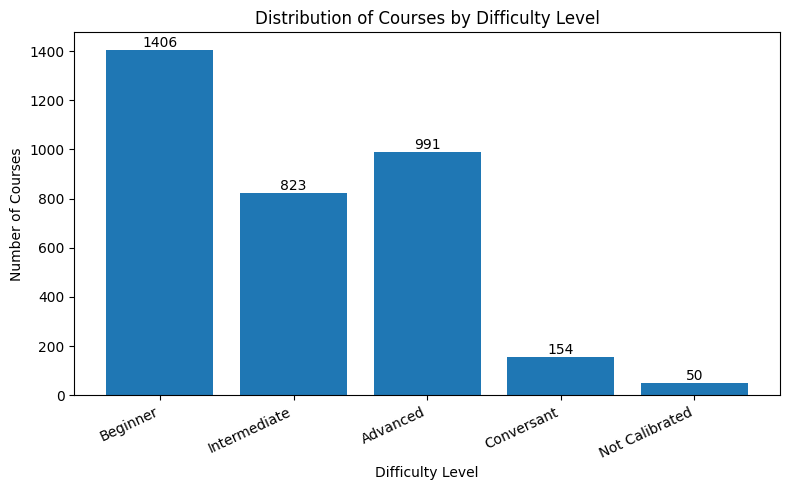

In [19]:
# Count courses by difficulty level
difficulty_order = ["Beginner", "Intermediate", "Advanced", "Conversant", "Not Calibrated"]

difficulty_counts = (
    df_clean["Difficulty Level"]
    .value_counts()
    .reindex(difficulty_order)
    .dropna()
)

# Create folder for figures
os.makedirs("figures", exist_ok=True)

# Plot bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(difficulty_counts.index, difficulty_counts.values)

plt.title("Distribution of Courses by Difficulty Level")
plt.xlabel("Difficulty Level")
plt.ylabel("Number of Courses")
plt.xticks(rotation=25, ha="right")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

# Save figure for thesis
plt.savefig("figures/difficulty_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [20]:
difficulty_mapping = {
    "Beginner": 1,
    "Conversant": 2,
    "Intermediate": 2,
    "Advanced": 3,
    "Not Calibrated": 0
}

df_clean["Difficulty Score"] = df_clean["Difficulty Level"].map(difficulty_mapping)

df_clean[["Difficulty Level", "Difficulty Score"]].head()

,Difficulty Level,Difficulty Score
0,Beginner,1
1,Beginner,1
2,Advanced,3
3,Intermediate,2
4,Beginner,1


Check the final columnsCheck the final columns

In [21]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3424 entries, 0 to 3521
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Course Name            3424 non-null   object 
 1   University             3424 non-null   object 
 2   Difficulty Level       3424 non-null   object 
 3   Course Rating          3424 non-null   object 
 4   Course URL             3424 non-null   object 
 5   Course Description     3424 non-null   object 
 6   Skills                 3424 non-null   object 
 7   Course Rating Numeric  3424 non-null   float64
 8   Difficulty Score       3424 non-null   int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 267.5+ KB


# Skill/domain extraction and enrichment

In [22]:
TOP_DOMAINS = ['arts-and-humanities','business','computer-science','data-science',
 'information-technology','health','math-and-logic','personal-development',
 'physical-science-and-engineering','language-learning','social-sciences','life-sciences']

DOMAIN_DISPLAY = {'arts-and-humanities':'Arts and Humanities','business':'Business',
 'computer-science':'Computer Science','data-science':'Data Science',
 'information-technology':'Information Technology','health':'Health',
 'math-and-logic':'Math and Logic','personal-development':'Personal Development',
 'physical-science-and-engineering':'Physical Science and Engineering',
 'language-learning':'Language Learning','social-sciences':'Social Sciences',
 'life-sciences':'Life Sciences'}

# skill standardization map
SKILL_CANON = {
 'ml':'machine learning','ai':'artificial intelligence','nlp':'natural language processing',
 'python programming':'python','computer programming':'programming','data analytics':'data analysis',
 'general statistics':'statistics','statistical analysis':'statistics','human learning':'learning'}

In [23]:
import re

def parse_skills_field(raw):
    toks = str(raw).split(' ')
    di = next((i for i in range(len(toks)-1, -1, -1) if toks[i] in TOP_DOMAINS), None)
    if di is None:
        return 'other', None, [x.strip().lower() for x in re.split(r'\s{2,}', str(raw)) if x.strip()]
    domain = toks[di]
    subdomain = ' '.join(toks[di+1:]).strip() or None
    body = ' '.join(toks[:di]).strip()
    skills = [x.strip().lower() for x in re.split(r'\s{2,}', body) if x.strip()]
    return domain, subdomain, skills

def canonicalize_skills(skills):
    out = []
    for s in skills:
        s = re.sub(r'[^a-z0-9+#& ]', ' ', s).strip()
        s = re.sub(r'\s+', ' ', s)
        s = SKILL_CANON.get(s, s)
        if s and s not in out:
            out.append(s)
    return out

In [24]:
raw = pd.read_csv("Coursera.csv").drop_duplicates().reset_index(drop=True)
parsed = raw["Skills"].apply(parse_skills_field)

raw["Assigned Domain"] = [DOMAIN_DISPLAY.get(p[0], "Other") for p in parsed]
raw["Subdomain"]       = [p[1] for p in parsed]
raw["Skills List"]     = [canonicalize_skills(p[2]) for p in parsed]

dom = dict(zip(raw["Course URL"], raw["Assigned Domain"]))
sub = dict(zip(raw["Course URL"], raw["Subdomain"]))
skl = dict(zip(raw["Course URL"], raw["Skills List"]))

df_clean["Assigned Domain"] = df_clean["Course URL"].map(dom)
df_clean["Subdomain"]       = df_clean["Course URL"].map(sub)
df_clean["Skills List"]     = df_clean["Course URL"].map(skl)

# safety check — should be 0
print("rows missing a domain:", df_clean["Assigned Domain"].isna().sum())
print("rows missing skills   :", df_clean["Skills List"].isna().sum())

rows missing a domain: 0
rows missing skills   : 0


In [25]:
from collections import Counter
c = Counter()
for s in df_clean["Skills List"]: c.update(s)
lens = df_clean["Skills List"].apply(len)

print("Courses:", len(df_clean))
print(f"Skills per course — avg {lens.mean():.1f}, min {lens.min()}, max {lens.max()}")
print("Unique skills:", len(c))
print("\nDomain distribution:")
print(df_clean["Assigned Domain"].value_counts())
print("\nSample:")
for i in range(3):
    print(" -", df_clean.iloc[i]["Course Name"][:45], "|", df_clean.iloc[i]["Assigned Domain"])
    print("   ", df_clean.iloc[i]["Skills List"][:8])

Courses: 3424
Skills per course — avg 10.0, min 2, max 14
Unique skills: 6231

Domain distribution:
Assigned Domain
Business                            779
Computer Science                    582
Data Science                        501
Life Sciences                       376
Physical Science and Engineering    300
Social Sciences                     279
Arts and Humanities                 219
Information Technology              174
Language Learning                   105
Personal Development                 74
Math and Logic                       32
Other                                 3
Name: count, dtype: int64

Sample:
 - Write A Feature Length Screenplay For Film Or | Arts and Humanities
    ['drama', 'comedy', 'peering', 'screenwriting', 'film', 'document review', 'dialogue', 'creative writing']
 - Business Strategy: Business Model Canvas Anal | Business
    ['finance', 'business plan', 'persona user experience', 'business model canvas', 'planning', 'business', 'project', 'produc

In [26]:
# Detection and handling
import re

desc = df_clean["Course Description"].astype(str)

# language check: fraction of very common English words in the text
EN_STOP = set("the a an of to and in is for with on that this are as be by it from or your you will".split())
def english_ratio(txt):
    words = re.findall(r"[a-zA-Z]+", txt.lower())
    return sum(1 for w in words if w in EN_STOP) / len(words) if words else 0.0

df_clean["desc_len"]  = desc.str.len()
df_clean["en_ratio"]  = desc.apply(english_ratio)

# flag the two problems (detection)
df_clean["low_quality"]        = df_clean["desc_len"] < 40                      # near-empty descriptions
df_clean["likely_non_english"] = (df_clean["en_ratio"] < 0.05) & (df_clean["desc_len"] >= 40)

# handling: mark rows to treat carefully downstream (kept, not dropped)
df_clean["desc_flag"] = "ok"
df_clean.loc[df_clean["low_quality"], "desc_flag"] = "low_quality"
df_clean.loc[df_clean["likely_non_english"], "desc_flag"] = "non_english"

print("low-quality (near-empty) descriptions:", int(df_clean["low_quality"].sum()))
print("likely non-English descriptions:", int(df_clean["likely_non_english"].sum()))
print(df_clean["desc_flag"].value_counts())

low-quality (near-empty) descriptions: 2
likely non-English descriptions: 6
desc_flag
ok             3416
non_english       6
low_quality       2
Name: count, dtype: int64


In [27]:
# Description segmentation and enrichment
from collections import Counter

# build a vocabulary of real skills to search for inside descriptions
# (only reasonably common, multi-character skills, to avoid matching junk)
vocab = Counter()
for s in df_clean["Skills List"]:
    vocab.update(s)
skill_lookup = [k for k, v in vocab.items() if v >= 5 and len(k) >= 5]

# regex patterns that signal prerequisite/level information in the text
PREREQ_CUE = re.compile(r"no prior|prerequisite|before taking|basic (knowledge|understanding)|"
                        r"prior experience|introductor|beginner|familiar with|assumes", re.I)
ADVANCED_CUE = re.compile(r"advanced|in-depth|expert|deep dive", re.I)

def extra_skills_from_text(row):
    d = str(row["Course Description"]).lower()
    # \b = word boundary, so "eating" no longer matches inside "creating"
    found = [sk for sk in skill_lookup
             if re.search(r"\b" + re.escape(sk) + r"\b", d) and sk not in row["Skills List"]]
    return found[:8]

# segmentation: first sentence as a short summary
df_clean["desc_summary"] = desc.apply(lambda t: re.split(r"(?<=[.!?]) ", t.strip())[0][:160])
# enrichment: extra skills + prerequisite/level cues
df_clean["desc_extra_skills"] = df_clean.apply(extra_skills_from_text, axis=1)
df_clean["has_prereq_cue"]    = desc.apply(lambda t: bool(PREREQ_CUE.search(t)))
df_clean["has_advanced_cue"]  = desc.apply(lambda t: bool(ADVANCED_CUE.search(t)))

print("avg extra skills found per course:", round(df_clean["desc_extra_skills"].apply(len).mean(), 2))
print("courses with a prerequisite/level cue:", int(df_clean["has_prereq_cue"].sum()))
print("courses with an advanced cue:", int(df_clean["has_advanced_cue"].sum()))
df_clean[["Course Name", "desc_summary", "desc_extra_skills", "has_prereq_cue"]].head(3)

avg extra skills found per course: 3.91
courses with a prerequisite/level cue: 556
courses with an advanced cue: 507


,Course Name,desc_summary,desc_extra_skills,has_prereq_cue
0,Write A Feature Length Screenplay For Film Or ...,Write a Full Length Feature Film Script In thi...,"[project, peer review, software, learning, pro...",True
1,Business Strategy: Business Model Canvas Analy...,"By the end of this guided project, you will be...",[analysis],False
2,Silicon Thin Film Solar Cells,This course consists of a general presentation...,"[presentation, process, materials, properties,...",False


In [28]:
#giving every course a short ID
df_clean["Course ID"] = ["C" + str(i) for i in range(len(df_clean))]
df_clean[["Course ID", "Course Name", "Assigned Domain"]].head()

,Course ID,Course Name,Assigned Domain
0,C0,Write A Feature Length Screenplay For Film Or ...,Arts and Humanities
1,C1,Business Strategy: Business Model Canvas Analy...,Business
2,C2,Silicon Thin Film Solar Cells,Physical Science and Engineering
3,C3,Finance for Managers,Business
4,C4,Retrieve Data using Single-Table SQL Queries,Information Technology


In [29]:
#build a "skills that belong to each domain" map
from collections import Counter

domain_skills = {}
for dom in df_clean["Assigned Domain"].unique():
    sk = Counter()
    for s in df_clean[df_clean["Assigned Domain"] == dom]["Skills List"]:
        sk.update(s)
    domain_skills[dom] = [k for k, _ in sk.most_common(60)]   # top skills per domain

# domains large enough to build learners around (skip 'Other' and tiny ones)
usable_domains = [d for d in domain_skills if len(domain_skills[d]) >= 8 and d != "Other"]
domain_weights = [(df_clean["Assigned Domain"] == d).sum() for d in usable_domains]
print("Usable domains:", usable_domains)

Usable domains: ['Arts and Humanities', 'Business', 'Physical Science and Engineering', 'Information Technology', 'Computer Science', 'Language Learning', 'Data Science', 'Life Sciences', 'Social Sciences', 'Personal Development', 'Math and Logic']


# Simulated learner profiles

In [30]:
# Generate 200 simulated learner profiles

import random
import numpy as np
import pandas as pd

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

LEVEL_NAME = {
    1: "Beginner",
    2: "Intermediate",
    3: "Advanced"
}


def make_learner(i):

    # ---------------------------------------------------------
    # 1. Preferred domain
    # ---------------------------------------------------------
    # Domains are sampled proportionally to the number
    # of courses available in each domain.
    dom = random.choices(
        usable_domains,
        weights=domain_weights,
        k=1
    )[0]

    # ---------------------------------------------------------
    # 2. Current learner level
    # ---------------------------------------------------------
    # Uniform sampling:
    # Beginner, Intermediate and Advanced have equal probability.
    lvl = random.choice([1, 2, 3])

    # ---------------------------------------------------------
    # 3. Select learner skills
    # ---------------------------------------------------------
    # domain_skills[dom] contains the 60 most frequent
    # standardized skills in the selected domain.
    pool = domain_skills[dom]

    # Each learner receives between 6 and 10 skills.
    n_skills = min(
        len(pool),
        random.randint(6, 10)
    )

    picked_skills = random.sample(
        pool,
        n_skills
    )

    # ---------------------------------------------------------
    # 4. Separate acquired and target skills
    # ---------------------------------------------------------
    # 3 to 5 skills represent future learning objectives.
    n_target = min(
        random.randint(3, 5),
        n_skills - 1
    )

    target_skills = picked_skills[:n_target]

    # Remaining skills represent knowledge already acquired.
    acquired_skills = picked_skills[n_target:]

    acquired_set = set(acquired_skills)

    # ---------------------------------------------------------
    # 5. Candidate completed courses
    # ---------------------------------------------------------
    # Historical courses must:
    # - belong to the learner's preferred domain
    # - have a calibrated difficulty
    # - not exceed the learner's current level
    completed_candidates = df_clean[
        (df_clean["Assigned Domain"] == dom)
        &
        (df_clean["Difficulty Score"] > 0)
        &
        (df_clean["Difficulty Score"] <= lvl)
    ].copy()

    # Count how many acquired skills each candidate course covers.
    completed_candidates["Acquired Skill Overlap"] = (
        completed_candidates["Skills List"]
        .apply(
            lambda skills:
            len(set(skills) & acquired_set)
        )
    )

    # Prefer courses related to skills already acquired
    # by the learner.
    meaningful_candidates = completed_candidates[
        completed_candidates["Acquired Skill Overlap"] > 0
    ].copy()

    # ---------------------------------------------------------
    # 6. Select 5 completed courses
    # ---------------------------------------------------------
    # Later:
    # 3 courses -> training
    # 1 course  -> validation
    # 1 course  -> testing

    completed = []

    meaningful_ids = list(
        meaningful_candidates["Course ID"]
    )

    # If at least 5 meaningful historical courses exist,
    # randomly select 5 of them.
    if len(meaningful_ids) >= 5:

        completed = random.sample(
            meaningful_ids,
            5
        )

    else:
        # Keep all meaningful courses if there are fewer than 5.
        completed = meaningful_ids.copy()

        # Add other appropriate courses from the same
        # domain and difficulty range if necessary.
        remaining_ids = list(
            completed_candidates[
                ~completed_candidates[
                    "Course ID"
                ].isin(completed)
            ]["Course ID"]
        )

        needed = 5 - len(completed)

        if len(remaining_ids) >= needed:
            completed.extend(
                random.sample(
                    remaining_ids,
                    needed
                )
            )
        else:
            completed.extend(
                remaining_ids
            )

    # ---------------------------------------------------------
    # 7. Learning goal
    # ---------------------------------------------------------
    goal = (
        f"Become proficient in {dom}, "
        f"focusing on "
        f"{', '.join(target_skills[:2])}."
    )

    # ---------------------------------------------------------
    # 8. Final learner profile
    # ---------------------------------------------------------
    return {
        "Learner ID": f"L{i}",
        "Preferred Domain": dom,
        "Current Level": LEVEL_NAME[lvl],
        "Current Level Score": lvl,
        "Target Skills": target_skills,
        "Acquired Skills": acquired_skills,
        "Completed Courses": completed,
        "Learning Goal": goal
    }


# -------------------------------------------------------------
# Generate the 200 learners
# -------------------------------------------------------------

learners_df = pd.DataFrame(
    [
        make_learner(i)
        for i in range(1, 201)
    ]
)


# -------------------------------------------------------------
# Save profiles
# -------------------------------------------------------------

learners_df.to_csv(
    "simulated_learners.csv",
    index=False
)


print(
    "Created",
    len(learners_df),
    "learners"
)

learners_df.head()

Created 200 learners


,Learner ID,Preferred Domain,Current Level,Current Level Score,Target Skills,Acquired Skills,Completed Courses,Learning Goal
0,L1,Data Science,Beginner,1,"[data visualization, algorithms, deep learning]","[graphs, statistics, scikit learn, statistical...","[C2852, C227, C221, C554, C1179]","Become proficient in Data Science, focusing on..."
1,L2,Business,Advanced,3,"[social media, accounting, global, sustainabil...","[experience, value proposition]","[C980, C2074, C2744, C1194, C3193]","Become proficient in Business, focusing on soc..."
2,L3,Life Sciences,Beginner,1,"[modeling, epidemiology, genetics]","[nutrition, planning, education, anatomy, lead...","[C722, C3119, C583, C57, C1763]","Become proficient in Life Sciences, focusing o..."
3,L4,Computer Science,Intermediate,2,"[data structures, android development, softwar...",[user experience],"[C1423, C3042, C307, C154, C3106]","Become proficient in Computer Science, focusin..."
4,L5,Data Science,Beginner,1,"[web, statistics, language, analytics]","[evaluation, convolutional neural network, lea...","[C1050, C2194, C2161, C1443, C1692]","Become proficient in Data Science, focusing on..."


In [31]:
print(
    "Number of learners:",
    len(learners_df)
)

print(
    "\nCompleted-course counts:"
)

print(
    learners_df["Completed Courses"]
    .apply(len)
    .value_counts()
    .sort_index()
)

print(
    "\nLevel distribution:"
)

print(
    learners_df["Current Level"]
    .value_counts()
)

print(
    "\nExample learner:"
)

example = learners_df.iloc[0]

print("Learner:", example["Learner ID"])
print("Domain:", example["Preferred Domain"])
print("Level:", example["Current Level"])
print("Acquired skills:", example["Acquired Skills"])
print("Target skills:", example["Target Skills"])
print("Completed courses:", example["Completed Courses"])
print("Number completed:", len(example["Completed Courses"]))
print("Goal:", example["Learning Goal"])

Number of learners: 200

Completed-course counts:
Completed Courses
5    200
Name: count, dtype: int64

Level distribution:
Current Level
Intermediate    73
Advanced        66
Beginner        61
Name: count, dtype: int64

Example learner:
Learner: L1
Domain: Data Science
Level: Beginner
Acquired skills: ['graphs', 'statistics', 'scikit learn', 'statistical hypothesis testing', 'ordered pair']
Target skills: ['data visualization', 'algorithms', 'deep learning']
Completed courses: ['C2852', 'C227', 'C221', 'C554', 'C1179']
Number completed: 5
Goal: Become proficient in Data Science, focusing on data visualization, algorithms.


In [32]:
# ============================================================
# Train / validation / test split of completed courses
# ============================================================

SPLIT_SEED = 42
split_rng = random.Random(SPLIT_SEED)

train_completed_all = []
validation_course_all = []
test_course_all = []

for _, learner in learners_df.iterrows():

    # Copy the 5 historical completed courses
    completed = list(
        learner["Completed Courses"]
    )

    # Safety check:
    # every learner must have exactly 5 courses
    assert len(completed) == 5, (
        f"{learner['Learner ID']} has "
        f"{len(completed)} completed courses instead of 5."
    )

    # Randomize their order before splitting
    split_rng.shuffle(completed)

    # 3 courses visible during training
    train_courses = completed[:3]

    # 1 hidden course for validation
    validation_course = completed[3]

    # 1 completely hidden course for final testing
    test_course = completed[4]

    train_completed_all.append(
        train_courses
    )

    validation_course_all.append(
        validation_course
    )

    test_course_all.append(
        test_course
    )


# Add the split to the learner dataframe
learners_df["Train Completed Courses"] = (
    train_completed_all
)

learners_df["Validation Course"] = (
    validation_course_all
)

learners_df["Test Course"] = (
    test_course_all
)


# ============================================================
# Create a convenient dictionary for later use
# ============================================================

interaction_split = {}

for _, learner in learners_df.iterrows():

    lid = learner["Learner ID"]

    interaction_split[lid] = {
        "train": list(
            learner["Train Completed Courses"]
        ),
        "val": [
            learner["Validation Course"]
        ],
        "test": [
            learner["Test Course"]
        ]
    }


print(
    "Created train / validation / test "
    "interaction split for",
    len(interaction_split),
    "learners."
)

Created train / validation / test interaction split for 200 learners.


In [33]:
# ============================================================
# Verify the interaction split
# ============================================================

for _, learner in learners_df.iterrows():

    full = set(
        learner["Completed Courses"]
    )

    train = set(
        learner["Train Completed Courses"]
    )

    val = {
        learner["Validation Course"]
    }

    test = {
        learner["Test Course"]
    }

    # --------------------------------------------------------
    # Check split sizes
    # --------------------------------------------------------
    assert len(train) == 3

    assert len(val) == 1

    assert len(test) == 1

    # --------------------------------------------------------
    # Check that there is no leakage between splits
    # --------------------------------------------------------
    assert train.isdisjoint(val)

    assert train.isdisjoint(test)

    assert val.isdisjoint(test)

    # --------------------------------------------------------
    # Check that all 5 original courses are preserved
    # --------------------------------------------------------
    assert (
        train | val | test
    ) == full


print(
    "All train / validation / test "
    "splits are valid."
)


# Show one example
example = learners_df.iloc[0]

print(
    "\nLearner:",
    example["Learner ID"]
)

print(
    "All completed courses:",
    example["Completed Courses"]
)

print(
    "Training courses:",
    example["Train Completed Courses"]
)

print(
    "Validation course:",
    example["Validation Course"]
)

print(
    "Test course:",
    example["Test Course"]
)

All train / validation / test splits are valid.

Learner: L1
All completed courses: ['C2852', 'C227', 'C221', 'C554', 'C1179']
Training courses: ['C554', 'C227', 'C221']
Validation course: C1179
Test course: C2852


In [34]:
# PREREQUISITE DERIVATION
# The dataset has no explicit prerequisites, so we infer them.
# Rule: course A is a prerequisite of course B if
#   (1) same domain,
#   (2) A is exactly one difficulty level below B,
#   (3) A and B share at least MIN_SHARED_SKILLS skills (topically related).
# For each course we keep only its top MAX_PREREQS prerequisites
# (the most skill-overlapping lower-level courses) to avoid edge explosion.
MIN_SHARED_SKILLS = 2   # how related two courses must be to form a prereq link
MAX_PREREQS       = 3   # cap prerequisites per course

cid  = df_clean["Course ID"].tolist()
dom  = df_clean["Assigned Domain"].tolist()
lvl  = df_clean["Difficulty Score"].tolist()          # 1=Beginner, 2=Intermediate, 3=Advanced
skl  = [set(s) for s in df_clean["Skills List"]]

# group course indices by (domain, level) so we only compare within a domain/level band
by_domain_level = {}
for i in range(len(df_clean)):
    by_domain_level.setdefault((dom[i], lvl[i]), []).append(i)

prereq_edges = []
for i in range(len(df_clean)):
    if lvl[i] in (0, 1):                                # beginners / uncalibrated have no prereqs
        continue
    candidates = by_domain_level.get((dom[i], lvl[i] - 1), [])   # one level below, same domain
    scored = []
    for j in candidates:
        overlap = len(skl[i] & skl[j])                 # number of shared skills
        if overlap >= MIN_SHARED_SKILLS:
            scored.append((overlap, j))
    scored.sort(reverse=True)                          # most related first
    for overlap, j in scored[:MAX_PREREQS]:
        prereq_edges.append((cid[j], cid[i]))          # A (prerequisite) -> B (advanced course)

print("Prerequisite edges:", len(prereq_edges))
print("Courses with >=1 prerequisite:", len(set(b for a, b in prereq_edges)))

Prerequisite edges: 4864
Courses with >=1 prerequisite: 1786


# Module 1: building the knowledge graph

In [35]:
import networkx as nx

# MultiDiGraph:
# directed graph that supports multiple relation types.
#
# Node ID conventions:
#   Course  -> "C0", "C1", ...
#   Skill   -> "SKILL::machine learning"
#   Domain  -> "DOM::Data Science"
#   Level   -> "LVL::Beginner"
#   Learner -> "L1", "L2", ...

G = nx.MultiDiGraph()


# ============================================================
# 1. Course-side nodes and relations
# ============================================================

for _, r in df_clean.iterrows():

    course_id = r["Course ID"]

    domain_node = (
        "DOM::" +
        r["Assigned Domain"]
    )

    level_node = (
        "LVL::" +
        str(r["Difficulty Level"])
    )

    # Course
    G.add_node(
        course_id,
        type="course"
    )

    # Domain
    G.add_node(
        domain_node,
        type="domain"
    )

    # Level
    G.add_node(
        level_node,
        type="level"
    )

    # Course -> Domain
    G.add_edge(
        course_id,
        domain_node,
        relation="belongs_to_domain"
    )

    # Course -> Level
    G.add_edge(
        course_id,
        level_node,
        relation="has_level"
    )

    # Course -> Skills
    for skill in r["Skills List"]:

        skill_node = (
            "SKILL::" + skill
        )

        G.add_node(
            skill_node,
            type="skill"
        )

        G.add_edge(
            course_id,
            skill_node,
            relation="teaches_skill"
        )


# ============================================================
# 2. Learner-side nodes and relations
# ============================================================

for _, learner in learners_df.iterrows():

    lid = learner["Learner ID"]

    domain_node = (
        "DOM::" +
        learner["Preferred Domain"]
    )

    # Learner
    G.add_node(
        lid,
        type="learner"
    )

    # Learner -> preferred domain
    G.add_edge(
        lid,
        domain_node,
        relation="interested_in"
    )

    # Learner -> acquired skills
    for skill in learner["Acquired Skills"]:

        skill_node = (
            "SKILL::" + skill
        )

        G.add_edge(
            lid,
            skill_node,
            relation="has_skill"
        )

    # Learner -> target skills
    for skill in learner["Target Skills"]:

        skill_node = (
            "SKILL::" + skill
        )

        G.add_edge(
            lid,
            skill_node,
            relation="targets_skill"
        )

    # --------------------------------------------------------
    # IMPORTANT:
    # Only TRAIN completed courses are added to the graph.
    #
    # Validation and test courses remain hidden.
    # --------------------------------------------------------

    for course_id in learner[
        "Train Completed Courses"
    ]:

        G.add_edge(
            lid,
            course_id,
            relation="completed"
        )


# ============================================================
# 3. Prerequisite relations
# ============================================================

for prerequisite, course in prereq_edges:

    G.add_edge(
        prerequisite,
        course,
        relation="prerequisite_of"
    )


print(
    "Graph built:",
    G.number_of_nodes(),
    "nodes,",
    G.number_of_edges(),
    "edges"
)

Graph built: 9872 nodes, 48344 edges


In [36]:
# Verify that validation and test interactions are hidden


def has_completed_edge(graph, learner_id, course_id):
    """
    Returns True only if there is a learner -> course edge
    whose relation is 'completed'.
    """

    if not graph.has_edge(
        learner_id,
        course_id
    ):
        return False

    edge_data = graph.get_edge_data(
        learner_id,
        course_id
    )

    return any(
        attributes.get("relation") == "completed"
        for attributes in edge_data.values()
    )


train_edges_found = 0
validation_leaks = 0
test_leaks = 0


for _, learner in learners_df.iterrows():

    lid = learner["Learner ID"]

    # --------------------------------------------------------
    # Training interactions SHOULD exist
    # --------------------------------------------------------

    for course_id in learner[
        "Train Completed Courses"
    ]:

        if has_completed_edge(
            G,
            lid,
            course_id
        ):
            train_edges_found += 1

    # --------------------------------------------------------
    # Validation interaction MUST NOT exist
    # --------------------------------------------------------

    validation_course = learner[
        "Validation Course"
    ]

    if has_completed_edge(
        G,
        lid,
        validation_course
    ):
        validation_leaks += 1

    # --------------------------------------------------------
    # Test interaction MUST NOT exist
    # --------------------------------------------------------

    test_course = learner[
        "Test Course"
    ]

    if has_completed_edge(
        G,
        lid,
        test_course
    ):
        test_leaks += 1


print(
    "Training completion edges:",
    train_edges_found
)

print(
    "Validation leaks:",
    validation_leaks
)

print(
    "Test leaks:",
    test_leaks
)

Training completion edges: 600
Validation leaks: 0
Test leaks: 0


In [37]:
from collections import Counter
import pickle

node_types = Counter(d["type"] for _, d in G.nodes(data=True))
edge_types = Counter(d["relation"] for _, _, d in G.edges(data=True))

print("=== NODES by type ===")
for k, v in node_types.items():
    print(f"  {k:9s} {v}")
print("\n=== EDGES by relation ===")
for k, v in sorted(edge_types.items(), key=lambda x: -x[1]):
    print(f"  {k:20s} {v}")

# save for later notebooks
with open("knowledge_graph.pkl", "wb") as f:
    pickle.dump(G, f)
print("\nSaved knowledge_graph.pkl")

=== NODES by type ===
  course    3424
  domain    12
  level     5
  skill     6231
  learner   200

=== EDGES by relation ===
  teaches_skill        34211
  prerequisite_of      4864
  belongs_to_domain    3424
  has_level            3424
  targets_skill        821
  has_skill            800
  completed            600
  interested_in        200

Saved knowledge_graph.pkl


In [38]:
# ============================================================
# Verify graph edge statistics
# ============================================================

from collections import Counter

edge_types = Counter(
    d["relation"]
    for _, _, d in G.edges(data=True)
)

relation_total = sum(
    edge_types.values()
)

graph_total = G.number_of_edges()

print(
    "G.number_of_edges():",
    graph_total
)

print(
    "Sum of relation counts:",
    relation_total
)

print(
    "Difference:",
    graph_total - relation_total
)

print("\nRelations:")

for relation, count in sorted(
    edge_types.items(),
    key=lambda x: -x[1]
):
    print(
        f"{relation:20s}",
        count
    )

G.number_of_edges(): 48344
Sum of relation counts: 48344
Difference: 0

Relations:
teaches_skill        34211
prerequisite_of      4864
belongs_to_domain    3424
has_level            3424
targets_skill        821
has_skill            800
completed            600
interested_in        200


# Module 2: GNN-Based Recommendation

In [39]:
#Convert the knowledge graph to PyTorch tensors


import torch
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Create a fixed node ordering
# ------------------------------------------------------------

nodes = list(G.nodes())

node_to_idx = {
    node: idx
    for idx, node in enumerate(nodes)
}

idx_to_node = {
    idx: node
    for node, idx in node_to_idx.items()
}


print(
    "Number of graph nodes:",
    len(nodes)
)


# ------------------------------------------------------------
# 2. Node type encoding
# ------------------------------------------------------------

NODE_TYPES = [
    "course",
    "skill",
    "domain",
    "level",
    "learner"
]

type_to_idx = {
    node_type: idx
    for idx, node_type in enumerate(NODE_TYPES)
}


# ------------------------------------------------------------
# 3. Prepare numeric course metadata
# ------------------------------------------------------------

course_metadata = df_clean.copy()

# Convert ratings safely to numeric.
course_metadata["Rating Numeric"] = pd.to_numeric(
    course_metadata["Course Rating"],
    errors="coerce"
)

# Mean rating is used only when a course rating is unavailable.
rating_mean = course_metadata[
    "Rating Numeric"
].mean()

course_metadata["Rating Numeric"] = (
    course_metadata["Rating Numeric"]
    .fillna(rating_mean)
)

rating_min = course_metadata[
    "Rating Numeric"
].min()

rating_max = course_metadata[
    "Rating Numeric"
].max()


# Normalize rating into [0, 1]
if rating_max > rating_min:

    course_metadata["Rating Normalized"] = (
        course_metadata["Rating Numeric"]
        - rating_min
    ) / (
        rating_max
        - rating_min
    )

else:

    course_metadata[
        "Rating Normalized"
    ] = 0.0


# ------------------------------------------------------------
# 4. Difficulty representation
# ------------------------------------------------------------

# Difficulty Score currently uses:
#
# 0 -> Not Calibrated / unknown
# 1 -> Beginner
# 2 -> Intermediate / Conversant
# 3 -> Advanced
#
# IMPORTANT:
# 0 is treated here as UNKNOWN rather than as a real
# educational level.

course_metadata["Difficulty Known"] = (
    course_metadata["Difficulty Score"] > 0
).astype(float)

course_metadata["Difficulty Normalized"] = (
    course_metadata["Difficulty Score"]
    .clip(lower=0)
    / 3.0
)

# For unknown difficulty, keep normalized difficulty at 0,
# but the additional Difficulty Known indicator explicitly
# tells the model that this means "unknown".
course_metadata.loc[
    course_metadata["Difficulty Known"] == 0,
    "Difficulty Normalized"
] = 0.0


# ------------------------------------------------------------
# 5. Course metadata lookup
# ------------------------------------------------------------

course_lookup = (
    course_metadata
    .set_index("Course ID")
)


# ------------------------------------------------------------
# 6. Build structural node feature matrix
# ------------------------------------------------------------

# Features:
#
# 0-4 : node type one-hot
# 5   : normalized course rating
# 6   : normalized difficulty
# 7   : difficulty-known indicator
#
# Total structural dimension = 8

structural_dim = 8

x = torch.zeros(
    (
        len(nodes),
        structural_dim
    ),
    dtype=torch.float32
)


for node, idx in node_to_idx.items():

    node_type = G.nodes[node].get(
        "type"
    )

    # --------------------------------------------------------
    # Node-type one-hot feature
    # --------------------------------------------------------

    if node_type in type_to_idx:

        x[
            idx,
            type_to_idx[node_type]
        ] = 1.0

    # --------------------------------------------------------
    # Course-specific metadata
    # --------------------------------------------------------

    if (
        node_type == "course"
        and node in course_lookup.index
    ):

        row = course_lookup.loc[node]

        x[idx, 5] = float(
            row["Rating Normalized"]
        )

        x[idx, 6] = float(
            row["Difficulty Normalized"]
        )

        x[idx, 7] = float(
            row["Difficulty Known"]
        )


# ------------------------------------------------------------
# 7. Convert graph edges to edge_index
# ------------------------------------------------------------

source_indices = []
target_indices = []


for source, target, _ in G.edges(
    data=True
):

    source_idx = node_to_idx[source]
    target_idx = node_to_idx[target]

    # Original direction
    source_indices.append(
        source_idx
    )

    target_indices.append(
        target_idx
    )

    # Reverse direction
    #
    # GraphSAGE should allow information to propagate
    # in both directions.
    source_indices.append(
        target_idx
    )

    target_indices.append(
        source_idx
    )


edge_index = torch.tensor(
    [
        source_indices,
        target_indices
    ],
    dtype=torch.long
)


print(
    "Structural feature matrix:",
    x.shape
)

print(
    "Edge index:",
    edge_index.shape
)

Number of graph nodes: 9872
Structural feature matrix: torch.Size([9872, 8])
Edge index: torch.Size([2, 96688])


In [40]:
# Verify tensor construction

print(
    "Number of nodes:",
    len(nodes)
)

print(
    "x shape:",
    x.shape
)

print(
    "edge_index shape:",
    edge_index.shape
)

print(
    "Structural feature dimension:",
    x.shape[1]
)


print(
    "\nNaN values in x:",
    torch.isnan(x).any().item()
)

print(
    "Infinite values in x:",
    torch.isinf(x).any().item()
)


print(
    "\nExpected message-passing edges:",
    G.number_of_edges() * 2
)

print(
    "Actual message-passing edges:",
    edge_index.shape[1]
)


# ------------------------------------------------------------
# Node type counts from tensor ordering
# ------------------------------------------------------------

for node_type in NODE_TYPES:

    count = sum(
        1
        for node in nodes
        if G.nodes[node].get("type")
        == node_type
    )

    print(
        f"{node_type:10s}:",
        count
    )

Number of nodes: 9872
x shape: torch.Size([9872, 8])
edge_index shape: torch.Size([2, 96688])
Structural feature dimension: 8

NaN values in x: False
Infinite values in x: False

Expected message-passing edges: 96688
Actual message-passing edges: 96688
course    : 3424
skill     : 6231
domain    : 12
level     : 5
learner   : 200


In [41]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 765.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.2 MB/s eta 0:00:00


In [42]:
# GraphSAGE recommender using semantic + structural features


from torch_geometric.nn import SAGEConv
import torch
import torch.nn as nn
import torch.nn.functional as F


class GraphSAGERecommender(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64,
        output_dim=32,
        dropout=0.3
    ):
        super().__init__()

        # First GraphSAGE layer:
        # 392 semantic + structural features -> hidden representation
        self.conv1 = SAGEConv(
            input_dim,
            hidden_dim
        )

        # Second GraphSAGE layer:
        # hidden representation -> final node embedding
        self.conv2 = SAGEConv(
            hidden_dim,
            output_dim
        )

        self.dropout = dropout


    def encode(
        self,
        x,
        edge_index
    ):

        # First message-passing layer
        h = self.conv1(
            x,
            edge_index
        )

        h = F.relu(h)

        h = F.dropout(
            h,
            p=self.dropout,
            training=self.training
        )

        # Second message-passing layer
        h = self.conv2(
            h,
            edge_index
        )

        return h


    def decode(
        self,
        z,
        learner_idx,
        course_idx
    ):

        learner_z = z[
            learner_idx
        ]

        course_z = z[
            course_idx
        ]

        # Learner-course compatibility score
        return (
            learner_z
            * course_z
        ).sum(dim=1)


    def forward(
        self,
        x,
        edge_index,
        learner_idx,
        course_idx
    ):

        z = self.encode(
            x,
            edge_index
        )

        return self.decode(
            z,
            learner_idx,
            course_idx
        )

In [43]:
# ============================================================
# STEP 5 - Build non-circular training pairs
# ============================================================

import random
import pandas as pd
import torch

NEGATIVE_SEED = 42
negative_rng = random.Random(NEGATIVE_SEED)

training_pairs = []

fallback_same_domain = 0
fallback_global = 0


for _, learner in learners_df.iterrows():

    lid = learner["Learner ID"]

    learner_domain = learner[
        "Preferred Domain"
    ]

    learner_level = learner[
        "Current Level Score"
    ]

    train_courses = list(
        learner["Train Completed Courses"]
    )

    # --------------------------------------------------------
    # IMPORTANT:
    # Exclude ALL 5 historical courses from negative sampling.
    #
    # This prevents validation/test positives from accidentally
    # being used as negative examples during training.
    # --------------------------------------------------------

    historical_courses = set(
        learner["Completed Courses"]
    )

    # ========================================================
    # 1. Positive interactions
    # ========================================================

    for course_id in train_courses:

        training_pairs.append({
            "Learner ID": lid,
            "Course ID": course_id,
            "Label": 1
        })


    # ========================================================
    # 2. Candidate negative courses
    # ========================================================
    #
    # Harder and fairer negatives:
    #
    # - same preferred domain
    # - calibrated difficulty
    # - difficulty <= learner's current level
    # - NOT one of the learner's 5 historical courses
    #
    # Target skills are deliberately NOT used here.
    # ========================================================

    negative_candidates = df_clean[
        (df_clean["Assigned Domain"] == learner_domain)
        &
        (df_clean["Difficulty Score"] > 0)
        &
        (df_clean["Difficulty Score"] <= learner_level)
        &
        (~df_clean["Course ID"].isin(historical_courses))
    ]["Course ID"].tolist()


    # ========================================================
    # 3. Fallback if a learner has fewer than 3 candidates
    # ========================================================

    if len(negative_candidates) < 3:

        fallback_same_domain += 1

        negative_candidates = df_clean[
            (df_clean["Assigned Domain"] == learner_domain)
            &
            (df_clean["Difficulty Score"] > 0)
            &
            (~df_clean["Course ID"].isin(historical_courses))
        ]["Course ID"].tolist()


    # Very unlikely second fallback
    if len(negative_candidates) < 3:

        fallback_global += 1

        negative_candidates = df_clean[
            (df_clean["Difficulty Score"] > 0)
            &
            (~df_clean["Course ID"].isin(historical_courses))
        ]["Course ID"].tolist()


    # ========================================================
    # 4. Sample same number of negatives as positives
    # ========================================================

    sampled_negatives = negative_rng.sample(
        negative_candidates,
        len(train_courses)
    )

    for course_id in sampled_negatives:

        training_pairs.append({
            "Learner ID": lid,
            "Course ID": course_id,
            "Label": 0
        })


# ============================================================
# Convert to dataframe
# ============================================================

training_pairs_df = pd.DataFrame(
    training_pairs
)


print(
    "Total training pairs:",
    len(training_pairs_df)
)

print(
    "\nLabel distribution:"
)

print(
    training_pairs_df["Label"]
    .value_counts()
    .sort_index()
)

print(
    "\nSame-domain fallback count:",
    fallback_same_domain
)

print(
    "Global fallback count:",
    fallback_global
)

Total training pairs: 1200

Label distribution:
Label
0    600
1    600
Name: count, dtype: int64

Same-domain fallback count: 0
Global fallback count: 0


In [44]:
# ============================================================
# Verify training pairs
# ============================================================

positive_pairs = training_pairs_df[
    training_pairs_df["Label"] == 1
]

negative_pairs = training_pairs_df[
    training_pairs_df["Label"] == 0
]


# ------------------------------------------------------------
# 1. Correct number of positives and negatives
# ------------------------------------------------------------

assert len(positive_pairs) == 600

assert len(negative_pairs) == 600


# ------------------------------------------------------------
# 2. Verify every positive is a TRAIN interaction
# ------------------------------------------------------------

for _, row in positive_pairs.iterrows():

    lid = row["Learner ID"]
    cid = row["Course ID"]

    assert cid in interaction_split[lid]["train"]


# ------------------------------------------------------------
# 3. Verify validation/test courses are NEVER negatives
# ------------------------------------------------------------

validation_negative_leaks = 0
test_negative_leaks = 0


for _, row in negative_pairs.iterrows():

    lid = row["Learner ID"]
    cid = row["Course ID"]

    if cid in interaction_split[lid]["val"]:
        validation_negative_leaks += 1

    if cid in interaction_split[lid]["test"]:
        test_negative_leaks += 1


print(
    "Positive training pairs:",
    len(positive_pairs)
)

print(
    "Negative training pairs:",
    len(negative_pairs)
)

print(
    "Validation courses used as negatives:",
    validation_negative_leaks
)

print(
    "Test courses used as negatives:",
    test_negative_leaks
)

Positive training pairs: 600
Negative training pairs: 600
Validation courses used as negatives: 0
Test courses used as negatives: 0


In [45]:
# ============================================================
# Convert training pairs to tensors
# ============================================================

train_learner_idx = torch.tensor(
    [
        node_to_idx[lid]
        for lid in training_pairs_df[
            "Learner ID"
        ]
    ],
    dtype=torch.long
)

train_course_idx = torch.tensor(
    [
        node_to_idx[cid]
        for cid in training_pairs_df[
            "Course ID"
        ]
    ],
    dtype=torch.long
)

train_labels = torch.tensor(
    training_pairs_df[
        "Label"
    ].values,
    dtype=torch.float32
)


print(
    "Learner indices:",
    train_learner_idx.shape
)

print(
    "Course indices:",
    train_course_idx.shape
)

print(
    "Labels:",
    train_labels.shape
)

print(
    "\nPositive labels:",
    int(train_labels.sum().item())
)

print(
    "Negative labels:",
    int(
        len(train_labels)
        - train_labels.sum().item()
    )
)

Learner indices: torch.Size([1200])
Course indices: torch.Size([1200])
Labels: torch.Size([1200])

Positive labels: 600
Negative labels: 600


In [46]:
# ============================================================
# STEP 6 - Build validation pairs
# ============================================================

VALIDATION_NEGATIVE_SEED = 43
validation_rng = random.Random(
    VALIDATION_NEGATIVE_SEED
)

validation_pairs = []


# ------------------------------------------------------------
# Training negatives already used for each learner
# ------------------------------------------------------------

train_negative_courses = {}

for lid in learners_df["Learner ID"]:

    train_negative_courses[lid] = set(
        training_pairs_df[
            (training_pairs_df["Learner ID"] == lid)
            &
            (training_pairs_df["Label"] == 0)
        ]["Course ID"]
    )


# ------------------------------------------------------------
# Construct validation pairs
# ------------------------------------------------------------

validation_fallback_same_domain = 0
validation_fallback_global = 0


for _, learner in learners_df.iterrows():

    lid = learner["Learner ID"]

    learner_domain = learner[
        "Preferred Domain"
    ]

    learner_level = learner[
        "Current Level Score"
    ]

    validation_course = learner[
        "Validation Course"
    ]

    historical_courses = set(
        learner["Completed Courses"]
    )

    already_used_negatives = (
        train_negative_courses[lid]
    )


    # ========================================================
    # 1. Validation positive
    # ========================================================

    validation_pairs.append({
        "Learner ID": lid,
        "Course ID": validation_course,
        "Label": 1
    })


    # ========================================================
    # 2. Validation negative candidates
    # ========================================================

    negative_candidates = df_clean[
        (df_clean["Assigned Domain"] == learner_domain)
        &
        (df_clean["Difficulty Score"] > 0)
        &
        (df_clean["Difficulty Score"] <= learner_level)
        &
        (~df_clean["Course ID"].isin(historical_courses))
        &
        (~df_clean["Course ID"].isin(already_used_negatives))
    ]["Course ID"].tolist()


    # --------------------------------------------------------
    # Fallback 1
    # Same domain, calibrated difficulty
    # --------------------------------------------------------

    if len(negative_candidates) < 1:

        validation_fallback_same_domain += 1

        negative_candidates = df_clean[
            (df_clean["Assigned Domain"] == learner_domain)
            &
            (df_clean["Difficulty Score"] > 0)
            &
            (~df_clean["Course ID"].isin(historical_courses))
            &
            (~df_clean["Course ID"].isin(already_used_negatives))
        ]["Course ID"].tolist()


    # --------------------------------------------------------
    # Fallback 2
    # Global calibrated course
    # --------------------------------------------------------

    if len(negative_candidates) < 1:

        validation_fallback_global += 1

        negative_candidates = df_clean[
            (df_clean["Difficulty Score"] > 0)
            &
            (~df_clean["Course ID"].isin(historical_courses))
            &
            (~df_clean["Course ID"].isin(already_used_negatives))
        ]["Course ID"].tolist()


    sampled_negative = validation_rng.choice(
        negative_candidates
    )


    validation_pairs.append({
        "Learner ID": lid,
        "Course ID": sampled_negative,
        "Label": 0
    })


# ------------------------------------------------------------
# DataFrame
# ------------------------------------------------------------

validation_pairs_df = pd.DataFrame(
    validation_pairs
)


print(
    "Total validation pairs:",
    len(validation_pairs_df)
)

print(
    "\nValidation label distribution:"
)

print(
    validation_pairs_df["Label"]
    .value_counts()
    .sort_index()
)

print(
    "\nValidation same-domain fallback:",
    validation_fallback_same_domain
)

print(
    "Validation global fallback:",
    validation_fallback_global
)

Total validation pairs: 400

Validation label distribution:
Label
0    200
1    200
Name: count, dtype: int64

Validation same-domain fallback: 0
Validation global fallback: 0


In [47]:
# ============================================================
# Verify validation pairs
# ============================================================

validation_positive = validation_pairs_df[
    validation_pairs_df["Label"] == 1
]

validation_negative = validation_pairs_df[
    validation_pairs_df["Label"] == 0
]


assert len(validation_positive) == 200
assert len(validation_negative) == 200


# ------------------------------------------------------------
# Check positives
# ------------------------------------------------------------

for _, row in validation_positive.iterrows():

    lid = row["Learner ID"]
    cid = row["Course ID"]

    assert cid in interaction_split[lid]["val"]


# ------------------------------------------------------------
# Check negatives
# ------------------------------------------------------------

history_negative_leaks = 0
training_negative_overlap = 0


for _, row in validation_negative.iterrows():

    lid = row["Learner ID"]
    cid = row["Course ID"]

    learner = learners_df[
        learners_df["Learner ID"] == lid
    ].iloc[0]

    if cid in learner["Completed Courses"]:
        history_negative_leaks += 1

    if cid in train_negative_courses[lid]:
        training_negative_overlap += 1


print(
    "Validation positives:",
    len(validation_positive)
)

print(
    "Validation negatives:",
    len(validation_negative)
)

print(
    "Historical courses used as validation negatives:",
    history_negative_leaks
)

print(
    "Training negatives reused in validation:",
    training_negative_overlap
)

Validation positives: 200
Validation negatives: 200
Historical courses used as validation negatives: 0
Training negatives reused in validation: 0


In [48]:
# ============================================================
# STEP 6C - Convert validation pairs to tensors
# ============================================================

val_learner_idx = torch.tensor(
    [
        node_to_idx[lid]
        for lid in validation_pairs_df["Learner ID"]
    ],
    dtype=torch.long
)

val_course_idx = torch.tensor(
    [
        node_to_idx[cid]
        for cid in validation_pairs_df["Course ID"]
    ],
    dtype=torch.long
)

val_labels = torch.tensor(
    validation_pairs_df["Label"].values,
    dtype=torch.float32
)


print(
    "Validation learner indices:",
    val_learner_idx.shape
)

print(
    "Validation course indices:",
    val_course_idx.shape
)

print(
    "Validation labels:",
    val_labels.shape
)

print(
    "\nValidation positive labels:",
    int(val_labels.sum().item())
)

print(
    "Validation negative labels:",
    int(
        len(val_labels)
        - val_labels.sum().item()
    )
)

Validation learner indices: torch.Size([400])
Validation course indices: torch.Size([400])
Validation labels: torch.Size([400])

Validation positive labels: 200
Validation negative labels: 200


In [49]:
# ============================================================
# Device and reproducibility
# ============================================================

import random
import numpy as np
import torch

TRAIN_SEED = 42

random.seed(TRAIN_SEED)
np.random.seed(TRAIN_SEED)
torch.manual_seed(TRAIN_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TRAIN_SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cpu


In [50]:
# Install semantic embedding model
!pip install -q sentence-transformers

In [51]:
# ============================================================
# Build semantic node representations with SBERT
# ============================================================

from sentence_transformers import SentenceTransformer
import torch
import numpy as np


# ------------------------------------------------------------
# Lookups
# ------------------------------------------------------------

course_text_lookup = (
    df_clean
    .set_index("Course ID")
)

learner_text_lookup = (
    learners_df
    .set_index("Learner ID")
)


# ------------------------------------------------------------
# Create one meaningful text description per graph node
# ------------------------------------------------------------

def build_node_text(node):

    node_type = G.nodes[node]["type"]

    # ========================================================
    # COURSE
    # ========================================================

    if node_type == "course":

        row = course_text_lookup.loc[node]

        skills = ", ".join(
            row["Skills List"]
        )

        return (
            f"Course {row['Course Name']}. "
            f"Domain {row['Assigned Domain']}. "
            f"Difficulty {row['Difficulty Level']}. "
            f"Skills {skills}."
        )


    # ========================================================
    # SKILL
    # ========================================================

    elif node_type == "skill":

        skill_name = node.replace(
            "SKILL::",
            ""
        )

        return (
            f"Educational skill: {skill_name}."
        )


    # ========================================================
    # DOMAIN
    # ========================================================

    elif node_type == "domain":

        domain_name = node.replace(
            "DOM::",
            ""
        )

        return (
            f"Educational domain: {domain_name}."
        )


    # ========================================================
    # LEVEL
    # ========================================================

    elif node_type == "level":

        level_name = node.replace(
            "LVL::",
            ""
        )

        return (
            f"Course difficulty level: {level_name}."
        )


    # ========================================================
    # LEARNER
    # ========================================================

    elif node_type == "learner":

        row = learner_text_lookup.loc[node]

        acquired = ", ".join(
            row["Acquired Skills"]
        )

        target = ", ".join(
            row["Target Skills"]
        )

        return (
            f"Learner interested in "
            f"{row['Preferred Domain']}. "
            f"Current level {row['Current Level']}. "
            f"Acquired skills: {acquired}. "
            f"Target skills: {target}."
        )


    return str(node)


# ------------------------------------------------------------
# Generate texts in exactly the same order as the graph nodes
# ------------------------------------------------------------

node_texts = [
    build_node_text(node)
    for node in nodes
]


print(
    "Number of node texts:",
    len(node_texts)
)

print(
    "\nExample course text:"
)

example_course = next(
    node
    for node in nodes
    if G.nodes[node]["type"] == "course"
)

print(
    build_node_text(example_course)
)

print(
    "\nExample skill text:"
)

example_skill = next(
    node
    for node in nodes
    if G.nodes[node]["type"] == "skill"
)

print(
    build_node_text(example_skill)
)

print(
    "\nExample learner text:"
)

print(
    build_node_text("L1")
)

Number of node texts: 9872

Example course text:
Course Write A Feature Length Screenplay For Film Or Television. Domain Arts and Humanities. Difficulty Beginner. Skills drama, comedy, peering, screenwriting, film, document review, dialogue, creative writing, writing, unix shells.

Example skill text:
Educational skill: drama.

Example learner text:
Learner interested in Data Science. Current level Beginner. Acquired skills: graphs, statistics, scikit learn, statistical hypothesis testing, ordered pair. Target skills: data visualization, algorithms, deep learning.


In [52]:
# ============================================================
# Encode graph nodes with SBERT
# ============================================================

from sentence_transformers import SentenceTransformer
import torch


# ------------------------------------------------------------
# Load pretrained sentence-transformer
# ------------------------------------------------------------

semantic_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)


# ------------------------------------------------------------
# Encode every graph node
# ------------------------------------------------------------

semantic_embeddings = semantic_model.encode(
    node_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_tensor=True,
    normalize_embeddings=True
)


# Make sure embeddings are on CPU for now
semantic_embeddings = semantic_embeddings.cpu()


print(
    "Semantic embeddings shape:",
    semantic_embeddings.shape
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/155 [00:00<?, ?it/s]

Semantic embeddings shape: torch.Size([9872, 384])


In [53]:
# ============================================================
# Combine structural and semantic node features
# ============================================================

x_semantic = torch.cat(
    [
        x,                      # 8 structural features
        semantic_embeddings    # 384 semantic features
    ],
    dim=1
)


print(
    "Structural features:",
    x.shape
)

print(
    "Semantic features:",
    semantic_embeddings.shape
)

print(
    "Combined node features:",
    x_semantic.shape
)


print(
    "\nNaN values:",
    torch.isnan(x_semantic).any().item()
)

print(
    "Infinite values:",
    torch.isinf(x_semantic).any().item()
)

Structural features: torch.Size([9872, 8])
Semantic features: torch.Size([9872, 384])
Combined node features: torch.Size([9872, 392])

NaN values: False
Infinite values: False


In [54]:
# ============================================================
# Move graph and interaction tensors to device
# ============================================================

x_device = x_semantic.to(device)

edge_index_device = edge_index.to(device)

train_learner_idx_device = (
    train_learner_idx.to(device)
)

train_course_idx_device = (
    train_course_idx.to(device)
)

train_labels_device = (
    train_labels.to(device)
)

val_learner_idx_device = (
    val_learner_idx.to(device)
)

val_course_idx_device = (
    val_course_idx.to(device)
)

val_labels_device = (
    val_labels.to(device)
)


print("Graph features:", x_device.shape)
print("Graph edges:", edge_index_device.shape)

print(
    "Training pairs:",
    train_labels_device.shape[0]
)

print(
    "Validation pairs:",
    val_labels_device.shape[0]
)

Graph features: torch.Size([9872, 392])
Graph edges: torch.Size([2, 96688])
Training pairs: 1200
Validation pairs: 400


In [55]:
# ============================================================
# Instantiate semantic GraphSAGE
# ============================================================

import random
import numpy as np
import torch

TRAIN_SEED = 42

random.seed(TRAIN_SEED)
np.random.seed(TRAIN_SEED)
torch.manual_seed(TRAIN_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TRAIN_SEED)


model = GraphSAGERecommender(
    input_dim=x_semantic.shape[1],
    hidden_dim=64,
    output_dim=32,
    dropout=0.3
).to(device)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


criterion = nn.BCEWithLogitsLoss()


print(model)

GraphSAGERecommender(
  (conv1): SAGEConv(392, 64, aggr=mean)
  (conv2): SAGEConv(64, 32, aggr=mean)
)


In [56]:
# ============================================================
# Train semantic GraphSAGE
# ============================================================

import copy

MAX_EPOCHS = 300
PATIENCE = 30

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_epoch = 0
best_model_state = None

epochs_without_improvement = 0


for epoch in range(1, MAX_EPOCHS + 1):

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    model.train()
    optimizer.zero_grad()

    train_scores = model(
        x_device,
        edge_index_device,
        train_learner_idx_device,
        train_course_idx_device
    )

    train_loss = criterion(
        train_scores,
        train_labels_device
    )

    train_loss.backward()
    optimizer.step()


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        val_scores = model(
            x_device,
            edge_index_device,
            val_learner_idx_device,
            val_course_idx_device
        )

        val_loss = criterion(
            val_scores,
            val_labels_device
        )


    train_loss_value = train_loss.item()
    val_loss_value = val_loss.item()

    train_losses.append(train_loss_value)
    val_losses.append(val_loss_value)


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if val_loss_value < best_val_loss - 1e-5:

        best_val_loss = val_loss_value
        best_epoch = epoch

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    # --------------------------------------------------------
    # Progress output
    # --------------------------------------------------------

    if epoch == 1 or epoch % 20 == 0:

        print(
            f"Epoch {epoch:3d} | "
            f"Train Loss: {train_loss_value:.4f} | "
            f"Val Loss: {val_loss_value:.4f}"
        )


    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch}."
        )

        break


# ============================================================
# Restore best validation model
# ============================================================

assert best_model_state is not None

model.load_state_dict(
    best_model_state
)


print(
    "\nBest epoch:",
    best_epoch
)

print(
    "Best validation loss:",
    round(best_val_loss, 4)
)

print(
    "Training loss at best epoch:",
    round(
        train_losses[best_epoch - 1],
        4
    )
)

print(
    "Training loss at stopping:",
    round(
        train_losses[-1],
        4
    )
)


torch.save(
    model.state_dict(),
    "graphsage_semantic_best.pt"
)

print(
    "\nBest semantic GraphSAGE model restored and saved."
)

Epoch   1 | Train Loss: 0.7001 | Val Loss: 0.6959
Epoch  20 | Train Loss: 0.6874 | Val Loss: 0.6916
Epoch  40 | Train Loss: 0.6069 | Val Loss: 0.6926
Epoch  60 | Train Loss: 0.4867 | Val Loss: 0.7587

Early stopping at epoch 64.

Best epoch: 34
Best validation loss: 0.684
Training loss at best epoch: 0.6445
Training loss at stopping: 0.4615

Best semantic GraphSAGE model restored and saved.


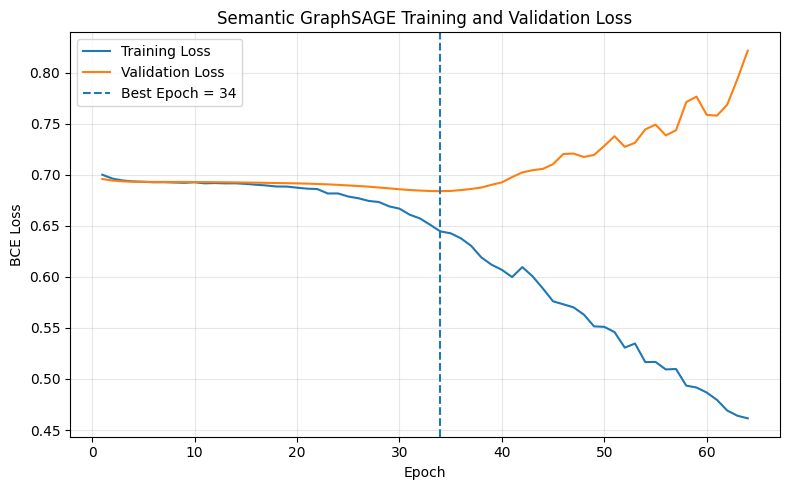

In [57]:
# ============================================================
# STEP 7I - Training / validation loss curve
# ============================================================

import matplotlib.pyplot as plt

epochs_ran = range(
    1,
    len(train_losses) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_ran,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs_ran,
    val_losses,
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("BCE Loss")

plt.title(
    "Semantic GraphSAGE Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [58]:
# STEP 7F - Diagnose validation performance
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score
)

model.eval()

with torch.no_grad():

    val_scores = model(
        x_device,
        edge_index_device,
        val_learner_idx_device,
        val_course_idx_device
    )

    val_probabilities = torch.sigmoid(
        val_scores
    ).cpu().numpy()

    val_true = (
        val_labels_device
        .cpu()
        .numpy()
    )


# ------------------------------------------------------------
# Classification accuracy
# ------------------------------------------------------------

val_predictions = (
    val_probabilities >= 0.5
).astype(int)

val_accuracy = accuracy_score(
    val_true,
    val_predictions
)


# ------------------------------------------------------------
# ROC-AUC
# ------------------------------------------------------------

val_auc = roc_auc_score(
    val_true,
    val_probabilities
)


print(
    "Validation Accuracy:",
    round(val_accuracy, 4)
)

print(
    "Validation ROC-AUC:",
    round(val_auc, 4)
)

# ------------------------------------------------------------
# Pairwise ranking:
# Does the validation positive score higher than
# the validation negative for the SAME learner?
# ------------------------------------------------------------

model.eval()

with torch.no_grad():

    Z_val = model.encode(
        x_device,
        edge_index_device
    )


pairwise_correct = 0
pairwise_total = 0


for lid in learners_df["Learner ID"]:

    learner_rows = validation_pairs_df[
        validation_pairs_df["Learner ID"] == lid
    ]

    positive_course = learner_rows[
        learner_rows["Label"] == 1
    ]["Course ID"].iloc[0]

    negative_course = learner_rows[
        learner_rows["Label"] == 0
    ]["Course ID"].iloc[0]


    learner_idx = node_to_idx[lid]

    positive_idx = node_to_idx[
        positive_course
    ]

    negative_idx = node_to_idx[
        negative_course
    ]


    positive_score = (
        Z_val[learner_idx]
        * Z_val[positive_idx]
    ).sum().item()

    negative_score = (
        Z_val[learner_idx]
        * Z_val[negative_idx]
    ).sum().item()


    if positive_score > negative_score:
        pairwise_correct += 1

    pairwise_total += 1


pairwise_accuracy = (
    pairwise_correct
    / pairwise_total
)


print(
    "Pairwise validation accuracy:",
    round(pairwise_accuracy, 4)
)

print(
    "Correct learner rankings:",
    pairwise_correct,
    "/",
    pairwise_total
)

Validation Accuracy: 0.5575
Validation ROC-AUC: 0.5781
Pairwise validation accuracy: 0.595
Correct learner rankings: 119 / 200


In [59]:
# ============================================================
# STEP 7J - Build BPR training triplets
# ============================================================

import random
import pandas as pd

BPR_SEED = 42
bpr_rng = random.Random(BPR_SEED)

train_triplets = []


for lid in learners_df["Learner ID"]:

    learner_pairs = training_pairs_df[
        training_pairs_df["Learner ID"] == lid
    ]

    positives = list(
        learner_pairs[
            learner_pairs["Label"] == 1
        ]["Course ID"]
    )

    negatives = list(
        learner_pairs[
            learner_pairs["Label"] == 0
        ]["Course ID"]
    )

    # Every learner must have:
    # 3 positive training interactions
    # 3 sampled non-interactions
    assert len(positives) == 3
    assert len(negatives) == 3

    # Randomize the pairing reproducibly
    bpr_rng.shuffle(negatives)

    for positive_course, negative_course in zip(
        positives,
        negatives
    ):

        train_triplets.append({
            "Learner ID": lid,
            "Positive Course": positive_course,
            "Negative Course": negative_course
        })


train_triplets_df = pd.DataFrame(
    train_triplets
)


print(
    "Training BPR triplets:",
    len(train_triplets_df)
)

print(
    "\nExample triplets:"
)

print(
    train_triplets_df.head()
)

Training BPR triplets: 600

Example triplets:
  Learner ID Positive Course Negative Course
0         L1            C554            C215
1         L1            C227            C751
2         L1            C221           C1789
3         L2           C1194            C710
4         L2           C2744           C1065


In [60]:
# ============================================================
# Convert BPR training triplets to tensors
# ============================================================

bpr_learner_idx = torch.tensor(
    [
        node_to_idx[lid]
        for lid in train_triplets_df[
            "Learner ID"
        ]
    ],
    dtype=torch.long,
    device=device
)

bpr_positive_idx = torch.tensor(
    [
        node_to_idx[cid]
        for cid in train_triplets_df[
            "Positive Course"
        ]
    ],
    dtype=torch.long,
    device=device
)

bpr_negative_idx = torch.tensor(
    [
        node_to_idx[cid]
        for cid in train_triplets_df[
            "Negative Course"
        ]
    ],
    dtype=torch.long,
    device=device
)


print(
    "BPR learner tensor:",
    bpr_learner_idx.shape
)

print(
    "BPR positive tensor:",
    bpr_positive_idx.shape
)

print(
    "BPR negative tensor:",
    bpr_negative_idx.shape
)

BPR learner tensor: torch.Size([600])
BPR positive tensor: torch.Size([600])
BPR negative tensor: torch.Size([600])


In [61]:
# ============================================================
# STEP 7K - Build BPR validation triplets
# ============================================================

validation_triplets = []


for lid in learners_df["Learner ID"]:

    learner_rows = validation_pairs_df[
        validation_pairs_df["Learner ID"] == lid
    ]

    positive_course = learner_rows[
        learner_rows["Label"] == 1
    ]["Course ID"].iloc[0]

    negative_course = learner_rows[
        learner_rows["Label"] == 0
    ]["Course ID"].iloc[0]

    validation_triplets.append({
        "Learner ID": lid,
        "Positive Course": positive_course,
        "Negative Course": negative_course
    })


validation_triplets_df = pd.DataFrame(
    validation_triplets
)


print(
    "Validation BPR triplets:",
    len(validation_triplets_df)
)

Validation BPR triplets: 200


In [62]:
# ============================================================
# Convert BPR validation triplets to tensors
# ============================================================

val_bpr_learner_idx = torch.tensor(
    [
        node_to_idx[lid]
        for lid in validation_triplets_df[
            "Learner ID"
        ]
    ],
    dtype=torch.long,
    device=device
)

val_bpr_positive_idx = torch.tensor(
    [
        node_to_idx[cid]
        for cid in validation_triplets_df[
            "Positive Course"
        ]
    ],
    dtype=torch.long,
    device=device
)

val_bpr_negative_idx = torch.tensor(
    [
        node_to_idx[cid]
        for cid in validation_triplets_df[
            "Negative Course"
        ]
    ],
    dtype=torch.long,
    device=device
)


print(
    "Validation learner tensor:",
    val_bpr_learner_idx.shape
)

print(
    "Validation positive tensor:",
    val_bpr_positive_idx.shape
)

print(
    "Validation negative tensor:",
    val_bpr_negative_idx.shape
)

Validation learner tensor: torch.Size([200])
Validation positive tensor: torch.Size([200])
Validation negative tensor: torch.Size([200])


In [63]:
# ============================================================
# STEP 7L - Fresh Semantic GraphSAGE for BPR training
# ============================================================

import random
import numpy as np
import torch
import torch.nn.functional as F

BPR_TRAIN_SEED = 42

random.seed(BPR_TRAIN_SEED)
np.random.seed(BPR_TRAIN_SEED)
torch.manual_seed(BPR_TRAIN_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(BPR_TRAIN_SEED)


# ------------------------------------------------------------
# BPR loss
# ------------------------------------------------------------

def bpr_loss(
    positive_scores,
    negative_scores
):
    """
    Bayesian Personalized Ranking loss.

    Encourages:
        score(user, positive)
        >
        score(user, negative)
    """

    score_difference = (
        positive_scores
        - negative_scores
    )

    return (
        -F.logsigmoid(
            score_difference
        ).mean()
    )


# ------------------------------------------------------------
# Fresh model
# ------------------------------------------------------------

bpr_model = GraphSAGERecommender(
    input_dim=x_semantic.shape[1],
    hidden_dim=64,
    output_dim=32,
    dropout=0.3
).to(device)


bpr_optimizer = torch.optim.Adam(
    bpr_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


print(bpr_model)

GraphSAGERecommender(
  (conv1): SAGEConv(392, 64, aggr=mean)
  (conv2): SAGEConv(64, 32, aggr=mean)
)


In [64]:
# ============================================================
# STEP 7M - Train Semantic GraphSAGE with BPR loss
# ============================================================

import copy

MAX_EPOCHS = 300
PATIENCE = 30

bpr_train_losses = []
bpr_val_losses = []
bpr_val_pairwise_history = []

best_bpr_val_loss = float("inf")
best_bpr_epoch = 0
best_bpr_model_state = None

epochs_without_improvement = 0


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    # ========================================================
    # TRAINING
    # ========================================================

    bpr_model.train()

    bpr_optimizer.zero_grad()

    # Encode all graph nodes
    z = bpr_model.encode(
        x_device,
        edge_index_device
    )


    # --------------------------------------------------------
    # Training positive scores
    # --------------------------------------------------------

    train_positive_scores = (
        z[bpr_learner_idx]
        *
        z[bpr_positive_idx]
    ).sum(dim=1)


    # --------------------------------------------------------
    # Training negative scores
    # --------------------------------------------------------

    train_negative_scores = (
        z[bpr_learner_idx]
        *
        z[bpr_negative_idx]
    ).sum(dim=1)


    train_loss = bpr_loss(
        train_positive_scores,
        train_negative_scores
    )

    train_loss.backward()

    bpr_optimizer.step()


    # ========================================================
    # VALIDATION
    # ========================================================

    bpr_model.eval()

    with torch.no_grad():

        z_val = bpr_model.encode(
            x_device,
            edge_index_device
        )


        val_positive_scores = (
            z_val[val_bpr_learner_idx]
            *
            z_val[val_bpr_positive_idx]
        ).sum(dim=1)


        val_negative_scores = (
            z_val[val_bpr_learner_idx]
            *
            z_val[val_bpr_negative_idx]
        ).sum(dim=1)


        val_loss = bpr_loss(
            val_positive_scores,
            val_negative_scores
        )


        # Percentage of learners for which
        # positive course ranks above negative course
        val_pairwise_accuracy = (
            val_positive_scores
            >
            val_negative_scores
        ).float().mean().item()


    # ========================================================
    # Record metrics
    # ========================================================

    train_loss_value = (
        train_loss.item()
    )

    val_loss_value = (
        val_loss.item()
    )


    bpr_train_losses.append(
        train_loss_value
    )

    bpr_val_losses.append(
        val_loss_value
    )

    bpr_val_pairwise_history.append(
        val_pairwise_accuracy
    )


    # ========================================================
    # Early stopping using VALIDATION BPR loss
    # ========================================================

    if (
        val_loss_value
        <
        best_bpr_val_loss - 1e-5
    ):

        best_bpr_val_loss = (
            val_loss_value
        )

        best_bpr_epoch = epoch

        best_bpr_model_state = (
            copy.deepcopy(
                bpr_model.state_dict()
            )
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    # ========================================================
    # Progress
    # ========================================================

    if (
        epoch == 1
        or epoch % 20 == 0
    ):

        print(
            f"Epoch {epoch:3d} | "
            f"Train BPR Loss: "
            f"{train_loss_value:.4f} | "
            f"Val BPR Loss: "
            f"{val_loss_value:.4f} | "
            f"Val Pairwise: "
            f"{val_pairwise_accuracy:.4f}"
        )


    # ========================================================
    # Stop
    # ========================================================

    if (
        epochs_without_improvement
        >= PATIENCE
    ):

        print(
            f"\nEarly stopping "
            f"at epoch {epoch}."
        )

        break


# ============================================================
# Restore best validation model
# ============================================================

assert best_bpr_model_state is not None

bpr_model.load_state_dict(
    best_bpr_model_state
)


print(
    "\nBest BPR epoch:",
    best_bpr_epoch
)

print(
    "Best validation BPR loss:",
    round(
        best_bpr_val_loss,
        4
    )
)

print(
    "Training BPR loss at best epoch:",
    round(
        bpr_train_losses[
            best_bpr_epoch - 1
        ],
        4
    )
)

print(
    "Validation pairwise accuracy "
    "at best epoch:",
    round(
        bpr_val_pairwise_history[
            best_bpr_epoch - 1
        ],
        4
    )
)


torch.save(
    bpr_model.state_dict(),
    "graphsage_semantic_bpr_best.pt"
)

print(
    "\nBest BPR model restored and saved."
)

Epoch   1 | Train BPR Loss: 0.6949 | Val BPR Loss: 0.6932 | Val Pairwise: 0.5050
Epoch  20 | Train BPR Loss: 0.5767 | Val BPR Loss: 0.6964 | Val Pairwise: 0.5550
Epoch  40 | Train BPR Loss: 0.2961 | Val BPR Loss: 0.8562 | Val Pairwise: 0.5150

Early stopping at epoch 45.

Best BPR epoch: 15
Best validation BPR loss: 0.6856
Training BPR loss at best epoch: 0.6379
Validation pairwise accuracy at best epoch: 0.56

Best BPR model restored and saved.


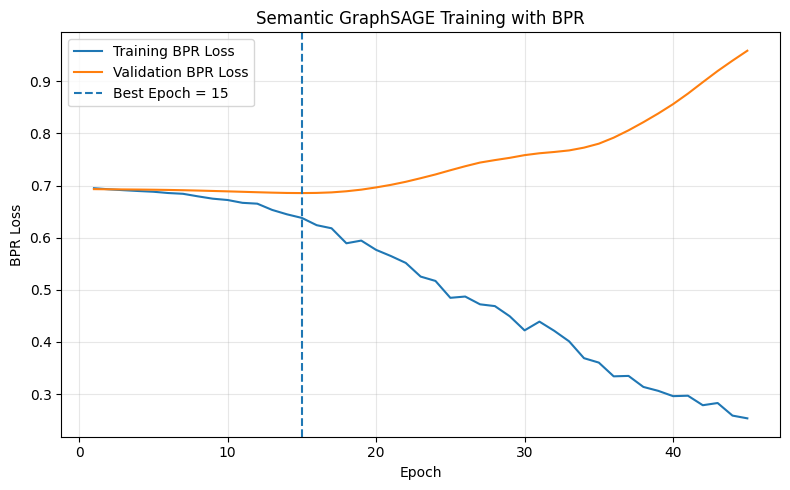

In [65]:
# ============================================================
# STEP 7N - Plot BPR training and validation loss
# ============================================================

import matplotlib.pyplot as plt

epochs_ran = range(
    1,
    len(bpr_train_losses) + 1
)

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    epochs_ran,
    bpr_train_losses,
    label="Training BPR Loss"
)

plt.plot(
    epochs_ran,
    bpr_val_losses,
    label="Validation BPR Loss"
)

plt.axvline(
    best_bpr_epoch,
    linestyle="--",
    label=(
        f"Best Epoch = "
        f"{best_bpr_epoch}"
    )
)

plt.xlabel("Epoch")
plt.ylabel("BPR Loss")

plt.title(
    "Semantic GraphSAGE "
    "Training with BPR"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [66]:
# ============================================================
# STEP 7O - Diagnose BPR validation performance
# ============================================================

from sklearn.metrics import roc_auc_score
import numpy as np


bpr_model.eval()


with torch.no_grad():

    Z_bpr = bpr_model.encode(
        x_device,
        edge_index_device
    )


    # --------------------------------------------------------
    # Validation positive scores
    # --------------------------------------------------------

    bpr_val_positive_scores = (
        Z_bpr[val_bpr_learner_idx]
        *
        Z_bpr[val_bpr_positive_idx]
    ).sum(dim=1)


    # --------------------------------------------------------
    # Validation negative scores
    # --------------------------------------------------------

    bpr_val_negative_scores = (
        Z_bpr[val_bpr_learner_idx]
        *
        Z_bpr[val_bpr_negative_idx]
    ).sum(dim=1)


# ============================================================
# Pairwise accuracy
# ============================================================

bpr_pairwise_accuracy = (
    bpr_val_positive_scores
    >
    bpr_val_negative_scores
).float().mean().item()


correct_rankings = int(
    (
        bpr_val_positive_scores
        >
        bpr_val_negative_scores
    ).sum().item()
)


# ============================================================
# Mean ranking margin
# ============================================================

ranking_margin = (
    bpr_val_positive_scores
    -
    bpr_val_negative_scores
)

mean_margin = (
    ranking_margin
    .mean()
    .item()
)


# ============================================================
# ROC-AUC
#
# Combine positive and negative scores.
# ============================================================

auc_scores = torch.cat(
    [
        bpr_val_positive_scores,
        bpr_val_negative_scores
    ]
).cpu().numpy()


auc_labels = np.concatenate(
    [
        np.ones(
            len(
                bpr_val_positive_scores
            )
        ),

        np.zeros(
            len(
                bpr_val_negative_scores
            )
        )
    ]
)


bpr_auc = roc_auc_score(
    auc_labels,
    auc_scores
)


print(
    "BPR Validation ROC-AUC:",
    round(
        bpr_auc,
        4
    )
)

print(
    "BPR Pairwise validation accuracy:",
    round(
        bpr_pairwise_accuracy,
        4
    )
)

print(
    "Correct learner rankings:",
    correct_rankings,
    "/ 200"
)

print(
    "Mean positive-negative margin:",
    round(
        mean_margin,
        4
    )
)

BPR Validation ROC-AUC: 0.5234
BPR Pairwise validation accuracy: 0.56
Correct learner rankings: 112 / 200
Mean positive-negative margin: 0.0345


In [67]:
# ============================================================
# STEP 7P - Build validation ranking candidate pools
# ============================================================

def validation_candidate_pool(lid):

    learner = learners_df[
        learners_df["Learner ID"] == lid
    ].iloc[0]

    domain = learner[
        "Preferred Domain"
    ]

    level = learner[
        "Current Level Score"
    ]

    train_courses = set(
        learner[
            "Train Completed Courses"
        ]
    )

    validation_course = learner[
        "Validation Course"
    ]

    test_course = learner[
        "Test Course"
    ]


    # Candidate courses must belong to the learner's domain
    # and have a compatible calibrated difficulty.
    pool = df_clean[
        (df_clean["Assigned Domain"] == domain)
        &
        (df_clean["Difficulty Score"] > 0)
        &
        (df_clean["Difficulty Score"] <= level)
    ].copy()


    # --------------------------------------------------------
    # Remove interactions that must not be ranked:
    #
    # - training courses are already known/completed
    # - test course remains reserved for final evaluation
    #
    # IMPORTANT:
    # validation course is NOT removed.
    # --------------------------------------------------------

    excluded = (
        train_courses
        | {test_course}
    )

    pool = pool[
        ~pool["Course ID"].isin(
            excluded
        )
    ]


    # Safety check:
    # validation positive must be present
    assert (
        validation_course
        in set(pool["Course ID"])
    )


    return pool

In [68]:
# ============================================================
# Verify validation candidate pools
# ============================================================

candidate_sizes = []


for lid in learners_df["Learner ID"]:

    pool = validation_candidate_pool(
        lid
    )

    candidate_sizes.append(
        len(pool)
    )


print(
    "Validation learners:",
    len(candidate_sizes)
)

print(
    "Average candidate pool size:",
    round(
        np.mean(candidate_sizes),
        2
    )
)

print(
    "Minimum candidate pool size:",
    min(candidate_sizes)
)

print(
    "Maximum candidate pool size:",
    max(candidate_sizes)
)

Validation learners: 200
Average candidate pool size: 338.96
Minimum candidate pool size: 20
Maximum candidate pool size: 772


In [69]:
# ============================================================
# STEP 7Q - Validation ranking evaluation
# BCE vs BPR
# ============================================================

import numpy as np


# ------------------------------------------------------------
# Obtain embeddings once from each model
# ------------------------------------------------------------

model.eval()
bpr_model.eval()


with torch.no_grad():

    Z_bce = model.encode(
        x_device,
        edge_index_device
    )

    Z_bpr = bpr_model.encode(
        x_device,
        edge_index_device
    )


# ------------------------------------------------------------
# Ranking metrics
# ------------------------------------------------------------

def reciprocal_rank(
    ranked_courses,
    relevant_course
):

    for rank, cid in enumerate(
        ranked_courses,
        start=1
    ):

        if cid == relevant_course:

            return 1.0 / rank

    return 0.0


def hit_at_k_single(
    ranked_courses,
    relevant_course,
    k
):

    return float(
        relevant_course
        in ranked_courses[:k]
    )


def ndcg_at_k_single(
    ranked_courses,
    relevant_course,
    k
):

    for index, cid in enumerate(
        ranked_courses[:k]
    ):

        if cid == relevant_course:

            return (
                1.0
                /
                np.log2(index + 2)
            )

    return 0.0


# ------------------------------------------------------------
# Ranking function
# ------------------------------------------------------------

def rank_with_embeddings(
    lid,
    pool,
    embeddings
):

    learner_idx = node_to_idx[
        lid
    ]

    course_ids = list(
        pool["Course ID"]
    )

    course_indices = torch.tensor(
        [
            node_to_idx[cid]
            for cid in course_ids
        ],
        dtype=torch.long,
        device=device
    )


    learner_vector = embeddings[
        learner_idx
    ]


    scores = (
        embeddings[
            course_indices
        ]
        *
        learner_vector
    ).sum(dim=1)


    order = torch.argsort(
        scores,
        descending=True
    ).cpu().numpy()


    return [
        course_ids[i]
        for i in order
    ]

In [70]:
# ============================================================
# Evaluate BCE and BPR on validation ranking
# ============================================================

validation_ranking_results = []


for model_name, embeddings in [
    ("Semantic GraphSAGE + BCE", Z_bce),
    ("Semantic GraphSAGE + BPR", Z_bpr)
]:

    hit5 = []
    hit10 = []

    ndcg5 = []
    ndcg10 = []

    reciprocal_ranks = []


    for _, learner in learners_df.iterrows():

        lid = learner[
            "Learner ID"
        ]

        validation_course = learner[
            "Validation Course"
        ]

        pool = validation_candidate_pool(
            lid
        )


        ranked = rank_with_embeddings(
            lid,
            pool,
            embeddings
        )


        hit5.append(
            hit_at_k_single(
                ranked,
                validation_course,
                5
            )
        )

        hit10.append(
            hit_at_k_single(
                ranked,
                validation_course,
                10
            )
        )


        ndcg5.append(
            ndcg_at_k_single(
                ranked,
                validation_course,
                5
            )
        )

        ndcg10.append(
            ndcg_at_k_single(
                ranked,
                validation_course,
                10
            )
        )


        reciprocal_ranks.append(
            reciprocal_rank(
                ranked,
                validation_course
            )
        )


    validation_ranking_results.append({
        "Model": model_name,

        "Hit@5":
            np.mean(hit5),

        "Hit@10":
            np.mean(hit10),

        "NDCG@5":
            np.mean(ndcg5),

        "NDCG@10":
            np.mean(ndcg10),

        "MRR":
            np.mean(
                reciprocal_ranks
            )
    })


validation_ranking_df = pd.DataFrame(
    validation_ranking_results
)


validation_ranking_df

,Model,Hit@5,Hit@10,NDCG@5,NDCG@10,MRR
0,Semantic GraphSAGE + BCE,0.015,0.045,0.011309,0.021220,0.028770
1,Semantic GraphSAGE + BPR,0.030,0.060,0.016896,0.026334,0.028938


In [71]:
# ============================================================
# STEP 7R - Validation baselines on the SAME candidate pools
# ============================================================

import random
import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# 1. Random ranking
# ------------------------------------------------------------

def validation_random_ranking(
    lid,
    pool,
    seed=42
):

    ids = list(
        pool["Course ID"]
    )

    # Different but reproducible shuffle for each learner
    learner_number = int(
        lid.replace("L", "")
    )

    rng = random.Random(
        seed + learner_number
    )

    rng.shuffle(ids)

    return ids


# ------------------------------------------------------------
# 2. Rating-based ranking
#
# This is NOT called "Popularity" because we are sorting
# according to course rating, not interaction/popularity count.
# ------------------------------------------------------------

def validation_rating_ranking(
    lid,
    pool
):

    ranked_pool = pool.copy()

    ranked_pool[
        "_rating_numeric"
    ] = pd.to_numeric(
        ranked_pool["Course Rating"],
        errors="coerce"
    )

    ranked_pool[
        "_rating_numeric"
    ] = ranked_pool[
        "_rating_numeric"
    ].fillna(
        ranked_pool[
            "_rating_numeric"
        ].mean()
    )

    ranked_pool = ranked_pool.sort_values(
        "_rating_numeric",
        ascending=False
    )

    return list(
        ranked_pool["Course ID"]
    )


# ------------------------------------------------------------
# 3. Target-skill overlap ranking
#
# IMPORTANT:
# Target skills no longer define the validation ground truth.
# Therefore this is now an independent baseline.
# ------------------------------------------------------------

def validation_skill_overlap_ranking(
    lid,
    pool
):

    learner = learners_df[
        learners_df["Learner ID"] == lid
    ].iloc[0]

    target_skills = set(
        learner["Target Skills"]
    )

    ranked_pool = pool.copy()

    ranked_pool[
        "_skill_overlap"
    ] = ranked_pool[
        "Skills List"
    ].apply(
        lambda skills:
        len(
            set(skills)
            & target_skills
        )
    )


    # Numeric rating only used as a tie-breaker
    ranked_pool[
        "_rating_numeric"
    ] = pd.to_numeric(
        ranked_pool["Course Rating"],
        errors="coerce"
    )

    ranked_pool[
        "_rating_numeric"
    ] = ranked_pool[
        "_rating_numeric"
    ].fillna(
        ranked_pool[
            "_rating_numeric"
        ].mean()
    )


    ranked_pool = ranked_pool.sort_values(
        [
            "_skill_overlap",
            "_rating_numeric"
        ],
        ascending=[
            False,
            False
        ]
    )

    return list(
        ranked_pool["Course ID"]
    )


# ------------------------------------------------------------
# 4. SBERT content-only ranking
#
# No GraphSAGE.
# No message passing.
#
# This tells us whether the graph adds value beyond
# the semantic representations themselves.
# ------------------------------------------------------------

def validation_sbert_ranking(
    lid,
    pool
):

    learner_idx = node_to_idx[
        lid
    ]

    course_ids = list(
        pool["Course ID"]
    )

    course_indices = torch.tensor(
        [
            node_to_idx[cid]
            for cid in course_ids
        ],
        dtype=torch.long
    )


    learner_vector = (
        semantic_embeddings[
            learner_idx
        ]
    )


    course_vectors = (
        semantic_embeddings[
            course_indices
        ]
    )


    # Embeddings were normalized during SBERT encoding,
    # so dot product is equivalent to cosine similarity.
    scores = (
        course_vectors
        *
        learner_vector
    ).sum(dim=1)


    order = torch.argsort(
        scores,
        descending=True
    ).cpu().numpy()


    return [
        course_ids[i]
        for i in order
    ]

In [72]:
# ============================================================
# STEP 7S - Evaluate validation baselines
# ============================================================

baseline_methods = {
    "Random": validation_random_ranking,
    "Rating-Based": validation_rating_ranking,
    "Target-Skill Overlap":
        validation_skill_overlap_ranking,
    "SBERT Content-Only":
        validation_sbert_ranking
}


baseline_results = []


for method_name, ranking_function in (
    baseline_methods.items()
):

    hit5 = []
    hit10 = []

    ndcg5 = []
    ndcg10 = []

    reciprocal_ranks = []


    for _, learner in learners_df.iterrows():

        lid = learner[
            "Learner ID"
        ]

        validation_course = learner[
            "Validation Course"
        ]

        pool = validation_candidate_pool(
            lid
        )


        ranked = ranking_function(
            lid,
            pool
        )


        hit5.append(
            hit_at_k_single(
                ranked,
                validation_course,
                5
            )
        )

        hit10.append(
            hit_at_k_single(
                ranked,
                validation_course,
                10
            )
        )


        ndcg5.append(
            ndcg_at_k_single(
                ranked,
                validation_course,
                5
            )
        )

        ndcg10.append(
            ndcg_at_k_single(
                ranked,
                validation_course,
                10
            )
        )


        reciprocal_ranks.append(
            reciprocal_rank(
                ranked,
                validation_course
            )
        )


    baseline_results.append({
        "Model": method_name,

        "Hit@5":
            np.mean(hit5),

        "Hit@10":
            np.mean(hit10),

        "NDCG@5":
            np.mean(ndcg5),

        "NDCG@10":
            np.mean(ndcg10),

        "MRR":
            np.mean(
                reciprocal_ranks
            )
    })


validation_baselines_df = pd.DataFrame(
    baseline_results
)


# ------------------------------------------------------------
# Add the two GraphSAGE results we already calculated
# ------------------------------------------------------------

full_validation_comparison = pd.concat(
    [
        validation_baselines_df,
        validation_ranking_df
    ],
    ignore_index=True
)


full_validation_comparison

,Model,Hit@5,Hit@10,NDCG@5,NDCG@10,MRR
0,Random,0.025,0.050,0.015803,0.024054,0.030107
1,Rating-Based,0.005,0.010,0.001934,0.003715,0.016077
2,Target-Skill Overlap,0.035,0.060,0.016896,0.025249,0.026416
3,SBERT Content-Only,0.070,0.135,0.053463,0.074187,0.069222
4,Semantic GraphSAGE + BCE,0.015,0.045,0.011309,0.021220,0.028770
5,Semantic GraphSAGE + BPR,0.030,0.060,0.016896,0.026334,0.028938


In [73]:
# ============================================================
# STEP 7T - Residual Semantic GraphSAGE
# ============================================================

from torch_geometric.nn import SAGEConv
import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualSemanticGraphSAGE(nn.Module):

    def __init__(
        self,
        input_dim=392,
        semantic_dim=384,
        hidden_dim=128,
        dropout=0.3
    ):
        super().__init__()

        self.semantic_dim = semantic_dim

        # ----------------------------------------------------
        # Graph branch
        #
        # Full structural + semantic input:
        # 392 -> 128 -> 384
        #
        # Final graph representation has same dimension
        # as original SBERT representation.
        # ----------------------------------------------------

        self.conv1 = SAGEConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = SAGEConv(
            hidden_dim,
            semantic_dim
        )

        self.dropout = dropout


        # ----------------------------------------------------
        # Learnable graph contribution
        #
        # Start small so that the model initially preserves
        # the strong SBERT representation.
        #
        # sigmoid(-2) ≈ 0.12
        # ----------------------------------------------------

        self.graph_gate_logit = nn.Parameter(
            torch.tensor(-2.0)
        )


    def encode(
        self,
        x,
        edge_index
    ):

        # ====================================================
        # ORIGINAL SEMANTIC REPRESENTATION
        # ====================================================

        # Last 384 dimensions correspond to SBERT.
        semantic_base = x[
            :,
            -self.semantic_dim:
        ]


        # ====================================================
        # GRAPH MESSAGE-PASSING BRANCH
        # ====================================================

        h = self.conv1(
            x,
            edge_index
        )

        h = F.relu(h)

        h = F.dropout(
            h,
            p=self.dropout,
            training=self.training
        )

        h = self.conv2(
            h,
            edge_index
        )


        # ====================================================
        # RESIDUAL FUSION
        # ====================================================

        graph_weight = torch.sigmoid(
            self.graph_gate_logit
        )

        z = (
            semantic_base
            +
            graph_weight * h
        )


        # Normalize for stable ranking similarity
        z = F.normalize(
            z,
            p=2,
            dim=1
        )

        return z


    def score(
        self,
        z,
        learner_idx,
        course_idx
    ):

        learner_z = z[
            learner_idx
        ]

        course_z = z[
            course_idx
        ]

        return (
            learner_z
            *
            course_z
        ).sum(dim=1)


    def forward(
        self,
        x,
        edge_index,
        learner_idx,
        course_idx
    ):

        z = self.encode(
            x,
            edge_index
        )

        return self.score(
            z,
            learner_idx,
            course_idx
        )

In [74]:
# ============================================================
# STEP 7U - Instantiate residual model
# ============================================================

import random
import numpy as np
import torch

RESIDUAL_SEED = 42

random.seed(RESIDUAL_SEED)
np.random.seed(RESIDUAL_SEED)
torch.manual_seed(RESIDUAL_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        RESIDUAL_SEED
    )


residual_model = ResidualSemanticGraphSAGE(
    input_dim=x_semantic.shape[1],   # 392
    semantic_dim=384,
    hidden_dim=128,
    dropout=0.3
).to(device)


residual_optimizer = torch.optim.Adam(
    residual_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


print(residual_model)

print(
    "\nInitial graph weight:",
    round(
        torch.sigmoid(
            residual_model.graph_gate_logit
        ).item(),
        4
    )
)

ResidualSemanticGraphSAGE(
  (conv1): SAGEConv(392, 128, aggr=mean)
  (conv2): SAGEConv(128, 384, aggr=mean)
)

Initial graph weight: 0.1192


In [75]:
# ============================================================
# STEP 7V - Train Residual Semantic GraphSAGE with BPR
# ============================================================

import copy

MAX_EPOCHS = 300
PATIENCE = 30

residual_train_losses = []
residual_val_losses = []
residual_pairwise_history = []
residual_gate_history = []

best_residual_val_loss = float("inf")
best_residual_epoch = 0
best_residual_state = None

epochs_without_improvement = 0


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    # ========================================================
    # TRAIN
    # ========================================================

    residual_model.train()

    residual_optimizer.zero_grad()


    z = residual_model.encode(
        x_device,
        edge_index_device
    )


    positive_scores = residual_model.score(
        z,
        bpr_learner_idx,
        bpr_positive_idx
    )


    negative_scores = residual_model.score(
        z,
        bpr_learner_idx,
        bpr_negative_idx
    )


    train_loss = bpr_loss(
        positive_scores,
        negative_scores
    )


    train_loss.backward()

    residual_optimizer.step()


    # ========================================================
    # VALIDATION
    # ========================================================

    residual_model.eval()


    with torch.no_grad():

        z_val = residual_model.encode(
            x_device,
            edge_index_device
        )


        val_positive_scores = (
            residual_model.score(
                z_val,
                val_bpr_learner_idx,
                val_bpr_positive_idx
            )
        )


        val_negative_scores = (
            residual_model.score(
                z_val,
                val_bpr_learner_idx,
                val_bpr_negative_idx
            )
        )


        val_loss = bpr_loss(
            val_positive_scores,
            val_negative_scores
        )


        val_pairwise = (
            val_positive_scores
            >
            val_negative_scores
        ).float().mean().item()


        graph_weight = (
            torch.sigmoid(
                residual_model.graph_gate_logit
            ).item()
        )


    train_loss_value = (
        train_loss.item()
    )

    val_loss_value = (
        val_loss.item()
    )


    residual_train_losses.append(
        train_loss_value
    )

    residual_val_losses.append(
        val_loss_value
    )

    residual_pairwise_history.append(
        val_pairwise
    )

    residual_gate_history.append(
        graph_weight
    )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if (
        val_loss_value
        <
        best_residual_val_loss - 1e-5
    ):

        best_residual_val_loss = (
            val_loss_value
        )

        best_residual_epoch = epoch

        best_residual_state = (
            copy.deepcopy(
                residual_model.state_dict()
            )
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if (
        epoch == 1
        or epoch % 20 == 0
    ):

        print(
            f"Epoch {epoch:3d} | "
            f"Train BPR: "
            f"{train_loss_value:.4f} | "
            f"Val BPR: "
            f"{val_loss_value:.4f} | "
            f"Pairwise: "
            f"{val_pairwise:.4f} | "
            f"Graph weight: "
            f"{graph_weight:.4f}"
        )


    if (
        epochs_without_improvement
        >= PATIENCE
    ):

        print(
            f"\nEarly stopping "
            f"at epoch {epoch}."
        )

        break


# ============================================================
# Restore best model
# ============================================================

assert best_residual_state is not None

residual_model.load_state_dict(
    best_residual_state
)


final_graph_weight = (
    torch.sigmoid(
        residual_model.graph_gate_logit
    ).item()
)


print(
    "\nBest epoch:",
    best_residual_epoch
)

print(
    "Best validation BPR loss:",
    round(
        best_residual_val_loss,
        4
    )
)

print(
    "Pairwise accuracy at best epoch:",
    round(
        residual_pairwise_history[
            best_residual_epoch - 1
        ],
        4
    )
)

print(
    "Learned graph weight:",
    round(
        final_graph_weight,
        4
    )
)


torch.save(
    residual_model.state_dict(),
    "residual_semantic_graphsage_bpr.pt"
)

print(
    "\nBest residual model restored and saved."
)

Epoch   1 | Train BPR: 0.6835 | Val BPR: 0.6796 | Pairwise: 0.5800 | Graph weight: 0.1191
Epoch  20 | Train BPR: 0.6513 | Val BPR: 0.6675 | Pairwise: 0.5850 | Graph weight: 0.1210
Epoch  40 | Train BPR: 0.5470 | Val BPR: 0.6652 | Pairwise: 0.6350 | Graph weight: 0.1237
Epoch  60 | Train BPR: 0.4268 | Val BPR: 0.6843 | Pairwise: 0.5650 | Graph weight: 0.1269

Early stopping at epoch 61.

Best epoch: 31
Best validation BPR loss: 0.6634
Pairwise accuracy at best epoch: 0.595
Learned graph weight: 0.1224

Best residual model restored and saved.


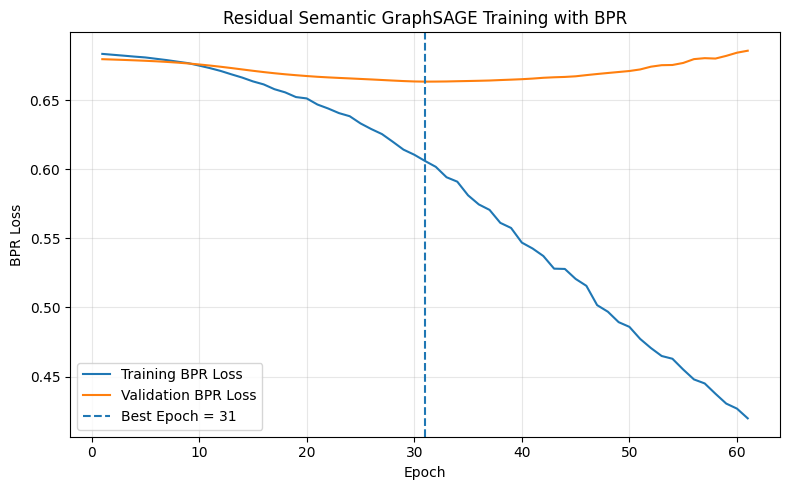

In [76]:
# ============================================================
# STEP 7W - Residual GraphSAGE loss curve
# ============================================================

import matplotlib.pyplot as plt

epochs_ran = range(
    1,
    len(residual_train_losses) + 1
)


plt.figure(
    figsize=(8, 5)
)


plt.plot(
    epochs_ran,
    residual_train_losses,
    label="Training BPR Loss"
)


plt.plot(
    epochs_ran,
    residual_val_losses,
    label="Validation BPR Loss"
)


plt.axvline(
    best_residual_epoch,
    linestyle="--",
    label=(
        f"Best Epoch = "
        f"{best_residual_epoch}"
    )
)


plt.xlabel("Epoch")

plt.ylabel("BPR Loss")

plt.title(
    "Residual Semantic GraphSAGE "
    "Training with BPR"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [77]:
# ============================================================
# STEP 7X - Full-ranking validation of residual model
# ============================================================

residual_model.eval()


with torch.no_grad():

    Z_residual = residual_model.encode(
        x_device,
        edge_index_device
    )


residual_hit5 = []
residual_hit10 = []

residual_ndcg5 = []
residual_ndcg10 = []

residual_rr = []


for _, learner in learners_df.iterrows():

    lid = learner[
        "Learner ID"
    ]

    validation_course = learner[
        "Validation Course"
    ]


    pool = validation_candidate_pool(
        lid
    )


    ranked = rank_with_embeddings(
        lid,
        pool,
        Z_residual
    )


    residual_hit5.append(
        hit_at_k_single(
            ranked,
            validation_course,
            5
        )
    )


    residual_hit10.append(
        hit_at_k_single(
            ranked,
            validation_course,
            10
        )
    )


    residual_ndcg5.append(
        ndcg_at_k_single(
            ranked,
            validation_course,
            5
        )
    )


    residual_ndcg10.append(
        ndcg_at_k_single(
            ranked,
            validation_course,
            10
        )
    )


    residual_rr.append(
        reciprocal_rank(
            ranked,
            validation_course
        )
    )


residual_result = pd.DataFrame([
    {
        "Model":
            "Residual Semantic GraphSAGE + BPR",

        "Hit@5":
            np.mean(
                residual_hit5
            ),

        "Hit@10":
            np.mean(
                residual_hit10
            ),

        "NDCG@5":
            np.mean(
                residual_ndcg5
            ),

        "NDCG@10":
            np.mean(
                residual_ndcg10
            ),

        "MRR":
            np.mean(
                residual_rr
            )
    }
])


residual_result

,Model,Hit@5,Hit@10,NDCG@5,NDCG@10,MRR
0,Residual Semantic GraphSAGE + BPR,0.045,0.08,0.023175,0.034653,0.035522


In [78]:
# ============================================================
# STEP 7Y - Hybrid GNN + Target-Skill Overlap
# ============================================================

import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# Alpha:
#
# alpha = 0.0 -> pure Skill-Overlap
# alpha = 1.0 -> pure Residual GraphSAGE
# ------------------------------------------------------------

ALPHAS = [
    0.0,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    1.0
]


def minmax_normalize(scores):

    score_min = scores.min()
    score_max = scores.max()

    if (score_max - score_min) < 1e-12:
        return torch.zeros_like(scores)

    return (
        scores - score_min
    ) / (
        score_max - score_min
    )

In [79]:
# ============================================================
# Compute residual GNN embeddings once
# ============================================================

residual_model.eval()

with torch.no_grad():

    Z_residual = residual_model.encode(
        x_device,
        edge_index_device
    )


print(
    "Residual embeddings:",
    Z_residual.shape
)

Residual embeddings: torch.Size([9872, 384])


In [80]:
# ============================================================
# STEP 7Z - Validation search for hybrid alpha
# ============================================================

hybrid_skill_results = []


for alpha in ALPHAS:

    hit5 = []
    hit10 = []

    ndcg5 = []
    ndcg10 = []

    reciprocal_ranks = []


    for _, learner in learners_df.iterrows():

        lid = learner["Learner ID"]

        validation_course = learner["Validation Course"]

        target_skills = set(
            learner["Target Skills"]
        )


        # ----------------------------------------------------
        # Same validation candidate pool used everywhere
        # ----------------------------------------------------

        pool = validation_candidate_pool(
            lid
        )

        course_ids = list(
            pool["Course ID"]
        )


        course_indices = torch.tensor(
            [
                node_to_idx[cid]
                for cid in course_ids
            ],
            dtype=torch.long,
            device=device
        )


        learner_idx = node_to_idx[
            lid
        ]


        # ====================================================
        # 1. GNN scores
        # ====================================================

        learner_gnn = Z_residual[
            learner_idx
        ]


        gnn_scores = (
            Z_residual[
                course_indices
            ]
            * learner_gnn
        ).sum(dim=1)


        gnn_scores = minmax_normalize(
            gnn_scores
        )


        # ====================================================
        # 2. Target-Skill Overlap scores
        # ====================================================

        overlap_values = []


        for _, course_row in pool.iterrows():

            overlap = len(
                set(course_row["Skills List"])
                & target_skills
            )

            overlap_values.append(
                float(overlap)
            )


        # Convert ratings exactly as in the original baseline
        rating_values = pd.to_numeric(
            pool["Course Rating"],
            errors="coerce"
        )


        rating_values = rating_values.fillna(
            rating_values.mean()
        ).values


        skill_scores = torch.tensor(
            overlap_values,
            dtype=torch.float32,
            device=device
        )


        rating_scores = torch.tensor(
            rating_values,
            dtype=torch.float32,
            device=device
        )


        # Tiny rating contribution:
        # does not override skill-overlap ordering,
        # only breaks equal-overlap ties.
        skill_scores = (
            skill_scores
            +
            1e-6 * rating_scores
        )


        skill_scores = minmax_normalize(
            skill_scores
        )


        # ====================================================
        # 3. Hybrid
        #
        # Supervisor-suggested form:
        #
        # alpha * GNN
        # +
        # (1-alpha) * SkillOverlap
        # ====================================================

        hybrid_scores = (
            alpha * gnn_scores
            +
            (1.0 - alpha) * skill_scores
        )


        order = torch.argsort(
            hybrid_scores,
            descending=True,
            stable=True
        ).cpu().numpy()


        ranked = [
            course_ids[i]
            for i in order
        ]


        # ====================================================
        # 4. Metrics
        # ====================================================

        hit5.append(
            hit_at_k_single(
                ranked,
                validation_course,
                5
            )
        )


        hit10.append(
            hit_at_k_single(
                ranked,
                validation_course,
                10
            )
        )


        ndcg5.append(
            ndcg_at_k_single(
                ranked,
                validation_course,
                5
            )
        )


        ndcg10.append(
            ndcg_at_k_single(
                ranked,
                validation_course,
                10
            )
        )


        reciprocal_ranks.append(
            reciprocal_rank(
                ranked,
                validation_course
            )
        )


    # ========================================================
    # Store results for this alpha
    # ========================================================

    hybrid_skill_results.append({
        "Alpha": alpha,
        "Hit@5": np.mean(hit5),
        "Hit@10": np.mean(hit10),
        "NDCG@5": np.mean(ndcg5),
        "NDCG@10": np.mean(ndcg10),
        "MRR": np.mean(reciprocal_ranks)
    })


# ============================================================
# Final validation results
# ============================================================

hybrid_skill_validation_df = pd.DataFrame(
    hybrid_skill_results
)


hybrid_skill_validation_df

,Alpha,Hit@5,Hit@10,NDCG@5,NDCG@10,MRR
0,0.0,0.030,0.055,0.014177,0.022602,0.025045
1,0.1,0.040,0.080,0.019544,0.032119,0.031241
2,0.2,0.040,0.080,0.019544,0.032119,0.031241
3,0.3,0.040,0.080,0.019544,0.032119,0.031243
4,0.4,0.040,0.080,0.019890,0.032465,0.031738
5,0.5,0.035,0.080,0.018175,0.032387,0.032228
6,0.6,0.040,0.075,0.020110,0.030670,0.032437
7,0.7,0.030,0.070,0.018463,0.031493,0.035010
8,0.8,0.040,0.090,0.023332,0.039019,0.037245
9,0.9,0.055,0.085,0.030198,0.039254,0.039349


In [81]:
# ============================================================
# STEP 7AA - Select hybrid alpha using validation
# ============================================================

best_hybrid_skill_row = (
    hybrid_skill_validation_df
    .sort_values(
        [
            "NDCG@10",
            "MRR",
            "Hit@10"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .iloc[0]
)


BEST_SKILL_GNN_ALPHA = float(
    best_hybrid_skill_row[
        "Alpha"
    ]
)


print(
    "Best GNN + Skill-Overlap alpha:",
    BEST_SKILL_GNN_ALPHA
)

print(
    "\nBest validation result:"
)

print(
    best_hybrid_skill_row
)

Best GNN + Skill-Overlap alpha: 0.9

Best validation result:
Alpha      0.900000
Hit@5      0.055000
Hit@10     0.085000
NDCG@5     0.030198
NDCG@10    0.039254
MRR        0.039349
Name: 9, dtype: float64


In [147]:
# ============================================================
# STEP 7AB - Component ablation study
#
# alpha = 0.0 -> Skill-Overlap only
# alpha = 1.0 -> Residual GraphSAGE only
# alpha = 0.9 -> Selected hybrid
# ============================================================

ablation_alphas = [
    0.0,
    BEST_SKILL_GNN_ALPHA,
    1.0
]


ablation_labels = {
    0.0: "Skill-Overlap only",
    BEST_SKILL_GNN_ALPHA:
        "Residual GraphSAGE + Skill Hybrid",
    1.0: "Residual GraphSAGE only"
}


ablation_df = (
    hybrid_skill_validation_df[
        hybrid_skill_validation_df[
            "Alpha"
        ].isin(
            ablation_alphas
        )
    ]
    .copy()
)


ablation_df[
    "Configuration"
] = ablation_df[
    "Alpha"
].map(
    ablation_labels
)


ablation_df = ablation_df[
    [
        "Configuration",
        "Alpha",
        "Hit@5",
        "Hit@10",
        "NDCG@5",
        "NDCG@10",
        "MRR"
    ]
]


ablation_df = (
    ablation_df
    .sort_values(
        "Alpha"
    )
    .reset_index(
        drop=True
    )
)


display(
    ablation_df
)

,Configuration,Alpha,Hit@5,Hit@10,NDCG@5,NDCG@10,MRR
0,Skill-Overlap only,0.0,0.030,0.055,0.014177,0.022602,0.025045
1,Residual GraphSAGE + Skill Hybrid,0.9,0.055,0.085,0.030198,0.039254,0.039349
2,Residual GraphSAGE only,1.0,0.045,0.080,0.023175,0.034653,0.035522


## Build LightGCN learner-course interaction graph

In [82]:
import torch
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Learners and courses
# ------------------------------------------------------------

lightgcn_learners = list(
    learners_df["Learner ID"]
)

lightgcn_courses = list(
    df_clean["Course ID"]
)


num_lightgcn_learners = len(
    lightgcn_learners
)

num_lightgcn_courses = len(
    lightgcn_courses
)


# ---------------------------------------------
# Local LightGCN indices
#
# Learners:
# 0 ... 199
#
# Courses:
# 200 ... 3623
# ------------------------------

lightgcn_learner_to_idx = {
    lid: idx
    for idx, lid
    in enumerate(lightgcn_learners)
}

lightgcn_course_to_idx = {
    cid: (
        num_lightgcn_learners + idx
    )
    for idx, cid
    in enumerate(lightgcn_courses)
}


print(
    "LightGCN learners:",
    num_lightgcn_learners
)

print(
    "LightGCN courses:",
    num_lightgcn_courses
)

print(
    "Total LightGCN nodes:",
    num_lightgcn_learners
    + num_lightgcn_courses
)

LightGCN learners: 200
LightGCN courses: 3424
Total LightGCN nodes: 3624


In [83]:
# =====================================
# STEP 8B - LightGCN training edges
# =====================================

light_src = []
light_dst = []


for _, learner in learners_df.iterrows():

    lid = learner[
        "Learner ID"
    ]

    learner_idx = (
        lightgcn_learner_to_idx[
            lid
        ]
    )


    for cid in learner[
        "Train Completed Courses"
    ]:

        course_idx = (
            lightgcn_course_to_idx[
                cid
            ]
        )

        # Learner -> Course
        light_src.append(
            learner_idx
        )

        light_dst.append(
            course_idx
        )

        # Course -> Learner
        light_src.append(
            course_idx
        )

        light_dst.append(
            learner_idx
        )


light_edge_index = torch.tensor(
    [
        light_src,
        light_dst
    ],
    dtype=torch.long
)


print(
    "LightGCN edge_index:",
    light_edge_index.shape
)

print(
    "Undirected training interactions:",
    light_edge_index.shape[1] // 2
)

LightGCN edge_index: torch.Size([2, 1200])
Undirected training interactions: 600


In [84]:
# ============================================================
# STEP 8C - Define LightGCN
# ============================================================

import torch
import torch.nn as nn

from torch_geometric.nn import LGConv


class LightGCNRecommender(nn.Module):

    def __init__(
        self,
        num_nodes,
        embedding_dim=64,
        num_layers=3
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_nodes,
            embedding_dim
        )

        self.convs = nn.ModuleList(
            [
                LGConv()
                for _ in range(num_layers)
            ]
        )

        nn.init.xavier_uniform_(
            self.embedding.weight
        )


    def encode(
        self,
        edge_index
    ):

        # Initial learner/course embeddings
        x = self.embedding.weight

        # LightGCN combines embeddings from
        # layer 0 + every propagation layer
        embeddings = [x]

        for conv in self.convs:

            x = conv(
                x,
                edge_index
            )

            embeddings.append(x)

        # Average representations from all layers
        z = torch.stack(
            embeddings,
            dim=0
        ).mean(dim=0)

        return z


    def score(
        self,
        z,
        learner_idx,
        course_idx
    ):

        learner_z = z[
            learner_idx
        ]

        course_z = z[
            course_idx
        ]

        return (
            learner_z
            * course_z
        ).sum(dim=1)

In [85]:
# =====================================
# STEP 8D - LightGCN BPR tensors
# ====================================

light_bpr_learner_idx = torch.tensor(
    [
        lightgcn_learner_to_idx[lid]
        for lid in train_triplets_df[
            "Learner ID"
        ]
    ],
    dtype=torch.long,
    device=device
)


light_bpr_positive_idx = torch.tensor(
    [
        lightgcn_course_to_idx[cid]
        for cid in train_triplets_df[
            "Positive Course"
        ]
    ],
    dtype=torch.long,
    device=device
)


light_bpr_negative_idx = torch.tensor(
    [
        lightgcn_course_to_idx[cid]
        for cid in train_triplets_df[
            "Negative Course"
        ]
    ],
    dtype=torch.long,
    device=device
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

light_val_learner_idx = torch.tensor(
    [
        lightgcn_learner_to_idx[lid]
        for lid in validation_triplets_df[
            "Learner ID"
        ]
    ],
    dtype=torch.long,
    device=device
)


light_val_positive_idx = torch.tensor(
    [
        lightgcn_course_to_idx[cid]
        for cid in validation_triplets_df[
            "Positive Course"
        ]
    ],
    dtype=torch.long,
    device=device
)


light_val_negative_idx = torch.tensor(
    [
        lightgcn_course_to_idx[cid]
        for cid in validation_triplets_df[
            "Negative Course"
        ]
    ],
    dtype=torch.long,
    device=device
)


light_edge_index_device = (
    light_edge_index.to(device)
)


print(
    "Training learners:",
    light_bpr_learner_idx.shape
)

print(
    "Training positives:",
    light_bpr_positive_idx.shape
)

print(
    "Training negatives:",
    light_bpr_negative_idx.shape
)

print(
    "\nValidation learners:",
    light_val_learner_idx.shape
)

print(
    "Validation positives:",
    light_val_positive_idx.shape
)

print(
    "Validation negatives:",
    light_val_negative_idx.shape
)

Training learners: torch.Size([600])
Training positives: torch.Size([600])
Training negatives: torch.Size([600])

Validation learners: torch.Size([200])
Validation positives: torch.Size([200])
Validation negatives: torch.Size([200])


In [86]:
# ==================================
# STEP 8E - Instantiate LightGCN
# =================================

import random
import numpy as np

LIGHTGCN_SEED = 42

random.seed(LIGHTGCN_SEED)
np.random.seed(LIGHTGCN_SEED)
torch.manual_seed(LIGHTGCN_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        LIGHTGCN_SEED
    )


lightgcn_model = LightGCNRecommender(
    num_nodes=(
        num_lightgcn_learners
        +
        num_lightgcn_courses
    ),
    embedding_dim=64,
    num_layers=3
).to(device)


lightgcn_optimizer = torch.optim.Adam(
    lightgcn_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


print(lightgcn_model)

LightGCNRecommender(
  (embedding): Embedding(3624, 64)
  (convs): ModuleList(
    (0-2): 3 x LGConv()
  )
)


In [87]:
# ============================================================
# STEP 8F - Train LightGCN with BPR
# ============================================================

import copy

MAX_EPOCHS = 300
PATIENCE = 30

light_train_losses = []
light_val_losses = []
light_pairwise_history = []

best_light_val_loss = float("inf")
best_light_epoch = 0
best_light_state = None

epochs_without_improvement = 0


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    # ========================================================
    # TRAIN
    # ========================================================

    lightgcn_model.train()
    lightgcn_optimizer.zero_grad()

    z = lightgcn_model.encode(
        light_edge_index_device
    )


    positive_scores = (
        lightgcn_model.score(
            z,
            light_bpr_learner_idx,
            light_bpr_positive_idx
        )
    )


    negative_scores = (
        lightgcn_model.score(
            z,
            light_bpr_learner_idx,
            light_bpr_negative_idx
        )
    )


    train_loss = bpr_loss(
        positive_scores,
        negative_scores
    )


    train_loss.backward()

    lightgcn_optimizer.step()


    # ========================================================
    # VALIDATION
    # ========================================================

    lightgcn_model.eval()


    with torch.no_grad():

        z_val = lightgcn_model.encode(
            light_edge_index_device
        )


        val_positive_scores = (
            lightgcn_model.score(
                z_val,
                light_val_learner_idx,
                light_val_positive_idx
            )
        )


        val_negative_scores = (
            lightgcn_model.score(
                z_val,
                light_val_learner_idx,
                light_val_negative_idx
            )
        )


        val_loss = bpr_loss(
            val_positive_scores,
            val_negative_scores
        )


        val_pairwise = (
            val_positive_scores
            >
            val_negative_scores
        ).float().mean().item()


    train_loss_value = (
        train_loss.item()
    )

    val_loss_value = (
        val_loss.item()
    )


    light_train_losses.append(
        train_loss_value
    )

    light_val_losses.append(
        val_loss_value
    )

    light_pairwise_history.append(
        val_pairwise
    )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if (
        val_loss_value
        <
        best_light_val_loss - 1e-5
    ):

        best_light_val_loss = (
            val_loss_value
        )

        best_light_epoch = epoch

        best_light_state = copy.deepcopy(
            lightgcn_model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if (
        epoch == 1
        or epoch % 20 == 0
    ):

        print(
            f"Epoch {epoch:3d} | "
            f"Train BPR: "
            f"{train_loss_value:.4f} | "
            f"Val BPR: "
            f"{val_loss_value:.4f} | "
            f"Pairwise: "
            f"{val_pairwise:.4f}"
        )


    if (
        epochs_without_improvement
        >= PATIENCE
    ):

        print(
            f"\nEarly stopping "
            f"at epoch {epoch}."
        )

        break


# ============================================================
# Restore best LightGCN
# ============================================================

assert best_light_state is not None

lightgcn_model.load_state_dict(
    best_light_state
)


print(
    "\nBest LightGCN epoch:",
    best_light_epoch
)

print(
    "Best validation BPR loss:",
    round(
        best_light_val_loss,
        4
    )
)

print(
    "Pairwise accuracy at best epoch:",
    round(
        light_pairwise_history[
            best_light_epoch - 1
        ],
        4
    )
)


torch.save(
    lightgcn_model.state_dict(),
    "lightgcn_best.pt"
)

print(
    "\nBest LightGCN model restored and saved."
)

Epoch   1 | Train BPR: 0.6889 | Val BPR: 0.6932 | Pairwise: 0.4400
Epoch  20 | Train BPR: 0.6625 | Val BPR: 0.6931 | Pairwise: 0.5150
Epoch  40 | Train BPR: 0.5940 | Val BPR: 0.6932 | Pairwise: 0.4850

Early stopping at epoch 44.

Best LightGCN epoch: 14
Best validation BPR loss: 0.6931
Pairwise accuracy at best epoch: 0.465

Best LightGCN model restored and saved.


In [88]:
# ============================================================
# STEP 8G - Full-ranking validation for LightGCN
# ============================================================

lightgcn_model.eval()

with torch.no_grad():

    Z_lightgcn = lightgcn_model.encode(
        light_edge_index_device
    )


light_hit5 = []
light_hit10 = []

light_ndcg5 = []
light_ndcg10 = []

light_rr = []


for _, learner in learners_df.iterrows():

    lid = learner[
        "Learner ID"
    ]

    validation_course = learner[
        "Validation Course"
    ]


    # --------------------------------------------------------
    # EXACT same validation candidate pool
    # used by the other models
    # --------------------------------------------------------

    pool = validation_candidate_pool(
        lid
    )

    course_ids = list(
        pool["Course ID"]
    )


    # --------------------------------------------------------
    # LightGCN indices
    # --------------------------------------------------------

    learner_idx = (
        lightgcn_learner_to_idx[
            lid
        ]
    )

    course_indices = torch.tensor(
        [
            lightgcn_course_to_idx[
                cid
            ]
            for cid in course_ids
        ],
        dtype=torch.long,
        device=device
    )


    # --------------------------------------------------------
    # Scores
    # --------------------------------------------------------

    learner_vector = (
        Z_lightgcn[
            learner_idx
        ]
    )


    scores = (
        Z_lightgcn[
            course_indices
        ]
        *
        learner_vector
    ).sum(dim=1)


    order = torch.argsort(
        scores,
        descending=True,
        stable=True
    ).cpu().numpy()


    ranked = [
        course_ids[i]
        for i in order
    ]


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    light_hit5.append(
        hit_at_k_single(
            ranked,
            validation_course,
            5
        )
    )

    light_hit10.append(
        hit_at_k_single(
            ranked,
            validation_course,
            10
        )
    )

    light_ndcg5.append(
        ndcg_at_k_single(
            ranked,
            validation_course,
            5
        )
    )

    light_ndcg10.append(
        ndcg_at_k_single(
            ranked,
            validation_course,
            10
        )
    )

    light_rr.append(
        reciprocal_rank(
            ranked,
            validation_course
        )
    )


lightgcn_validation_result = pd.DataFrame([
    {
        "Model": "LightGCN",

        "Hit@5":
            np.mean(light_hit5),

        "Hit@10":
            np.mean(light_hit10),

        "NDCG@5":
            np.mean(light_ndcg5),

        "NDCG@10":
            np.mean(light_ndcg10),

        "MRR":
            np.mean(light_rr)
    }
])


lightgcn_validation_result

,Model,Hit@5,Hit@10,NDCG@5,NDCG@10,MRR
0,LightGCN,0.02,0.045,0.011241,0.01897,0.02333


In [89]:
# ============================================================
# STEP 8H - Add LightGCN to validation comparison
# ============================================================

comparison_with_lightgcn = pd.concat(
    [
        full_validation_comparison,
        residual_result,
        lightgcn_validation_result
    ],
    ignore_index=True
)


comparison_with_lightgcn = (
    comparison_with_lightgcn
    .sort_values(
        "NDCG@10",
        ascending=False
    )
    .reset_index(drop=True)
)


comparison_with_lightgcn

,Model,Hit@5,Hit@10,NDCG@5,NDCG@10,MRR
0,SBERT Content-Only,0.070,0.135,0.053463,0.074187,0.069222
1,Residual Semantic GraphSAGE + BPR,0.045,0.080,0.023175,0.034653,0.035522
2,Semantic GraphSAGE + BPR,0.030,0.060,0.016896,0.026334,0.028938
3,Target-Skill Overlap,0.035,0.060,0.016896,0.025249,0.026416
4,Random,0.025,0.050,0.015803,0.024054,0.030107
5,Semantic GraphSAGE + BCE,0.015,0.045,0.011309,0.021220,0.028770
6,LightGCN,0.020,0.045,0.011241,0.018970,0.023330
7,Rating-Based,0.005,0.010,0.001934,0.003715,0.016077


In [90]:
# ============================================================
# STEP 8I - Add validated GNN + Skill-Overlap hybrid
# to the master validation comparison
# ============================================================

hybrid_skill_result = pd.DataFrame([
    {
        "Model":
            "Residual GraphSAGE + Skill-Overlap",

        "Hit@5":
            float(
                best_hybrid_skill_row["Hit@5"]
            ),

        "Hit@10":
            float(
                best_hybrid_skill_row["Hit@10"]
            ),

        "NDCG@5":
            float(
                best_hybrid_skill_row["NDCG@5"]
            ),

        "NDCG@10":
            float(
                best_hybrid_skill_row["NDCG@10"]
            ),

        "MRR":
            float(
                best_hybrid_skill_row["MRR"]
            )
    }
])


master_validation_comparison = pd.concat(
    [
        full_validation_comparison,
        residual_result,
        lightgcn_validation_result,
        hybrid_skill_result
    ],
    ignore_index=True
)


# Remove accidental duplicate models if this cell
# is executed more than once
master_validation_comparison = (
    master_validation_comparison
    .drop_duplicates(
        subset=["Model"],
        keep="last"
    )
    .sort_values(
        "NDCG@10",
        ascending=False
    )
    .reset_index(drop=True)
)


master_validation_comparison

,Model,Hit@5,Hit@10,NDCG@5,NDCG@10,MRR
0,SBERT Content-Only,0.070,0.135,0.053463,0.074187,0.069222
1,Residual GraphSAGE + Skill-Overlap,0.055,0.085,0.030198,0.039254,0.039349
2,Residual Semantic GraphSAGE + BPR,0.045,0.080,0.023175,0.034653,0.035522
3,Semantic GraphSAGE + BPR,0.030,0.060,0.016896,0.026334,0.028938
4,Target-Skill Overlap,0.035,0.060,0.016896,0.025249,0.026416
5,Random,0.025,0.050,0.015803,0.024054,0.030107
6,Semantic GraphSAGE + BCE,0.015,0.045,0.011309,0.021220,0.028770
7,LightGCN,0.020,0.045,0.011241,0.018970,0.023330
8,Rating-Based,0.005,0.010,0.001934,0.003715,0.016077


In [91]:
# ============================================================
# STEP 9A - Build KGAT collaborative knowledge graph
# ============================================================

import torch
from collections import Counter


# ------------------------------------------------------------
# 1. Original relation types
# ------------------------------------------------------------

base_relations = sorted(
    {
        data["relation"]
        for _, _, data
        in G.edges(data=True)
    }
)


print(
    "Original relation types:",
    len(base_relations)
)

print(
    base_relations
)


# ------------------------------------------------------------
# 2. Adding inverse relation for every original relation
#
# KGAT uses directed relation-aware triplets.
# For message propagation we explicitly represent both
# directions with different relation IDs.
# ------------------------------------------------------------

relation_names = []

for relation in base_relations:

    relation_names.append(
        relation
    )

    relation_names.append(
        f"inv::{relation}"
    )


relation_to_idx = {
    relation: idx
    for idx, relation
    in enumerate(relation_names)
}

idx_to_relation = {
    idx: relation
    for relation, idx
    in relation_to_idx.items()
}


print(
    "\nTotal relation types including inverses:",
    len(relation_names)
)

Original relation types: 8
['belongs_to_domain', 'completed', 'has_level', 'has_skill', 'interested_in', 'prerequisite_of', 'targets_skill', 'teaches_skill']

Total relation types including inverses: 16


In [92]:
# ============================================================
# STEP 9B - Convert graph edges to relation-aware KGAT triples
# ============================================================

kgat_sources = []
kgat_relations = []
kgat_targets = []


for source, target, data in G.edges(
    data=True
):

    relation = data["relation"]

    source_idx = node_to_idx[
        source
    ]

    target_idx = node_to_idx[
        target
    ]


    # --------------------------------------------------------
    # Original relation
    #
    # source --relation--> target
    # --------------------------------------------------------

    kgat_sources.append(
        source_idx
    )

    kgat_relations.append(
        relation_to_idx[
            relation
        ]
    )

    kgat_targets.append(
        target_idx
    )


    # --------------------------------------------------------
    # Explicit inverse relation
    #
    # target --inverse relation--> source
    # --------------------------------------------------------

    inverse_relation = (
        f"inv::{relation}"
    )

    kgat_sources.append(
        target_idx
    )

    kgat_relations.append(
        relation_to_idx[
            inverse_relation
        ]
    )

    kgat_targets.append(
        source_idx
    )


# ------------------------------------------------------------
# Tensors
# ------------------------------------------------------------

kgat_edge_index = torch.tensor(
    [
        kgat_sources,
        kgat_targets
    ],
    dtype=torch.long
)


kgat_edge_type = torch.tensor(
    kgat_relations,
    dtype=torch.long
)


print(
    "KGAT edge_index:",
    kgat_edge_index.shape
)

print(
    "KGAT edge types:",
    kgat_edge_type.shape
)

print(
    "KGAT triples:",
    len(kgat_relations)
)

KGAT edge_index: torch.Size([2, 96688])
KGAT edge types: torch.Size([96688])
KGAT triples: 96688


In [93]:
# ============================================================
# STEP 9C - Verify KGAT relation distribution
# ============================================================

relation_counts = Counter(
    idx_to_relation[
        relation_idx
    ]
    for relation_idx
    in kgat_relations
)


for relation, count in sorted(
    relation_counts.items(),
    key=lambda x: x[0]
):

    print(
        f"{relation:30s}",
        count
    )

belongs_to_domain              3424
completed                      600
has_level                      3424
has_skill                      800
interested_in                  200
inv::belongs_to_domain         3424
inv::completed                 600
inv::has_level                 3424
inv::has_skill                 800
inv::interested_in             200
inv::prerequisite_of           4864
inv::targets_skill             821
inv::teaches_skill             34211
prerequisite_of                4864
targets_skill                  821
teaches_skill                  34211


In [94]:
# ============================================================
# STEP 9D - Verify KGAT has no validation/test leakage
# ============================================================

kgat_triplet_set = set(
    zip(
        kgat_sources,
        kgat_relations,
        kgat_targets
    )
)


completed_relation = (
    relation_to_idx[
        "completed"
    ]
)

inverse_completed_relation = (
    relation_to_idx[
        "inv::completed"
    ]
)


validation_leaks = 0
test_leaks = 0
training_edges_found = 0


for _, learner in learners_df.iterrows():

    lid = learner[
        "Learner ID"
    ]

    learner_idx = node_to_idx[
        lid
    ]


    # --------------------------------------------------------
    # Training completion relations SHOULD exist
    # --------------------------------------------------------

    for cid in learner[
        "Train Completed Courses"
    ]:

        course_idx = node_to_idx[
            cid
        ]

        forward = (
            learner_idx,
            completed_relation,
            course_idx
        )

        inverse = (
            course_idx,
            inverse_completed_relation,
            learner_idx
        )

        if (
            forward in kgat_triplet_set
            and inverse in kgat_triplet_set
        ):

            training_edges_found += 1


    # --------------------------------------------------------
    # Validation MUST NOT exist
    # --------------------------------------------------------

    val_idx = node_to_idx[
        learner[
            "Validation Course"
        ]
    ]

    if (
        (
            learner_idx,
            completed_relation,
            val_idx
        )
        in kgat_triplet_set
        or
        (
            val_idx,
            inverse_completed_relation,
            learner_idx
        )
        in kgat_triplet_set
    ):

        validation_leaks += 1


    # --------------------------------------------------------
    # Test MUST NOT exist
    # --------------------------------------------------------

    test_idx = node_to_idx[
        learner[
            "Test Course"
        ]
    ]

    if (
        (
            learner_idx,
            completed_relation,
            test_idx
        )
        in kgat_triplet_set
        or
        (
            test_idx,
            inverse_completed_relation,
            learner_idx
        )
        in kgat_triplet_set
    ):

        test_leaks += 1


print(
    "Training completion relations:",
    training_edges_found
)

print(
    "Validation leaks:",
    validation_leaks
)

print(
    "Test leaks:",
    test_leaks
)

Training completion relations: 600
Validation leaks: 0
Test leaks: 0


In [95]:
# ============================================================
# STEP 9E - KGAT-style relation-aware recommender
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.utils import softmax


class KGATRecommender(nn.Module):

    def __init__(
        self,
        num_nodes,
        num_relations,
        embedding_dim=32,
        dropout=0.1
    ):
        super().__init__()

        self.embedding_dim = embedding_dim
        self.dropout = dropout


        # ----------------------------------------------------
        # Entity / node embeddings
        # ----------------------------------------------------

        self.node_embedding = nn.Embedding(
            num_nodes,
            embedding_dim
        )


        # ----------------------------------------------------
        # Relation embeddings
        # ----------------------------------------------------

        self.relation_embedding = nn.Embedding(
            num_relations,
            embedding_dim
        )


        # ----------------------------------------------------
        # Relation-specific projection matrices W_r
        #
        # shape:
        # [relation, dim, dim]
        # ----------------------------------------------------

        self.relation_projection = nn.Parameter(
            torch.empty(
                num_relations,
                embedding_dim,
                embedding_dim
            )
        )


        # ----------------------------------------------------
        # Bi-interaction aggregator
        # ----------------------------------------------------

        self.linear_sum = nn.Linear(
            embedding_dim,
            embedding_dim
        )

        self.linear_bi = nn.Linear(
            embedding_dim,
            embedding_dim
        )


        # ----------------------------------------------------
        # Initialization
        # ----------------------------------------------------

        nn.init.xavier_uniform_(
            self.node_embedding.weight
        )

        nn.init.xavier_uniform_(
            self.relation_embedding.weight
        )

        nn.init.xavier_uniform_(
            self.relation_projection
        )


    # ========================================================
    # Relation-aware KG attention
    # ========================================================

    def encode(
        self,
        edge_index,
        edge_type
    ):

        x = self.node_embedding.weight

        source = edge_index[0]
        target = edge_index[1]


        # ----------------------------------------------------
        # Attention logits for every relation-aware edge
        # ----------------------------------------------------

        attention_logits = torch.empty(
            edge_type.size(0),
            device=x.device
        )


        # Process each relation separately
        # to avoid creating a huge [E,d,d] tensor.
        for relation_id in range(
            self.relation_embedding.num_embeddings
        ):

            mask = (
                edge_type
                == relation_id
            )

            if not mask.any():
                continue


            src_idx = source[mask]
            dst_idx = target[mask]


            W_r = self.relation_projection[
                relation_id
            ]

            r = self.relation_embedding.weight[
                relation_id
            ]


            # KGAT relation-aware projection
            projected_source = (
                x[src_idx] @ W_r.T
            )

            projected_target = (
                x[dst_idx] @ W_r.T
            )


            # ------------------------------------------------
            # Knowledge-aware attention:
            #
            # (W_r e_t)^T
            # tanh(W_r e_h + e_r)
            # ------------------------------------------------

            logits = (
                projected_target
                *
                torch.tanh(
                    projected_source
                    + r
                )
            ).sum(dim=1)


            attention_logits[
                mask
            ] = logits


        # ----------------------------------------------------
        # Normalize over outgoing neighbors of each source node
        # ----------------------------------------------------

        attention = softmax(
            attention_logits,
            source
        )


        # ----------------------------------------------------
        # Weighted neighbor aggregation
        # ----------------------------------------------------

        messages = (
            attention.unsqueeze(1)
            *
            x[target]
        )


        neighbor_representation = (
            torch.zeros_like(x)
        )


        neighbor_representation.index_add_(
            0,
            source,
            messages
        )


        # ====================================================
        # Bi-interaction aggregator
        # ====================================================

        sum_component = F.leaky_relu(
            self.linear_sum(
                x
                +
                neighbor_representation
            )
        )


        interaction_component = (
            F.leaky_relu(
                self.linear_bi(
                    x
                    *
                    neighbor_representation
                )
            )
        )


        propagated = (
            sum_component
            +
            interaction_component
        )


        propagated = F.dropout(
            propagated,
            p=self.dropout,
            training=self.training
        )


        # ----------------------------------------------------
        # Final embedding:
        # preserve original + propagated representation
        # ----------------------------------------------------

        z = torch.cat(
            [
                x,
                propagated
            ],
            dim=1
        )


        return z


    # ========================================================
    # Learner-course score
    # ========================================================

    def score(
        self,
        z,
        learner_idx,
        course_idx
    ):

        learner_z = z[
            learner_idx
        ]

        course_z = z[
            course_idx
        ]

        return (
            learner_z
            *
            course_z
        ).sum(dim=1)

In [96]:
# ============================================================
# STEP 9F - KGAT tensors to device
# ============================================================

kgat_edge_index_device = (
    kgat_edge_index.to(device)
)

kgat_edge_type_device = (
    kgat_edge_type.to(device)
)


print(
    "KGAT graph edges:",
    kgat_edge_index_device.shape
)

print(
    "KGAT relation tensor:",
    kgat_edge_type_device.shape
)

KGAT graph edges: torch.Size([2, 96688])
KGAT relation tensor: torch.Size([96688])


In [97]:
# ============================================================
# STEP 9G - Instantiate KGAT-style model
# ============================================================

import random
import numpy as np


KGAT_SEED = 42

random.seed(KGAT_SEED)
np.random.seed(KGAT_SEED)
torch.manual_seed(KGAT_SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        KGAT_SEED
    )


kgat_model = KGATRecommender(
    num_nodes=len(nodes),
    num_relations=len(
        relation_names
    ),
    embedding_dim=32,
    dropout=0.1
).to(device)


kgat_optimizer = torch.optim.Adam(
    kgat_model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)


print(kgat_model)

KGATRecommender(
  (node_embedding): Embedding(9872, 32)
  (relation_embedding): Embedding(16, 32)
  (linear_sum): Linear(in_features=32, out_features=32, bias=True)
  (linear_bi): Linear(in_features=32, out_features=32, bias=True)
)


In [98]:
# ============================================================
# STEP 9H - Verify KGAT recommendation tensors
# ============================================================

print(
    "Training learners:",
    bpr_learner_idx.shape
)

print(
    "Training positives:",
    bpr_positive_idx.shape
)

print(
    "Training negatives:",
    bpr_negative_idx.shape
)

print(
    "\nValidation learners:",
    val_bpr_learner_idx.shape
)

print(
    "Validation positives:",
    val_bpr_positive_idx.shape
)

print(
    "Validation negatives:",
    val_bpr_negative_idx.shape
)


# Safety: all indices must belong to the KGAT graph
assert bpr_learner_idx.max().item() < len(nodes)
assert bpr_positive_idx.max().item() < len(nodes)
assert bpr_negative_idx.max().item() < len(nodes)

assert val_bpr_learner_idx.max().item() < len(nodes)
assert val_bpr_positive_idx.max().item() < len(nodes)
assert val_bpr_negative_idx.max().item() < len(nodes)

print(
    "\nAll KGAT recommendation indices are valid."
)

Training learners: torch.Size([600])
Training positives: torch.Size([600])
Training negatives: torch.Size([600])

Validation learners: torch.Size([200])
Validation positives: torch.Size([200])
Validation negatives: torch.Size([200])

All KGAT recommendation indices are valid.


In [99]:
# ============================================================
# STEP 9I - Train KGAT-style model with BPR
# ============================================================

import copy

MAX_EPOCHS = 150
PATIENCE = 20

kgat_train_losses = []
kgat_val_losses = []
kgat_pairwise_history = []

best_kgat_val_loss = float("inf")
best_kgat_epoch = 0
best_kgat_state = None

epochs_without_improvement = 0


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    # ========================================================
    # TRAINING
    # ========================================================

    kgat_model.train()

    kgat_optimizer.zero_grad()


    z = kgat_model.encode(
        kgat_edge_index_device,
        kgat_edge_type_device
    )


    train_positive_scores = (
        kgat_model.score(
            z,
            bpr_learner_idx,
            bpr_positive_idx
        )
    )


    train_negative_scores = (
        kgat_model.score(
            z,
            bpr_learner_idx,
            bpr_negative_idx
        )
    )


    train_loss = bpr_loss(
        train_positive_scores,
        train_negative_scores
    )


    train_loss.backward()

    kgat_optimizer.step()


    # ========================================================
    # VALIDATION
    # ========================================================

    kgat_model.eval()


    with torch.no_grad():

        z_val = kgat_model.encode(
            kgat_edge_index_device,
            kgat_edge_type_device
        )


        val_positive_scores = (
            kgat_model.score(
                z_val,
                val_bpr_learner_idx,
                val_bpr_positive_idx
            )
        )


        val_negative_scores = (
            kgat_model.score(
                z_val,
                val_bpr_learner_idx,
                val_bpr_negative_idx
            )
        )


        val_loss = bpr_loss(
            val_positive_scores,
            val_negative_scores
        )


        val_pairwise = (
            val_positive_scores
            >
            val_negative_scores
        ).float().mean().item()


    # ========================================================
    # Record
    # ========================================================

    train_loss_value = (
        train_loss.item()
    )

    val_loss_value = (
        val_loss.item()
    )


    kgat_train_losses.append(
        train_loss_value
    )

    kgat_val_losses.append(
        val_loss_value
    )

    kgat_pairwise_history.append(
        val_pairwise
    )


    # ========================================================
    # Early stopping
    # ========================================================

    if (
        val_loss_value
        <
        best_kgat_val_loss - 1e-5
    ):

        best_kgat_val_loss = (
            val_loss_value
        )

        best_kgat_epoch = epoch

        best_kgat_state = (
            copy.deepcopy(
                kgat_model.state_dict()
            )
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    # ========================================================
    # Progress
    # ========================================================

    if (
        epoch == 1
        or epoch % 10 == 0
    ):

        print(
            f"Epoch {epoch:3d} | "
            f"Train BPR: "
            f"{train_loss_value:.4f} | "
            f"Val BPR: "
            f"{val_loss_value:.4f} | "
            f"Pairwise: "
            f"{val_pairwise:.4f}"
        )


    if (
        epochs_without_improvement
        >= PATIENCE
    ):

        print(
            f"\nEarly stopping "
            f"at epoch {epoch}."
        )

        break


# ============================================================
# Restore best KGAT model
# ============================================================

assert best_kgat_state is not None

kgat_model.load_state_dict(
    best_kgat_state
)


print(
    "\nBest KGAT epoch:",
    best_kgat_epoch
)

print(
    "Best validation BPR loss:",
    round(
        best_kgat_val_loss,
        4
    )
)

print(
    "Pairwise accuracy at best epoch:",
    round(
        kgat_pairwise_history[
            best_kgat_epoch - 1
        ],
        4
    )
)


torch.save(
    kgat_model.state_dict(),
    "kgat_style_best.pt"
)

print(
    "\nBest KGAT-style model restored and saved."
)

Epoch   1 | Train BPR: 0.6936 | Val BPR: 0.6932 | Pairwise: 0.4950
Epoch  10 | Train BPR: 0.6700 | Val BPR: 0.6936 | Pairwise: 0.4900
Epoch  20 | Train BPR: 0.6185 | Val BPR: 0.6954 | Pairwise: 0.4950

Early stopping at epoch 21.

Best KGAT epoch: 1
Best validation BPR loss: 0.6932
Pairwise accuracy at best epoch: 0.495

Best KGAT-style model restored and saved.


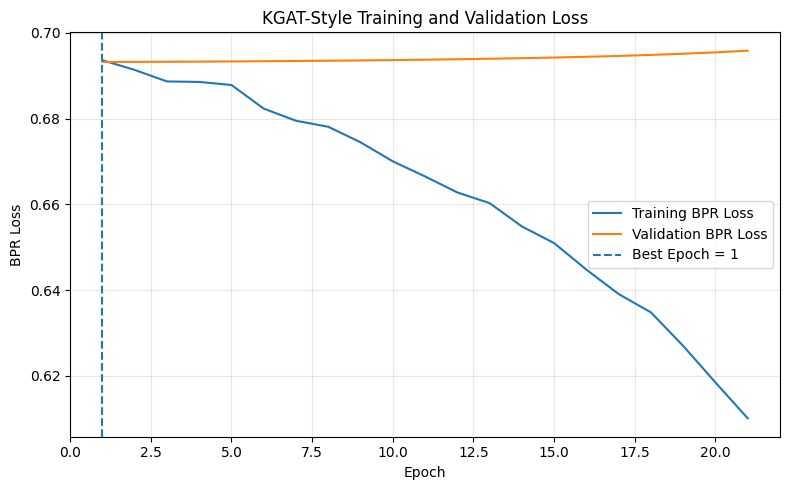

In [100]:
# ============================================================
# STEP 9J - KGAT training / validation curve
# ============================================================

import matplotlib.pyplot as plt


epochs_ran = range(
    1,
    len(kgat_train_losses) + 1
)


plt.figure(
    figsize=(8, 5)
)


plt.plot(
    epochs_ran,
    kgat_train_losses,
    label="Training BPR Loss"
)


plt.plot(
    epochs_ran,
    kgat_val_losses,
    label="Validation BPR Loss"
)


plt.axvline(
    best_kgat_epoch,
    linestyle="--",
    label=(
        f"Best Epoch = "
        f"{best_kgat_epoch}"
    )
)


plt.xlabel("Epoch")

plt.ylabel("BPR Loss")

plt.title(
    "KGAT-Style Training and Validation Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [101]:
# ============================================================
# STEP 9K - Full-ranking validation for KGAT-style model
# ============================================================

kgat_model.eval()

with torch.no_grad():

    Z_kgat = kgat_model.encode(
        kgat_edge_index_device,
        kgat_edge_type_device
    )


kgat_hit5 = []
kgat_hit10 = []

kgat_ndcg5 = []
kgat_ndcg10 = []

kgat_rr = []


for _, learner in learners_df.iterrows():

    lid = learner["Learner ID"]

    validation_course = learner[
        "Validation Course"
    ]


    # --------------------------------------------------------
    # SAME validation candidate pool as every other model
    # --------------------------------------------------------

    pool = validation_candidate_pool(
        lid
    )

    course_ids = list(
        pool["Course ID"]
    )


    learner_idx = node_to_idx[
        lid
    ]


    course_indices = torch.tensor(
        [
            node_to_idx[cid]
            for cid in course_ids
        ],
        dtype=torch.long,
        device=device
    )


    # --------------------------------------------------------
    # KGAT recommendation scores
    # --------------------------------------------------------

    learner_vector = (
        Z_kgat[
            learner_idx
        ]
    )


    scores = (
        Z_kgat[
            course_indices
        ]
        *
        learner_vector
    ).sum(dim=1)


    order = torch.argsort(
        scores,
        descending=True,
        stable=True
    ).cpu().numpy()


    ranked = [
        course_ids[i]
        for i in order
    ]


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    kgat_hit5.append(
        hit_at_k_single(
            ranked,
            validation_course,
            5
        )
    )

    kgat_hit10.append(
        hit_at_k_single(
            ranked,
            validation_course,
            10
        )
    )

    kgat_ndcg5.append(
        ndcg_at_k_single(
            ranked,
            validation_course,
            5
        )
    )

    kgat_ndcg10.append(
        ndcg_at_k_single(
            ranked,
            validation_course,
            10
        )
    )

    kgat_rr.append(
        reciprocal_rank(
            ranked,
            validation_course
        )
    )


kgat_validation_result = pd.DataFrame([
    {
        "Model":
            "KGAT-Style",

        "Hit@5":
            np.mean(kgat_hit5),

        "Hit@10":
            np.mean(kgat_hit10),

        "NDCG@5":
            np.mean(kgat_ndcg5),

        "NDCG@10":
            np.mean(kgat_ndcg10),

        "MRR":
            np.mean(kgat_rr)
    }
])


kgat_validation_result

,Model,Hit@5,Hit@10,NDCG@5,NDCG@10,MRR
0,KGAT-Style,0.02,0.055,0.015655,0.026976,0.031668


In [102]:
# ============================================================
# STEP 9L - Add KGAT-style baseline to master table
# ============================================================

master_validation_with_kgat = pd.concat(
    [
        master_validation_comparison,
        kgat_validation_result
    ],
    ignore_index=True
)


master_validation_with_kgat = (
    master_validation_with_kgat
    .drop_duplicates(
        subset=["Model"],
        keep="last"
    )
    .sort_values(
        "NDCG@10",
        ascending=False
    )
    .reset_index(drop=True)
)


master_validation_with_kgat

,Model,Hit@5,Hit@10,NDCG@5,NDCG@10,MRR
0,SBERT Content-Only,0.070,0.135,0.053463,0.074187,0.069222
1,Residual GraphSAGE + Skill-Overlap,0.055,0.085,0.030198,0.039254,0.039349
2,Residual Semantic GraphSAGE + BPR,0.045,0.080,0.023175,0.034653,0.035522
3,KGAT-Style,0.020,0.055,0.015655,0.026976,0.031668
4,Semantic GraphSAGE + BPR,0.030,0.060,0.016896,0.026334,0.028938
5,Target-Skill Overlap,0.035,0.060,0.016896,0.025249,0.026416
6,Random,0.025,0.050,0.015803,0.024054,0.030107
7,Semantic GraphSAGE + BCE,0.015,0.045,0.011309,0.021220,0.028770
8,LightGCN,0.020,0.045,0.011241,0.018970,0.023330
9,Rating-Based,0.005,0.010,0.001934,0.003715,0.016077


In [103]:
# ============================================================
# STEP 10A - Train residual GraphSAGE for one random seed
# ============================================================

import copy
import random
import numpy as np
import torch


def train_residual_for_seed(seed):

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


    # --------------------------------------------------------
    # Fresh model
    # --------------------------------------------------------

    model_seed = ResidualSemanticGraphSAGE(
        input_dim=x_semantic.shape[1],
        semantic_dim=384,
        hidden_dim=128,
        dropout=0.3
    ).to(device)


    optimizer_seed = torch.optim.Adam(
        model_seed.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )


    MAX_EPOCHS = 300
    PATIENCE = 30

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0

    epochs_without_improvement = 0


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    for epoch in range(
        1,
        MAX_EPOCHS + 1
    ):

        model_seed.train()

        optimizer_seed.zero_grad()


        z = model_seed.encode(
            x_device,
            edge_index_device
        )


        positive_scores = (
            model_seed.score(
                z,
                bpr_learner_idx,
                bpr_positive_idx
            )
        )


        negative_scores = (
            model_seed.score(
                z,
                bpr_learner_idx,
                bpr_negative_idx
            )
        )


        loss = bpr_loss(
            positive_scores,
            negative_scores
        )


        loss.backward()

        optimizer_seed.step()


        # ====================================================
        # Validation
        # ====================================================

        model_seed.eval()


        with torch.no_grad():

            z_val = model_seed.encode(
                x_device,
                edge_index_device
            )


            val_positive_scores = (
                model_seed.score(
                    z_val,
                    val_bpr_learner_idx,
                    val_bpr_positive_idx
                )
            )


            val_negative_scores = (
                model_seed.score(
                    z_val,
                    val_bpr_learner_idx,
                    val_bpr_negative_idx
                )
            )


            val_loss = bpr_loss(
                val_positive_scores,
                val_negative_scores
            ).item()


        # ====================================================
        # Early stopping
        # ====================================================

        if val_loss < best_val_loss - 1e-5:

            best_val_loss = val_loss

            best_epoch = epoch

            best_state = copy.deepcopy(
                model_seed.state_dict()
            )

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1


        if (
            epochs_without_improvement
            >= PATIENCE
        ):
            break


    # --------------------------------------------------------
    # Restore best model
    # --------------------------------------------------------

    model_seed.load_state_dict(
        best_state
    )

    model_seed.eval()


    with torch.no_grad():

        embeddings = model_seed.encode(
            x_device,
            edge_index_device
        )


    return (
        model_seed,
        embeddings,
        best_epoch,
        best_val_loss
    )

In [104]:
# ============================================================
# STEP 10B - Evaluate fixed GNN + Skill hybrid
# ============================================================

def evaluate_hybrid_validation(
    embeddings,
    alpha=0.9
):

    hit5 = []
    hit10 = []

    ndcg5 = []
    ndcg10 = []

    reciprocal_ranks = []


    for _, learner in learners_df.iterrows():

        lid = learner["Learner ID"]

        validation_course = learner[
            "Validation Course"
        ]

        target_skills = set(
            learner["Target Skills"]
        )


        pool = validation_candidate_pool(
            lid
        )


        course_ids = list(
            pool["Course ID"]
        )


        course_indices = torch.tensor(
            [
                node_to_idx[cid]
                for cid in course_ids
            ],
            dtype=torch.long,
            device=device
        )


        learner_idx = node_to_idx[
            lid
        ]


        # ====================================================
        # GNN scores
        # ====================================================

        learner_gnn = embeddings[
            learner_idx
        ]


        gnn_scores = (
            embeddings[
                course_indices
            ]
            *
            learner_gnn
        ).sum(dim=1)


        gnn_scores = minmax_normalize(
            gnn_scores
        )


        # ====================================================
        # Skill-overlap scores
        # ====================================================

        overlap_values = []

        for _, course_row in pool.iterrows():

            overlap_values.append(
                float(
                    len(
                        set(
                            course_row[
                                "Skills List"
                            ]
                        )
                        &
                        target_skills
                    )
                )
            )


        rating_values = pd.to_numeric(
            pool["Course Rating"],
            errors="coerce"
        )


        rating_values = (
            rating_values
            .fillna(
                rating_values.mean()
            )
            .values
        )


        skill_scores = torch.tensor(
            overlap_values,
            dtype=torch.float32,
            device=device
        )


        rating_scores = torch.tensor(
            rating_values,
            dtype=torch.float32,
            device=device
        )


        skill_scores = (
            skill_scores
            +
            1e-6 * rating_scores
        )


        skill_scores = minmax_normalize(
            skill_scores
        )


        # ====================================================
        # FIXED hybrid alpha
        # ====================================================

        hybrid_scores = (
            alpha * gnn_scores
            +
            (1.0 - alpha)
            * skill_scores
        )


        order = torch.argsort(
            hybrid_scores,
            descending=True,
            stable=True
        ).cpu().numpy()


        ranked = [
            course_ids[i]
            for i in order
        ]


        hit5.append(
            hit_at_k_single(
                ranked,
                validation_course,
                5
            )
        )

        hit10.append(
            hit_at_k_single(
                ranked,
                validation_course,
                10
            )
        )

        ndcg5.append(
            ndcg_at_k_single(
                ranked,
                validation_course,
                5
            )
        )

        ndcg10.append(
            ndcg_at_k_single(
                ranked,
                validation_course,
                10
            )
        )

        reciprocal_ranks.append(
            reciprocal_rank(
                ranked,
                validation_course
            )
        )


    return {
        "Hit@5": np.mean(hit5),
        "Hit@10": np.mean(hit10),
        "NDCG@5": np.mean(ndcg5),
        "NDCG@10": np.mean(ndcg10),
        "MRR": np.mean(
            reciprocal_ranks
        )
    }

In [105]:
# ============================================================
# STEP 10C - Multiple-seed robustness experiment
# ============================================================

SEEDS = [
    42,
    7,
    99,
    123,
    2026
]


multi_seed_results = []

seed_models = {}


for seed in SEEDS:

    print(
        f"\n===== SEED {seed} ====="
    )


    (
        model_seed,
        embeddings_seed,
        best_epoch_seed,
        best_val_loss_seed
    ) = train_residual_for_seed(
        seed
    )


    metrics = evaluate_hybrid_validation(
        embeddings_seed,
        alpha=BEST_SKILL_GNN_ALPHA
    )


    multi_seed_results.append({
        "Seed": seed,
        "Best Epoch":
            best_epoch_seed,

        "Val BPR Loss":
            best_val_loss_seed,

        **metrics
    })


    # Save state for later FINAL test evaluation
    seed_models[seed] = copy.deepcopy(
        model_seed.state_dict()
    )


    print(
        "Best epoch:",
        best_epoch_seed
    )

    print(
        "NDCG@10:",
        round(
            metrics["NDCG@10"],
            4
        )
    )


multi_seed_df = pd.DataFrame(
    multi_seed_results
)


multi_seed_df


===== SEED 42 =====
Best epoch: 31
NDCG@10: 0.0393

===== SEED 7 =====
Best epoch: 34
NDCG@10: 0.0414

===== SEED 99 =====
Best epoch: 31
NDCG@10: 0.0446

===== SEED 123 =====
Best epoch: 33
NDCG@10: 0.0444

===== SEED 2026 =====
Best epoch: 35
NDCG@10: 0.0307


,Seed,Best Epoch,Val BPR Loss,Hit@5,Hit@10,NDCG@5,NDCG@10,MRR
0,42,31,0.663406,0.055,0.085,0.030198,0.039254,0.039349
1,7,34,0.665823,0.055,0.080,0.033264,0.041414,0.043708
2,99,31,0.665817,0.055,0.085,0.034831,0.044648,0.046074
3,123,33,0.665156,0.050,0.090,0.031111,0.044375,0.044053
4,2026,35,0.666796,0.035,0.065,0.021271,0.030721,0.035303


In [106]:
# ============================================================
# STEP 10D - Mean ± standard deviation across seeds
# ============================================================

METRICS = [
    "Hit@5",
    "Hit@10",
    "NDCG@5",
    "NDCG@10",
    "MRR"
]


summary_rows = []


for metric in METRICS:

    values = multi_seed_df[
        metric
    ]


    summary_rows.append({
        "Metric": metric,

        "Mean":
            values.mean(),

        "Std":
            values.std(ddof=1),

        "Mean ± Std":
            (
                f"{values.mean():.4f} "
                f"± "
                f"{values.std(ddof=1):.4f}"
            )
    })


multi_seed_summary = pd.DataFrame(
    summary_rows
)


multi_seed_summary

,Metric,Mean,Std,Mean ± Std
0,Hit@5,0.050000,0.008660,0.0500 ± 0.0087
1,Hit@10,0.081000,0.009618,0.0810 ± 0.0096
2,NDCG@5,0.030135,0.005277,0.0301 ± 0.0053
3,NDCG@10,0.040082,0.005687,0.0401 ± 0.0057
4,MRR,0.041697,0.004334,0.0417 ± 0.0043


In [107]:
# ============================================================
# STEP 11A - Final TEST candidate pool
# ============================================================

def test_candidate_pool(lid):

    learner = learners_df[
        learners_df["Learner ID"] == lid
    ].iloc[0]

    domain = learner[
        "Preferred Domain"
    ]

    level = learner[
        "Current Level Score"
    ]

    train_courses = set(
        learner[
            "Train Completed Courses"
        ]
    )

    validation_course = learner[
        "Validation Course"
    ]

    test_course = learner[
        "Test Course"
    ]


    # --------------------------------------------------------
    # Same eligibility rule used for validation
    # --------------------------------------------------------

    pool = df_clean[
        (df_clean["Assigned Domain"] == domain)
        &
        (df_clean["Difficulty Score"] > 0)
        &
        (df_clean["Difficulty Score"] <= level)
    ].copy()


    # --------------------------------------------------------
    # Exclude already-known training interactions
    # and the validation interaction.
    #
    # KEEP test_course because this is what we must retrieve.
    # --------------------------------------------------------

    excluded = (
        train_courses
        |
        {validation_course}
    )


    pool = pool[
        ~pool["Course ID"].isin(
            excluded
        )
    ]


    # Test positive MUST be in candidate set
    assert (
        test_course
        in set(pool["Course ID"])
    )


    return pool

In [108]:
# ============================================================
# Verify final test candidate pools
# ============================================================

test_candidate_sizes = []


for lid in learners_df["Learner ID"]:

    pool = test_candidate_pool(
        lid
    )

    test_candidate_sizes.append(
        len(pool)
    )


print(
    "Test learners:",
    len(test_candidate_sizes)
)

print(
    "Average candidate pool:",
    round(
        np.mean(test_candidate_sizes),
        2
    )
)

print(
    "Minimum candidate pool:",
    min(test_candidate_sizes)
)

print(
    "Maximum candidate pool:",
    max(test_candidate_sizes)
)

Test learners: 200
Average candidate pool: 338.96
Minimum candidate pool: 20
Maximum candidate pool: 772


In [109]:
# ============================================================
# STEP 11B - FINAL TEST evaluation across 5 seeds
# ============================================================

FINAL_ALPHA = BEST_SKILL_GNN_ALPHA

assert FINAL_ALPHA == 0.9


test_seed_results = []


for seed in SEEDS:

    print(
        f"\n===== TEST SEED {seed} ====="
    )


    # --------------------------------------------------------
    # Recreate same architecture
    # --------------------------------------------------------

    test_model = ResidualSemanticGraphSAGE(
        input_dim=x_semantic.shape[1],
        semantic_dim=384,
        hidden_dim=128,
        dropout=0.3
    ).to(device)


    # --------------------------------------------------------
    # Load already-trained validation-selected model
    # for this seed.
    #
    # NO retraining on test data.
    # --------------------------------------------------------

    test_model.load_state_dict(
        seed_models[seed]
    )

    test_model.eval()


    with torch.no_grad():

        test_embeddings = test_model.encode(
            x_device,
            edge_index_device
        )


    hit5 = []
    hit10 = []

    ndcg5 = []
    ndcg10 = []

    reciprocal_ranks = []


    for _, learner in learners_df.iterrows():

        lid = learner[
            "Learner ID"
        ]

        test_course = learner[
            "Test Course"
        ]

        target_skills = set(
            learner[
                "Target Skills"
            ]
        )


        pool = test_candidate_pool(
            lid
        )

        course_ids = list(
            pool["Course ID"]
        )


        course_indices = torch.tensor(
            [
                node_to_idx[cid]
                for cid in course_ids
            ],
            dtype=torch.long,
            device=device
        )


        learner_idx = node_to_idx[
            lid
        ]


        # ====================================================
        # 1. Residual GraphSAGE score
        # ====================================================

        learner_gnn = (
            test_embeddings[
                learner_idx
            ]
        )


        gnn_scores = (
            test_embeddings[
                course_indices
            ]
            *
            learner_gnn
        ).sum(dim=1)


        gnn_scores = minmax_normalize(
            gnn_scores
        )


        # ====================================================
        # 2. Target-Skill Overlap score
        # ====================================================

        overlap_values = []

        for _, course_row in pool.iterrows():

            overlap_values.append(
                float(
                    len(
                        set(
                            course_row[
                                "Skills List"
                            ]
                        )
                        &
                        target_skills
                    )
                )
            )


        rating_values = pd.to_numeric(
            pool["Course Rating"],
            errors="coerce"
        )


        rating_values = (
            rating_values
            .fillna(
                rating_values.mean()
            )
            .values
        )


        skill_scores = torch.tensor(
            overlap_values,
            dtype=torch.float32,
            device=device
        )


        rating_scores = torch.tensor(
            rating_values,
            dtype=torch.float32,
            device=device
        )


        skill_scores = (
            skill_scores
            +
            1e-6 * rating_scores
        )


        skill_scores = minmax_normalize(
            skill_scores
        )


        # ====================================================
        # 3. FROZEN hybrid alpha = 0.9
        # ====================================================

        hybrid_scores = (
            FINAL_ALPHA
            * gnn_scores
            +
            (1.0 - FINAL_ALPHA)
            * skill_scores
        )


        order = torch.argsort(
            hybrid_scores,
            descending=True,
            stable=True
        ).cpu().numpy()


        ranked = [
            course_ids[i]
            for i in order
        ]


        # ====================================================
        # Ranking metrics
        # ====================================================

        hit5.append(
            hit_at_k_single(
                ranked,
                test_course,
                5
            )
        )

        hit10.append(
            hit_at_k_single(
                ranked,
                test_course,
                10
            )
        )


        ndcg5.append(
            ndcg_at_k_single(
                ranked,
                test_course,
                5
            )
        )

        ndcg10.append(
            ndcg_at_k_single(
                ranked,
                test_course,
                10
            )
        )


        reciprocal_ranks.append(
            reciprocal_rank(
                ranked,
                test_course
            )
        )


    test_seed_results.append({
        "Seed": seed,

        "Hit@5":
            np.mean(hit5),

        "Hit@10":
            np.mean(hit10),

        "NDCG@5":
            np.mean(ndcg5),

        "NDCG@10":
            np.mean(ndcg10),

        "MRR":
            np.mean(
                reciprocal_ranks
            )
    })


    print(
        "NDCG@10:",
        round(
            test_seed_results[-1][
                "NDCG@10"
            ],
            4
        )
    )


test_multi_seed_df = pd.DataFrame(
    test_seed_results
)


test_multi_seed_df


===== TEST SEED 42 =====
NDCG@10: 0.0393

===== TEST SEED 7 =====
NDCG@10: 0.0428

===== TEST SEED 99 =====
NDCG@10: 0.0443

===== TEST SEED 123 =====
NDCG@10: 0.0454

===== TEST SEED 2026 =====
NDCG@10: 0.0398


,Seed,Hit@5,Hit@10,NDCG@5,NDCG@10,MRR
0,42,0.035,0.065,0.029653,0.039278,0.046949
1,7,0.040,0.075,0.031588,0.042832,0.047584
2,99,0.045,0.080,0.033522,0.044334,0.047804
3,123,0.045,0.080,0.034088,0.045422,0.049038
4,2026,0.040,0.070,0.030089,0.039803,0.045119


In [110]:
# ============================================================
# STEP 11C - FINAL TEST mean ± standard deviation
# ============================================================

test_summary_rows = []


for metric in METRICS:

    values = test_multi_seed_df[
        metric
    ]


    test_summary_rows.append({

        "Metric": metric,

        "Mean":
            values.mean(),

        "Std":
            values.std(
                ddof=1
            ),

        "Mean ± Std":
            (
                f"{values.mean():.4f} "
                f"± "
                f"{values.std(ddof=1):.4f}"
            )
    })


final_test_summary = pd.DataFrame(
    test_summary_rows
)


final_test_summary

,Metric,Mean,Std,Mean ± Std
0,Hit@5,0.041000,0.004183,0.0410 ± 0.0042
1,Hit@10,0.074000,0.006519,0.0740 ± 0.0065
2,NDCG@5,0.031788,0.001986,0.0318 ± 0.0020
3,NDCG@10,0.042334,0.002717,0.0423 ± 0.0027
4,MRR,0.047299,0.001435,0.0473 ± 0.0014


In [111]:
# ============================================================
# STEP 11D - FINAL TEST evaluation of frozen baselines
# ============================================================

test_baseline_methods = {
    "Random":
        validation_random_ranking,

    "Rating-Based":
        validation_rating_ranking,

    "Target-Skill Overlap":
        validation_skill_overlap_ranking,

    "SBERT Content-Only":
        validation_sbert_ranking
}


test_baseline_results = []


for method_name, ranking_function in (
    test_baseline_methods.items()
):

    hit5 = []
    hit10 = []

    ndcg5 = []
    ndcg10 = []

    reciprocal_ranks = []


    for _, learner in learners_df.iterrows():

        lid = learner[
            "Learner ID"
        ]

        test_course = learner[
            "Test Course"
        ]


        # ----------------------------------------------------
        # EXACT same final test candidate pool
        # ----------------------------------------------------

        pool = test_candidate_pool(
            lid
        )


        # ----------------------------------------------------
        # Frozen baseline ranking
        # ----------------------------------------------------

        ranked = ranking_function(
            lid,
            pool
        )


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        hit5.append(
            hit_at_k_single(
                ranked,
                test_course,
                5
            )
        )

        hit10.append(
            hit_at_k_single(
                ranked,
                test_course,
                10
            )
        )

        ndcg5.append(
            ndcg_at_k_single(
                ranked,
                test_course,
                5
            )
        )

        ndcg10.append(
            ndcg_at_k_single(
                ranked,
                test_course,
                10
            )
        )

        reciprocal_ranks.append(
            reciprocal_rank(
                ranked,
                test_course
            )
        )


    test_baseline_results.append({

        "Model":
            method_name,

        "Hit@5":
            np.mean(hit5),

        "Hit@10":
            np.mean(hit10),

        "NDCG@5":
            np.mean(ndcg5),

        "NDCG@10":
            np.mean(ndcg10),

        "MRR":
            np.mean(
                reciprocal_ranks
            )
    })


test_baselines_df = pd.DataFrame(
    test_baseline_results
)


test_baselines_df

,Model,Hit@5,Hit@10,NDCG@5,NDCG@10,MRR
0,Random,0.005,0.040,0.002500,0.013570,0.019737
1,Rating-Based,0.040,0.050,0.021857,0.025215,0.028705
2,Target-Skill Overlap,0.015,0.025,0.008869,0.012316,0.023062
3,SBERT Content-Only,0.050,0.075,0.027858,0.035923,0.037506


In [112]:
# ============================================================
# STEP 11E - FINAL TEST comparison table
# ============================================================

hybrid_test_mean = {
    "Model":
        "Residual GraphSAGE + Skill Hybrid",

    "Hit@5":
        test_multi_seed_df[
            "Hit@5"
        ].mean(),

    "Hit@10":
        test_multi_seed_df[
            "Hit@10"
        ].mean(),

    "NDCG@5":
        test_multi_seed_df[
            "NDCG@5"
        ].mean(),

    "NDCG@10":
        test_multi_seed_df[
            "NDCG@10"
        ].mean(),

    "MRR":
        test_multi_seed_df[
            "MRR"
        ].mean()
}


final_test_comparison = pd.concat(
    [
        test_baselines_df,

        pd.DataFrame(
            [hybrid_test_mean]
        )
    ],
    ignore_index=True
)


final_test_comparison = (
    final_test_comparison
    .sort_values(
        "NDCG@10",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


final_test_comparison

,Model,Hit@5,Hit@10,NDCG@5,NDCG@10,MRR
0,Residual GraphSAGE + Skill Hybrid,0.041,0.074,0.031788,0.042334,0.047299
1,SBERT Content-Only,0.050,0.075,0.027858,0.035923,0.037506
2,Rating-Based,0.040,0.050,0.021857,0.025215,0.028705
3,Random,0.005,0.040,0.002500,0.013570,0.019737
4,Target-Skill Overlap,0.015,0.025,0.008869,0.012316,0.023062


In [113]:
# ============================================================
# TEST: LightGCN and KGAT-Style
# ============================================================

graph_baseline_test_results = []


# ============================================================
# 1. LightGCN
# ============================================================

lightgcn_model.eval()

with torch.no_grad():

    Z_lightgcn_test = lightgcn_model.encode(
        light_edge_index_device
    )


light_hit5 = []
light_hit10 = []

light_ndcg5 = []
light_ndcg10 = []

light_rr = []


for _, learner in learners_df.iterrows():

    lid = learner["Learner ID"]

    test_course = learner[
        "Test Course"
    ]


    # Same final test pool
    pool = test_candidate_pool(
        lid
    )

    course_ids = list(
        pool["Course ID"]
    )


    learner_idx = (
        lightgcn_learner_to_idx[
            lid
        ]
    )


    course_indices = torch.tensor(
        [
            lightgcn_course_to_idx[
                cid
            ]
            for cid in course_ids
        ],
        dtype=torch.long,
        device=device
    )


    learner_vector = (
        Z_lightgcn_test[
            learner_idx
        ]
    )


    scores = (
        Z_lightgcn_test[
            course_indices
        ]
        *
        learner_vector
    ).sum(dim=1)


    order = torch.argsort(
        scores,
        descending=True,
        stable=True
    ).cpu().numpy()


    ranked = [
        course_ids[i]
        for i in order
    ]


    light_hit5.append(
        hit_at_k_single(
            ranked,
            test_course,
            5
        )
    )

    light_hit10.append(
        hit_at_k_single(
            ranked,
            test_course,
            10
        )
    )

    light_ndcg5.append(
        ndcg_at_k_single(
            ranked,
            test_course,
            5
        )
    )

    light_ndcg10.append(
        ndcg_at_k_single(
            ranked,
            test_course,
            10
        )
    )

    light_rr.append(
        reciprocal_rank(
            ranked,
            test_course
        )
    )


graph_baseline_test_results.append({

    "Model":
        "LightGCN",

    "Hit@5":
        np.mean(light_hit5),

    "Hit@10":
        np.mean(light_hit10),

    "NDCG@5":
        np.mean(light_ndcg5),

    "NDCG@10":
        np.mean(light_ndcg10),

    "MRR":
        np.mean(light_rr)
})


# ============================================================
# 2. KGAT-Style
# ============================================================

kgat_model.eval()

with torch.no_grad():

    Z_kgat_test = kgat_model.encode(
        kgat_edge_index_device,
        kgat_edge_type_device
    )


kgat_hit5 = []
kgat_hit10 = []

kgat_ndcg5 = []
kgat_ndcg10 = []

kgat_rr = []


for _, learner in learners_df.iterrows():

    lid = learner[
        "Learner ID"
    ]

    test_course = learner[
        "Test Course"
    ]


    # Same final test pool
    pool = test_candidate_pool(
        lid
    )

    course_ids = list(
        pool["Course ID"]
    )


    learner_idx = node_to_idx[
        lid
    ]


    course_indices = torch.tensor(
        [
            node_to_idx[cid]
            for cid in course_ids
        ],
        dtype=torch.long,
        device=device
    )


    learner_vector = (
        Z_kgat_test[
            learner_idx
        ]
    )


    scores = (
        Z_kgat_test[
            course_indices
        ]
        *
        learner_vector
    ).sum(dim=1)


    order = torch.argsort(
        scores,
        descending=True,
        stable=True
    ).cpu().numpy()


    ranked = [
        course_ids[i]
        for i in order
    ]


    kgat_hit5.append(
        hit_at_k_single(
            ranked,
            test_course,
            5
        )
    )

    kgat_hit10.append(
        hit_at_k_single(
            ranked,
            test_course,
            10
        )
    )

    kgat_ndcg5.append(
        ndcg_at_k_single(
            ranked,
            test_course,
            5
        )
    )

    kgat_ndcg10.append(
        ndcg_at_k_single(
            ranked,
            test_course,
            10
        )
    )

    kgat_rr.append(
        reciprocal_rank(
            ranked,
            test_course
        )
    )


graph_baseline_test_results.append({

    "Model":
        "KGAT-Style",

    "Hit@5":
        np.mean(kgat_hit5),

    "Hit@10":
        np.mean(kgat_hit10),

    "NDCG@5":
        np.mean(kgat_ndcg5),

    "NDCG@10":
        np.mean(kgat_ndcg10),

    "MRR":
        np.mean(kgat_rr)
})


graph_baseline_test_df = pd.DataFrame(
    graph_baseline_test_results
)


graph_baseline_test_df

,Model,Hit@5,Hit@10,NDCG@5,NDCG@10,MRR
0,LightGCN,0.02,0.04,0.009396,0.015734,0.021032
1,KGAT-Style,0.05,0.08,0.024070,0.033754,0.032147


In [114]:
# ============================================================
#  FINAL TEST comparison
# ============================================================

final_test_comparison_complete = pd.concat(
    [
        final_test_comparison,
        graph_baseline_test_df
    ],
    ignore_index=True
)


final_test_comparison_complete = (
    final_test_comparison_complete
    .drop_duplicates(
        subset=["Model"],
        keep="last"
    )
    .sort_values(
        "NDCG@10",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


final_test_comparison_complete

,Model,Hit@5,Hit@10,NDCG@5,NDCG@10,MRR
0,Residual GraphSAGE + Skill Hybrid,0.041,0.074,0.031788,0.042334,0.047299
1,SBERT Content-Only,0.050,0.075,0.027858,0.035923,0.037506
2,KGAT-Style,0.050,0.080,0.024070,0.033754,0.032147
3,Rating-Based,0.040,0.050,0.021857,0.025215,0.028705
4,LightGCN,0.020,0.040,0.009396,0.015734,0.021032
5,Random,0.005,0.040,0.002500,0.013570,0.019737
6,Target-Skill Overlap,0.015,0.025,0.008869,0.012316,0.023062


In [115]:
# Multi-seed representation ensemble for downstream learning-path generation
# The five already-trained residual GraphSAGE models are combined only to obtain a more stable downstream course ranking for learning-path construction.


ensemble_embeddings = []

for seed in SEEDS:

    model_seed = ResidualSemanticGraphSAGE(
        input_dim=x_semantic.shape[1],
        semantic_dim=384,
        hidden_dim=128,
        dropout=0.3
    ).to(device)

    model_seed.load_state_dict(
        seed_models[seed]
    )

    model_seed.eval()

    with torch.no_grad():

        z_seed = model_seed.encode(
            x_device,
            edge_index_device
        )

    ensemble_embeddings.append(
        z_seed
    )


Z_final = torch.stack(
    ensemble_embeddings,
    dim=0
).mean(dim=0)


print(
    "Final ensemble embeddings:",
    Z_final.shape
)

Final ensemble embeddings: torch.Size([9872, 384])


In [116]:
# ============================================================
# Final frozen hybrid recommender
# ============================================================

FINAL_ALPHA = 0.9


def final_hybrid_ranking(lid):

    learner = learners_df[
        learners_df["Learner ID"] == lid
    ].iloc[0]

    target_skills = set(
        learner["Target Skills"]
    )

    completed_courses = set(
        learner["Completed Courses"]
    )

    learner_domain = learner[
        "Preferred Domain"
    ]

    learner_level = int(
        learner["Current Level Score"]
    )

    # For next-course recommendation we allow
    # the learner's current level and one level above.
    max_allowed_level = min(
        learner_level + 1,
        3
    )


    # --------------------------------------------------------
    # Candidate courses
    # --------------------------------------------------------

    pool = df_clean[
        (df_clean["Assigned Domain"] == learner_domain)
        &
        (df_clean["Difficulty Score"] > 0)
        &
        (
            df_clean["Difficulty Score"]
            <= max_allowed_level
        )
        &
        (
            ~df_clean["Course ID"]
            .isin(completed_courses)
        )
    ].copy()


    course_ids = list(
        pool["Course ID"]
    )


    course_indices = torch.tensor(
        [
            node_to_idx[cid]
            for cid in course_ids
        ],
        dtype=torch.long,
        device=device
    )


    learner_idx = node_to_idx[
        lid
    ]


    # ========================================================
    # 1. Ensemble residual GraphSAGE score
    # ========================================================

    learner_vector = Z_final[
        learner_idx
    ]


    gnn_scores = (
        Z_final[
            course_indices
        ]
        *
        learner_vector
    ).sum(dim=1)


    gnn_scores = minmax_normalize(
        gnn_scores
    )


    # ========================================================
    # 2. Target-Skill Overlap
    # ========================================================

    overlap_values = []

    for _, course_row in pool.iterrows():

        overlap_values.append(
            float(
                len(
                    set(
                        course_row[
                            "Skills List"
                        ]
                    )
                    &
                    target_skills
                )
            )
        )


    rating_values = pd.to_numeric(
        pool["Course Rating"],
        errors="coerce"
    )

    rating_values = (
        rating_values
        .fillna(
            rating_values.mean()
        )
        .values
    )


    skill_scores = torch.tensor(
        overlap_values,
        dtype=torch.float32,
        device=device
    )

    rating_scores = torch.tensor(
        rating_values,
        dtype=torch.float32,
        device=device
    )


    # Tiny deterministic rating tie-break
    skill_scores = (
        skill_scores
        +
        1e-6 * rating_scores
    )


    skill_scores = minmax_normalize(
        skill_scores
    )


    # ========================================================
    # 3. Frozen hybrid score
    # ========================================================

    final_scores = (
        FINAL_ALPHA
        * gnn_scores
        +
        (1.0 - FINAL_ALPHA)
        * skill_scores
    )


    order = torch.argsort(
        final_scores,
        descending=True,
        stable=True
    ).cpu().numpy()


    return [
        course_ids[i]
        for i in order
    ]

the prerequisite-aware path builder

In [117]:
# ============================================================
# Prerequisite lookup
# ============================================================

# ------------------------------------------------------------
# 1. Build prerequisite lookup
# ------------------------------------------------------------

prereqs_of = {}

for u, v, data in G.edges(data=True):

    if data["relation"] == "prerequisite_of":

        prereqs_of.setdefault(
            v,
            set()
        ).add(u)


print(
    "Courses with prerequisite relations:",
    len(prereqs_of)
)


# ------------------------------------------------------------
# 2. Course lookup table
# ------------------------------------------------------------

cid2 = df_clean.set_index(
    "Course ID"
)


# ============================================================
# 3. Final pedagogical ordering
#
# Priority:
# 1. prerequisite constraints
# 2. lower difficulty among currently eligible courses
# 3. original recommendation order as tie-breaker
# ============================================================

def order_path_by_prerequisite_and_difficulty(path):

    if len(path) <= 1:
        return path


    path_set = set(path)

    original_position = {
        cid: i
        for i, cid in enumerate(path)
    }


    # --------------------------------------------------------
    # Build prerequisite graph only for courses in this path
    # --------------------------------------------------------

    indegree = {
        cid: 0
        for cid in path
    }

    dependents = {
        cid: []
        for cid in path
    }


    for course in path:

        for prerequisite in prereqs_of.get(
            course,
            set()
        ):

            if prerequisite in path_set:

                dependents[
                    prerequisite
                ].append(course)

                indegree[
                    course
                ] += 1


    # --------------------------------------------------------
    # Courses currently allowed to be placed
    # --------------------------------------------------------

    available = [
        cid
        for cid in path
        if indegree[cid] == 0
    ]

    ordered = []


    while available:

        # Easier courses first.
        # Original ranking breaks ties.
        available.sort(
            key=lambda cid: (
                cid2.loc[
                    cid,
                    "Difficulty Score"
                ],
                original_position[cid]
            )
        )


        current = available.pop(0)

        ordered.append(
            current
        )


        # Courses depending on current may become available
        for dependent in dependents[current]:

            indegree[
                dependent
            ] -= 1

            if indegree[dependent] == 0:

                available.append(
                    dependent
                )


    # --------------------------------------------------------
    # Defensive cycle protection
    # --------------------------------------------------------

    if len(ordered) != len(path):

        print(
            "Warning: prerequisite cycle detected; "
            "keeping original path order."
        )

        return path


    return ordered

Courses with prerequisite relations: 1786


In [118]:
# ============================================================
# Build prerequisite-aware learning path
# ============================================================

def build_learning_path(
    lid,
    max_len=6,
    topN=50
):

    # --------------------------------------------------------
    # Learner profile
    # --------------------------------------------------------

    learner = learners_df[
        learners_df["Learner ID"] == lid
    ].iloc[0]


    target_skills = set(
        learner["Target Skills"]
    )

    completed_courses = set(
        learner["Completed Courses"]
    )

    learner_level = int(
        learner["Current Level Score"]
    )

    learner_domain = learner[
        "Preferred Domain"
    ]


    # Learner can progress at most one level above
    max_allowed_level = min(
        learner_level + 1,
        3
    )


    # ========================================================
    # 1. Get FINAL frozen hybrid ranking
    # ========================================================

    ranked = final_hybrid_ranking(
        lid
    )


    # ========================================================
    # 2. Candidate recommendations
    #
    # Candidate must:
    # - not already be completed
    # - belong to preferred domain
    # - have calibrated difficulty
    # - be appropriate for learner level
    # - cover at least one target skill
    # ========================================================

    candidates = [
        cid
        for cid in ranked

        if (
            cid not in completed_courses

            and

            cid2.loc[
                cid,
                "Assigned Domain"
            ] == learner_domain

            and

            cid2.loc[
                cid,
                "Difficulty Score"
            ] > 0

            and

            cid2.loc[
                cid,
                "Difficulty Score"
            ] <= max_allowed_level

            and

            len(
                set(
                    cid2.loc[
                        cid,
                        "Skills List"
                    ]
                )
                &
                target_skills
            ) > 0
        )

    ][:topN]


    # ========================================================
    # 3. Initialize path
    # ========================================================

    path = []

    covered = set()


    # ========================================================
    # 4. Recursive prerequisite insertion
    #
    # Includes rollback:
    # if dependent course cannot be added,
    # prerequisites inserted only for it are removed.
    # ========================================================

    def add_with_prerequisites(
        course_id,
        visiting=None
    ):

        if visiting is None:
            visiting = set()


        # Already present in path
        if course_id in path:
            return True


        # Already completed by learner
        if course_id in completed_courses:
            return True


        # Cycle protection
        if course_id in visiting:
            return False


        # No capacity
        if len(path) >= max_len:
            return False


        # Remember path state before this attempt
        path_start_length = len(path)

        visiting.add(
            course_id
        )


        try:

            prerequisites = list(
                prereqs_of.get(
                    course_id,
                    set()
                )
            )


            # ------------------------------------------------
            # Sort prerequisites:
            # easier first, rating as tie-breaker
            # ------------------------------------------------

            def prerequisite_sort_key(
                prerequisite
            ):

                difficulty = cid2.loc[
                    prerequisite,
                    "Difficulty Score"
                ]

                rating = cid2.loc[
                    prerequisite,
                    "Course Rating Numeric"
                ]

                if pd.isna(rating):
                    rating = 0.0


                return (
                    difficulty,
                    -float(rating)
                )


            prerequisites.sort(
                key=prerequisite_sort_key
            )


            # =================================================
            # Add prerequisites first
            # =================================================

            for prerequisite in prerequisites:


                # Already satisfied by learner history
                if prerequisite in completed_courses:
                    continue


                # Prerequisite must exist
                if prerequisite not in cid2.index:

                    del path[
                        path_start_length:
                    ]

                    return False


                # Prerequisite must remain in same domain
                prerequisite_domain = cid2.loc[
                    prerequisite,
                    "Assigned Domain"
                ]


                if prerequisite_domain != learner_domain:

                    del path[
                        path_start_length:
                    ]

                    return False


                # Difficulty must be known and appropriate
                prerequisite_level = cid2.loc[
                    prerequisite,
                    "Difficulty Score"
                ]


                if (
                    prerequisite_level <= 0
                    or
                    prerequisite_level > max_allowed_level
                ):

                    del path[
                        path_start_length:
                    ]

                    return False


                # Enough room must remain
                if len(path) >= max_len:

                    del path[
                        path_start_length:
                    ]

                    return False


                # Recursively add prerequisite
                success = add_with_prerequisites(
                    prerequisite,
                    visiting
                )


                if not success:

                    # ----------------------------------------
                    # ROLLBACK
                    # ----------------------------------------

                    del path[
                        path_start_length:
                    ]

                    return False


            # =================================================
            # Add dependent course AFTER prerequisites
            # =================================================

            if len(path) >= max_len:

                del path[
                    path_start_length:
                ]

                return False


            if course_id not in path:

                path.append(
                    course_id
                )


            return True


        finally:

            visiting.discard(
                course_id
            )


    # ========================================================
    # 5. Construct path from hybrid recommendations
    # ========================================================

    for course_id in candidates:

        if len(path) >= max_len:
            break


        course_target_skills = (
            set(
                cid2.loc[
                    course_id,
                    "Skills List"
                ]
            )
            &
            target_skills
        )


        new_skills = (
            course_target_skills
            -
            covered
        )


        # Avoid redundant recommendation courses
        if (
            len(new_skills) == 0
            and
            len(path) >= 2
        ):

            continue


        old_length = len(path)


        success = add_with_prerequisites(
            course_id
        )


        if not success:
            continue


        # ----------------------------------------------------
        # Update skill coverage using both recommendation
        # courses and inserted prerequisites
        # ----------------------------------------------------

        newly_added_courses = path[
            old_length:
        ]


        for added_course in newly_added_courses:

            covered |= (
                set(
                    cid2.loc[
                        added_course,
                        "Skills List"
                    ]
                )
                &
                target_skills
            )


        # Stop when all targets are covered
        if (
            covered >= target_skills
            and
            len(path) >= 2
        ):

            break


    # ========================================================
    # 6. Final pedagogical ordering
    #
    # Prerequisites FIRST.
    # Among currently possible courses, easier courses first.
    # ========================================================

    path = order_path_by_prerequisite_and_difficulty(
        path
    )


    return path

In [119]:
# ============================================================
#Generate learning paths
# ============================================================

learning_paths = {
    lid: build_learning_path(
        lid
    )
    for lid in learners_df[
        "Learner ID"
    ]
}


print(
    "Generated learning paths:",
    len(learning_paths)
)


# ============================================================
# Show L1 example
# ============================================================

ex = learners_df.iloc[0]

example_lid = ex[
    "Learner ID"
]


print(
    "\nPath for",
    example_lid,
    "—",
    ex["Preferred Domain"],
    "| level:",
    ex["Current Level"]
)

print(
    "Target skills:",
    ex["Target Skills"],
    "\n"
)


for step, cid in enumerate(
    learning_paths[
        example_lid
    ],
    start=1
):

    print(
        f"{step}. "
        f"[{cid2.loc[cid, 'Difficulty Level']}] "
        f"{cid2.loc[cid, 'Course Name'][:80]}"
    )

Generated learning paths: 200

Path for L1 — Data Science | level: Beginner
Target skills: ['data visualization', 'algorithms', 'deep learning'] 

1. [Beginner] Getting Started with SAS Visual Analytics
2. [Beginner] Data Visualization and Communication with Tableau
3. [Beginner] Visual Analytics with Tableau
4. [Beginner] Applied Data Science Capstone
5. [Beginner] Introduction to Deep Learning & Neural Networks with Keras
6. [Intermediate] Digital Marketing Analytics in Practice


In [120]:
# ============================================================
# Diagnose prerequisite applicability
# ============================================================

def prerequisite_pairs_in_path(path):
    """
    Returns prerequisite-course pairs for which BOTH courses
    actually occur in the generated learning path.
    """

    positions = {
        cid: idx
        for idx, cid
        in enumerate(path)
    }

    pairs = []

    for course in path:

        for prerequisite in prereqs_of.get(
            course,
            set()
        ):

            if prerequisite in positions:

                pairs.append({
                    "Prerequisite": prerequisite,
                    "Course": course,

                    "Respected":
                        positions[prerequisite]
                        <
                        positions[course]
                })

    return pairs

In [121]:
# ============================================================
# Aggregate prerequisite diagnostics across all 200 learners
# ============================================================

paths_with_pairs = 0

total_pairs_in_paths = 0
respected_pairs = 0
violated_pairs = 0

satisfied_by_history = 0
unsatisfied_requirements = 0


for _, learner in learners_df.iterrows():

    lid = learner["Learner ID"]

    path = learning_paths[
        lid
    ]

    completed = set(
        learner["Completed Courses"]
    )


    # --------------------------------------------------------
    # Prerequisite pairs where both courses occur in path
    # --------------------------------------------------------

    pairs = prerequisite_pairs_in_path(
        path
    )


    if len(pairs) > 0:
        paths_with_pairs += 1


    total_pairs_in_paths += len(
        pairs
    )


    respected_pairs += sum(
        pair["Respected"]
        for pair in pairs
    )


    violated_pairs += sum(
        not pair["Respected"]
        for pair in pairs
    )


    # --------------------------------------------------------
    # Also verify every prerequisite requirement of every
    # course included in the path.
    #
    # A prerequisite can be satisfied either:
    # 1. earlier in the generated path
    # 2. by learner's previous completed-course history
    # --------------------------------------------------------

    positions = {
        cid: idx
        for idx, cid
        in enumerate(path)
    }


    for course in path:

        for prerequisite in prereqs_of.get(
            course,
            set()
        ):

            if prerequisite in completed:

                satisfied_by_history += 1

            elif (
                prerequisite in positions
                and
                positions[prerequisite]
                <
                positions[course]
            ):

                # Already counted above as a respected
                # in-path prerequisite pair.
                pass

            else:

                unsatisfied_requirements += 1


print(
    "Total learner paths:",
    len(learning_paths)
)

print(
    "Paths containing >=1 in-path prerequisite pair:",
    paths_with_pairs
)

print(
    "Total prerequisite pairs appearing in paths:",
    total_pairs_in_paths
)

print(
    "Respected in-path prerequisite pairs:",
    respected_pairs
)

print(
    "Violated in-path prerequisite pairs:",
    violated_pairs
)

print(
    "Prerequisite requirements already satisfied "
    "by completed history:",
    satisfied_by_history
)

print(
    "Unsatisfied prerequisite requirements:",
    unsatisfied_requirements
)


if total_pairs_in_paths > 0:

    prerequisite_respect = (
        respected_pairs
        /
        total_pairs_in_paths
    )

    print(
        "\nIn-path prerequisite respect:",
        f"{prerequisite_respect:.2%}"
    )

else:

    print(
        "\nIn-path prerequisite respect: N/A"
    )

Total learner paths: 200
Paths containing >=1 in-path prerequisite pair: 184
Total prerequisite pairs appearing in paths: 559
Respected in-path prerequisite pairs: 559
Violated in-path prerequisite pairs: 0
Prerequisite requirements already satisfied by completed history: 28
Unsatisfied prerequisite requirements: 0

In-path prerequisite respect: 100.00%


In [122]:
# ============================================================
# Inspect WHY each L1 course appears in the path
# ============================================================

lid = "L1"

learner = learners_df[
    learners_df["Learner ID"] == lid
].iloc[0]

target_skills = set(
    learner["Target Skills"]
)

path = learning_paths[lid]


for step, cid in enumerate(path, 1):

    row = cid2.loc[cid]

    course_skills = set(
        row["Skills List"]
    )

    matched_target_skills = sorted(
        course_skills
        & target_skills
    )

    prerequisite_for = [
        other_course
        for other_course in path
        if cid in prereqs_of.get(
            other_course,
            set()
        )
    ]

    print(
        "\n----------------------------------------"
    )

    print(
        "Step:",
        step
    )

    print(
        "Course ID:",
        cid
    )

    print(
        "Course:",
        row["Course Name"]
    )

    print(
        "Assigned Domain:",
        row["Assigned Domain"]
    )

    print(
        "Difficulty:",
        row["Difficulty Level"]
    )

    print(
        "Matched target skills:",
        matched_target_skills
    )

    print(
        "Prerequisite for:",
        prerequisite_for
    )


----------------------------------------
Step: 1
Course ID: C737
Course: Getting Started with SAS Visual Analytics
Assigned Domain: Data Science
Difficulty: Beginner
Matched target skills: []
Prerequisite for: ['C3288']

----------------------------------------
Step: 2
Course ID: C397
Course: Data Visualization and Communication with Tableau
Assigned Domain: Data Science
Difficulty: Beginner
Matched target skills: ['data visualization']
Prerequisite for: ['C3288']

----------------------------------------
Step: 3
Course ID: C3361
Course: Visual Analytics with Tableau
Assigned Domain: Data Science
Difficulty: Beginner
Matched target skills: ['data visualization']
Prerequisite for: ['C3288']

----------------------------------------
Step: 4
Course ID: C3396
Course: Applied Data Science Capstone
Assigned Domain: Data Science
Difficulty: Beginner
Matched target skills: ['algorithms', 'data visualization']
Prerequisite for: []

----------------------------------------
Step: 5
Course ID: C2

In [123]:
# ============================================================
# Verify domain consistency of generated paths
# ============================================================

domain_mismatches = []


for _, learner in learners_df.iterrows():

    lid = learner["Learner ID"]
    preferred_domain = learner["Preferred Domain"]

    for cid in learning_paths[lid]:

        course_domain = cid2.loc[
            cid,
            "Assigned Domain"
        ]

        if course_domain != preferred_domain:

            domain_mismatches.append({
                "Learner": lid,
                "Preferred Domain": preferred_domain,
                "Course": cid,
                "Course Domain": course_domain
            })


print(
    "Domain mismatches:",
    len(domain_mismatches)
)

if domain_mismatches:
    print(
        pd.DataFrame(
            domain_mismatches
        ).head(20)
    )

Domain mismatches: 0


In [124]:
# ============================================================
# Learning-path evaluation helpers
# ============================================================

def prerequisite_respect_score(path):

    pairs = prerequisite_pairs_in_path(
        path
    )

    if len(pairs) == 0:
        return None

    return np.mean([
        pair["Respected"]
        for pair in pairs
    ])


def difficulty_monotonicity(path):
    """
    Fraction of adjacent course transitions that do not
    decrease in difficulty.

    Example:
    1 -> 1 -> 2 -> 3 = fully monotonic
    1 -> 2 -> 1     = one violation
    """

    if len(path) <= 1:
        return 1.0


    difficulties = [
        float(
            cid2.loc[
                cid,
                "Difficulty Score"
            ]
        )
        for cid in path
    ]


    comparisons = [
        difficulties[i + 1]
        >= difficulties[i]

        for i in range(
            len(difficulties) - 1
        )
    ]


    return float(
        np.mean(comparisons)
    )


def target_skill_coverage(
    lid,
    path
):

    learner = learners_df[
        learners_df["Learner ID"] == lid
    ].iloc[0]


    targets = set(
        learner["Target Skills"]
    )


    if len(targets) == 0:
        return 1.0


    covered = set()


    for cid in path:

        covered |= (
            set(
                cid2.loc[
                    cid,
                    "Skills List"
                ]
            )
            &
            targets
        )


    return (
        len(covered)
        /
        len(targets)
    )

In [125]:
# ============================================================
# Naive ordering baseline
# ============================================================

naive_learning_paths = {}


for lid in learners_df[
    "Learner ID"
]:

    final_path = learning_paths[
        lid
    ]


    # Full frozen hybrid ranking
    ranked = final_hybrid_ranking(
        lid
    )


    rank_position = {
        cid: position
        for position, cid
        in enumerate(ranked)
    }


    # Same courses as final path.
    # Only their ordering is changed.
    naive_path = sorted(
        final_path,
        key=lambda cid:
            rank_position.get(
                cid,
                float("inf")
            )
    )


    naive_learning_paths[
        lid
    ] = naive_path

In [126]:
# ============================================================
# Final learning-path evaluation
# ============================================================

proposed_prereq_scores = []
naive_prereq_scores = []

proposed_difficulty = []
naive_difficulty = []

proposed_coverage = []
naive_coverage = []

proposed_lengths = []
naive_lengths = []


for lid in learners_df[
    "Learner ID"
]:

    proposed_path = learning_paths[
        lid
    ]

    naive_path = naive_learning_paths[
        lid
    ]


    # --------------------------------------------------------
    # Prerequisite respect
    # Only paths containing applicable prerequisite pairs
    # contribute to this percentage.
    # --------------------------------------------------------

    score = prerequisite_respect_score(
        proposed_path
    )

    if score is not None:

        proposed_prereq_scores.append(
            score
        )


    score = prerequisite_respect_score(
        naive_path
    )

    if score is not None:

        naive_prereq_scores.append(
            score
        )


    # --------------------------------------------------------
    # Difficulty monotonicity
    # --------------------------------------------------------

    proposed_difficulty.append(
        difficulty_monotonicity(
            proposed_path
        )
    )

    naive_difficulty.append(
        difficulty_monotonicity(
            naive_path
        )
    )


    # --------------------------------------------------------
    # Target-skill coverage
    # --------------------------------------------------------

    proposed_coverage.append(
        target_skill_coverage(
            lid,
            proposed_path
        )
    )

    naive_coverage.append(
        target_skill_coverage(
            lid,
            naive_path
        )
    )


    # --------------------------------------------------------
    # Path length
    # --------------------------------------------------------

    proposed_lengths.append(
        len(proposed_path)
    )

    naive_lengths.append(
        len(naive_path)
    )


# ============================================================
# Final table
# ============================================================

path_results = pd.DataFrame({

    "Metric": [
        "Prerequisite Respect",
        "Difficulty Monotonicity",
        "Target-Skill Coverage",
        "Average Path Length"
    ],

    "Prerequisite-Aware": [

        np.mean(
            proposed_prereq_scores
        ),

        np.mean(
            proposed_difficulty
        ),

        np.mean(
            proposed_coverage
        ),

        np.mean(
            proposed_lengths
        )
    ],

    "Naive Ordering": [

        np.mean(
            naive_prereq_scores
        ),

        np.mean(
            naive_difficulty
        ),

        np.mean(
            naive_coverage
        ),

        np.mean(
            naive_lengths
        )
    ]
})


path_results

,Metric,Prerequisite-Aware,Naive Ordering
0,Prerequisite Respect,1.000000,0.044384
1,Difficulty Monotonicity,1.000000,0.802167
2,Target-Skill Coverage,0.862333,0.862333
3,Average Path Length,5.630000,5.630000


In [127]:
# ============================================================
# Exact prerequisite pair counts for proposed vs naive ordering
# ============================================================

def prerequisite_pair_counts(paths):

    total_pairs = 0
    respected_pairs = 0
    violated_pairs = 0

    paths_with_pairs = 0
    paths_with_violations = 0


    for lid, path in paths.items():

        pairs = prerequisite_pairs_in_path(
            path
        )

        if len(pairs) > 0:
            paths_with_pairs += 1


        path_has_violation = False


        for pair in pairs:

            total_pairs += 1

            if pair["Respected"]:

                respected_pairs += 1

            else:

                violated_pairs += 1
                path_has_violation = True


        if path_has_violation:
            paths_with_violations += 1


    pair_level_rate = (
        respected_pairs / total_pairs
        if total_pairs > 0
        else np.nan
    )


    return {
        "Paths with prerequisite pairs":
            paths_with_pairs,

        "Total prerequisite pairs":
            total_pairs,

        "Respected pairs":
            respected_pairs,

        "Violated pairs":
            violated_pairs,

        "Paths with violations":
            paths_with_violations,

        "Pair-level prerequisite respect":
            pair_level_rate
    }


proposed_pair_stats = prerequisite_pair_counts(
    learning_paths
)

naive_pair_stats = prerequisite_pair_counts(
    naive_learning_paths
)


prerequisite_comparison = pd.DataFrame(
    [
        {
            "Method":
                "Prerequisite-Aware",
            **proposed_pair_stats
        },

        {
            "Method":
                "Naive Ordering",
            **naive_pair_stats
        }
    ]
)


prerequisite_comparison

,Method,Paths with prerequisite pairs,Total prerequisite pairs,Respected pairs,Violated pairs,Paths with violations,Pair-level prerequisite respect
0,Prerequisite-Aware,184,559,559,0,0,1.000000
1,Naive Ordering,184,559,22,537,181,0.039356


In [128]:
# ============================================================
# STEP 13A - Audit difficulty-level handling
# ============================================================

print("Difficulty label distribution:\n")

print(
    df_clean[
        "Difficulty Level"
    ].value_counts(
        dropna=False
    )
)


print(
    "\nDifficulty mapping:\n"
)

difficulty_mapping_check = (
    df_clean[
        [
            "Difficulty Level",
            "Difficulty Score"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "Difficulty Score",
            "Difficulty Level"
        ]
    )
)

display(
    difficulty_mapping_check
)


# ============================================================
# Check Not Calibrated handling
# ============================================================

not_calibrated_courses = df_clean[
    df_clean[
        "Difficulty Level"
    ] == "Not Calibrated"
]


print(
    "\nNumber of Not Calibrated courses:",
    len(not_calibrated_courses)
)


# ============================================================
# Verify that no Not Calibrated course appears
# in the final generated learning paths
# ============================================================

not_calibrated_in_paths = []


for lid, path in learning_paths.items():

    for cid in path:

        if (
            cid2.loc[
                cid,
                "Difficulty Level"
            ]
            == "Not Calibrated"
        ):

            not_calibrated_in_paths.append({
                "Learner": lid,
                "Course": cid
            })


print(
    "Not Calibrated courses in final paths:",
    len(not_calibrated_in_paths)
)


# ============================================================
# Verify final path difficulty distributions
# ============================================================

path_difficulties = []


for lid, path in learning_paths.items():

    for cid in path:

        path_difficulties.append(
            cid2.loc[
                cid,
                "Difficulty Level"
            ]
        )


print(
    "\nDifficulty labels used in final paths:\n"
)

print(
    pd.Series(
        path_difficulties
    ).value_counts()
)

Difficulty label distribution:

Difficulty Level
Beginner          1406
Advanced           991
Intermediate       823
Conversant         154
Not Calibrated      50
Name: count, dtype: int64

Difficulty mapping:



,Difficulty Level,Difficulty Score
20,Not Calibrated,0
0,Beginner,1
37,Conversant,2
3,Intermediate,2
2,Advanced,3



Number of Not Calibrated courses: 50
Not Calibrated courses in final paths: 0

Difficulty labels used in final paths:

Beginner        919
Intermediate    140
Conversant       64
Advanced          3
Name: count, dtype: int64


# Module 3: Retrieval-Grounded Template-Based Explanation Layer

In [129]:
# ============================================================
# STEP 14A-1 - Explanation layer setup
# ============================================================

!pip install -q chromadb sentence-transformers

import ast
import numpy as np
import pandas as pd
import chromadb

from sentence_transformers import SentenceTransformer


# Semantic encoder used for vector retrieval
explanation_encoder = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print(
    "Explanation encoder loaded."
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 719.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently 

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Explanation encoder loaded.


In [130]:
# ============================================================
# STEP 14A-2 - Helper functions
# ============================================================

def as_list(value):
    """
    Safely converts a value into a Python list.
    """

    if value is None:
        return []


    if isinstance(
        value,
        (list, tuple, set, np.ndarray)
    ):

        return [
            str(v).strip()
            for v in value
            if str(v).strip()
        ]


    if isinstance(value, float) and np.isnan(value):
        return []


    if isinstance(value, str):

        value = value.strip()

        if not value:
            return []


        try:

            parsed = ast.literal_eval(
                value
            )

            if isinstance(
                parsed,
                (list, tuple, set)
            ):

                return [
                    str(v).strip()
                    for v in parsed
                    if str(v).strip()
                ]

        except Exception:
            pass


        return [
            v.strip()
            for v in value.split(",")
            if v.strip()
        ]


    return [
        str(value).strip()
    ]


def shorten_text(
    text,
    max_words=60
):
    """
    Keeps course documents compact for vector retrieval.
    """

    if text is None:
        return ""


    text = str(text).strip()

    words = text.split()

    return " ".join(
        words[:max_words]
    )


def get_course_description(
    course_row
):
    """
    Prefer the cleaned/enriched summary if available.
    Otherwise use the original description.
    """

    if "desc_summary" in course_row.index:

        value = course_row[
            "desc_summary"
        ]

        if (
            value is not None
            and str(value).strip()
            and str(value).lower() != "nan"
        ):

            return str(value)


    if "Course Description" in course_row.index:

        value = course_row[
            "Course Description"
        ]

        if value is not None:

            return str(value)


    return ""

In [131]:
# ============================================================
# STEP 14A-3 - Build textual course knowledge base
# ============================================================

def course_document(
    course_id
):

    course = cid2.loc[
        course_id
    ]


    skills = as_list(
        course["Skills List"]
    )


    description = shorten_text(
        get_course_description(
            course
        ),
        max_words=60
    )


    return (
        f"Course: {course['Course Name']}. "
        f"Domain: {course['Assigned Domain']}. "
        f"Difficulty: {course['Difficulty Level']}. "
        f"Skills: {', '.join(skills[:15])}. "
        f"Description: {description}"
    )


course_ids_explanation = list(
    df_clean[
        "Course ID"
    ]
)


course_documents = [
    course_document(cid)
    for cid in course_ids_explanation
]


print(
    "Course documents:",
    len(course_documents)
)


print(
    "\nExample document:\n"
)

print(
    course_documents[0]
)

Course documents: 3424

Example document:

Course: Write A Feature Length Screenplay For Film Or Television. Domain: Arts and Humanities. Difficulty: Beginner. Skills: drama, comedy, peering, screenwriting, film, document review, dialogue, creative writing, writing, unix shells. Description: Write a Full Length Feature Film Script In this course, you will write a complete, feature-length screenplay for film or television, be it a serious drama or ro


In [132]:
# ============================================================
# STEP 14A-4 - Vector index with ChromaDB
# ============================================================

chroma_client = chromadb.Client()


COLLECTION_NAME = (
    "course_explanation_kb"
)


# ------------------------------------------------------------
# Recreate collection so rerunning the notebook does not
# produce duplicate-ID errors.
# ------------------------------------------------------------

try:

    chroma_client.delete_collection(
        COLLECTION_NAME
    )

except Exception:

    pass


explanation_collection = (
    chroma_client.create_collection(
        COLLECTION_NAME
    )
)


# ------------------------------------------------------------
# Encode course documents
# ------------------------------------------------------------

course_document_embeddings = (
    explanation_encoder.encode(
        course_documents,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
)


# ------------------------------------------------------------
# Metadata
# ------------------------------------------------------------

course_metadata = []


for cid in course_ids_explanation:

    row = cid2.loc[cid]

    course_metadata.append({

        "course_id":
            str(cid),

        "course_name":
            str(
                row["Course Name"]
            ),

        "domain":
            str(
                row["Assigned Domain"]
            ),

        "difficulty":
            str(
                row["Difficulty Level"]
            )
    })


# ------------------------------------------------------------
# Chroma limits batch sizes, so add in chunks.
# ------------------------------------------------------------

BATCH_SIZE = 500


for start in range(
    0,
    len(course_ids_explanation),
    BATCH_SIZE
):

    end = start + BATCH_SIZE


    explanation_collection.add(

        ids=[
            str(cid)
            for cid
            in course_ids_explanation[
                start:end
            ]
        ],

        documents=
            course_documents[
                start:end
            ],

        embeddings=
            course_document_embeddings[
                start:end
            ].tolist(),

        metadatas=
            course_metadata[
                start:end
            ]
    )


print(
    "Indexed courses:",
    explanation_collection.count()
)

Batches:   0%|          | 0/54 [00:00<?, ?it/s]

Indexed courses: 3424


In [133]:
# ============================================================
# STEP 14A-5 - Structured learner-course evidence
# ============================================================

def retrieve_facts(
    course_id,
    learner_id
):

    learner = learners_df[
        learners_df[
            "Learner ID"
        ] == learner_id
    ].iloc[0]


    course = cid2.loc[
        course_id
    ]


    target_skills = set(
        as_list(
            learner[
                "Target Skills"
            ]
        )
    )


    acquired_skills = set(
        as_list(
            learner[
                "Acquired Skills"
            ]
        )
    )


    course_skills = set(
        as_list(
            course[
                "Skills List"
            ]
        )
    )


    matched_target_skills = sorted(
        target_skills
        &
        course_skills
    )


    matched_acquired_skills = sorted(
        acquired_skills
        &
        course_skills
    )


    same_domain = (
        learner[
            "Preferred Domain"
        ]
        ==
        course[
            "Assigned Domain"
        ]
    )


    return {

        "learner_id":
            learner_id,

        "learner_level":
            learner[
                "Current Level"
            ],

        "learner_level_score":
            int(
                learner[
                    "Current Level Score"
                ]
            ),

        "learner_domain":
            learner[
                "Preferred Domain"
            ],

        "learning_goal":
            learner[
                "Learning Goal"
            ],

        "target_skills":
            sorted(
                target_skills
            ),

        "acquired_skills":
            sorted(
                acquired_skills
            ),

        "completed_courses":
            set(
                as_list(
                    learner[
                        "Completed Courses"
                    ]
                )
            ),

        "course_id":
            course_id,

        "course":
            course[
                "Course Name"
            ],

        "course_domain":
            course[
                "Assigned Domain"
            ],

        "course_level":
            course[
                "Difficulty Level"
            ],

        "course_level_score":
            float(
                course[
                    "Difficulty Score"
                ]
            ),

        "course_skills":
            sorted(
                course_skills
            ),

        "matched_target_skills":
            matched_target_skills,

        "matched_acquired_skills":
            matched_acquired_skills,

        "same_domain":
            bool(
                same_domain
            )
    }

In [134]:
# ============================================================
# STEP 14A-6 - Vector retrieval from ChromaDB
# ============================================================

def retrieve_vector_context(
    learner_id,
    course_id,
    top_n=3
):

    facts = retrieve_facts(
        course_id,
        learner_id
    )


    query = (
        f"Learner level: "
        f"{facts['learner_level']}. "

        f"Learner preferred domain: "
        f"{facts['learner_domain']}. "

        f"Learner goal: "
        f"{facts['learning_goal']}. "

        f"Learner target skills: "
        f"{', '.join(facts['target_skills'])}. "

        f"Recommended course: "
        f"{facts['course']}. "

        f"Course domain: "
        f"{facts['course_domain']}. "

        f"Course difficulty: "
        f"{facts['course_level']}. "

        f"Course skills: "
        f"{', '.join(facts['course_skills'])}."
    )


    query_embedding = (
        explanation_encoder.encode(
            query,
            normalize_embeddings=True
        )
    )


    # Ask for one extra because the recommended
    # course itself will often be retrieved.
    n_results = min(
        top_n + 1,
        explanation_collection.count()
    )


    results = explanation_collection.query(

        query_embeddings=[
            query_embedding.tolist()
        ],

        n_results=n_results,

        include=[
            "documents",
            "metadatas",
            "distances"
        ]
    )


    retrieved = []


    ids = results[
        "ids"
    ][0]

    documents = results[
        "documents"
    ][0]

    metadatas = results[
        "metadatas"
    ][0]

    distances = results[
        "distances"
    ][0]


    for (
        retrieved_id,
        document,
        metadata,
        distance
    ) in zip(
        ids,
        documents,
        metadatas,
        distances
    ):


        # Do not present the course itself
        # as a related retrieved course.
        if str(retrieved_id) == str(course_id):
            continue


        retrieved.append({

            "course_id":
                str(retrieved_id),

            "course_name":
                metadata[
                    "course_name"
                ],

            "domain":
                metadata[
                    "domain"
                ],

            "difficulty":
                metadata[
                    "difficulty"
                ],

            "document":
                document,

            "distance":
                float(distance)
        })


        if len(retrieved) >= top_n:
            break


    return retrieved

In [135]:
# ============================================================
# STEP 14A-7 - Build explanation evidence
# ============================================================

def build_explanation_evidence(
    course_id,
    learner_id,
    top_n=3
):

    facts = retrieve_facts(
        course_id,
        learner_id
    )


    retrieved_courses = (
        retrieve_vector_context(
            learner_id,
            course_id,
            top_n=top_n
        )
    )


    # ========================================================
    # Path evidence
    # ========================================================

    path = learning_paths.get(
        learner_id,
        []
    )


    path_positions = {
        cid: index
        for index, cid
        in enumerate(path)
    }


    if course_id in path_positions:

        position = (
            path_positions[
                course_id
            ]
            + 1
        )

    else:

        position = None


    total_steps = (
        len(path)
        if path
        else None
    )


    # ========================================================
    # Prerequisite evidence
    # ========================================================

    course_prerequisites = set(
        prereqs_of.get(
            course_id,
            set()
        )
    )


    in_path_prerequisites = [
        prerequisite
        for prerequisite
        in course_prerequisites

        if (
            prerequisite
            in path_positions

            and
            course_id
            in path_positions

            and
            path_positions[
                prerequisite
            ]
            <
            path_positions[
                course_id
            ]
        )
    ]


    completed_prerequisites = [
        prerequisite
        for prerequisite
        in course_prerequisites

        if prerequisite
        in facts[
            "completed_courses"
        ]
    ]


    prerequisite_for_in_path = [

        other_course

        for other_course
        in path

        if (
            course_id
            in prereqs_of.get(
                other_course,
                set()
            )

            and

            course_id
            in path_positions

            and

            path_positions[
                course_id
            ]
            <
            path_positions[
                other_course
            ]
        )
    ]


    # ========================================================
    # Difficulty compatibility
    # ========================================================

    max_allowed_level = min(
        facts[
            "learner_level_score"
        ] + 1,
        3
    )


    difficulty_compatible = (

        facts[
            "course_level_score"
        ] > 0

        and

        facts[
            "course_level_score"
        ] <= max_allowed_level
    )


    return {

        **facts,

        "retrieved_courses":
            retrieved_courses,

        "position":
            position,

        "total_steps":
            total_steps,

        "in_path_prerequisites":
            in_path_prerequisites,

        "completed_prerequisites":
            completed_prerequisites,

        "prerequisite_for_in_path":
            prerequisite_for_in_path,

        "difficulty_compatible":
            difficulty_compatible
    }

In [136]:
# ============================================================
# STEP 14A-8 - Retrieval-grounded template explanation
# ============================================================

def explain_with_retrieval(
    course_id,
    learner_id,
    top_n=3
):

    """
    Generates an explanation using only facts supported by:
    - learner profile
    - course metadata
    - vector retrieval
    - learning-path structure
    - inferred prerequisite graph

    No free-text LLM generation is used.
    """

    e = build_explanation_evidence(
        course_id,
        learner_id,
        top_n=top_n
    )


    sentences = []


    # ========================================================
    # 1. Target-skill evidence
    # ========================================================

    matched = e[
        "matched_target_skills"
    ]


    if matched:

        skill_text = ", ".join(
            matched[:3]
        )


        sentences.append(
            f"{e['course']} teaches {skill_text}, "
            f"which matches the learner's listed "
            f"target skills."
        )


    else:

        shown_skills = e[
            "course_skills"
        ][:3]


        if shown_skills:

            sentences.append(
                f"{e['course']} teaches "
                f"{', '.join(shown_skills)}. "
                f"These skills do not directly match "
                f"the learner's listed target skills."
            )

        else:

            sentences.append(
                f"{e['course']} is included in the "
                f"generated learning path."
            )


    # ========================================================
    # 2. Domain evidence
    # ========================================================

    if e[
        "same_domain"
    ]:

        sentences.append(
            f"Its domain is "
            f"{e['course_domain']}, which matches "
            f"the learner's preferred domain."
        )

    else:

        sentences.append(
            f"Its domain is "
            f"{e['course_domain']}, while the "
            f"learner's preferred domain is "
            f"{e['learner_domain']}."
        )


    # ========================================================
    # 3. Difficulty evidence
    # ========================================================

    sentences.append(
        f"Its recorded difficulty is "
        f"{e['course_level']}, while the learner's "
        f"current level is {e['learner_level']}."
    )


    if e[
        "difficulty_compatible"
    ]:

        sentences.append(
            "This difficulty is within the progression "
            "range allowed by the learning-path algorithm."
        )


    # ========================================================
    # 4. Prerequisite evidence
    # ========================================================

    if e[
        "in_path_prerequisites"
    ]:

        prerequisite_names = [

            cid2.loc[
                prerequisite,
                "Course Name"
            ]

            for prerequisite
            in e[
                "in_path_prerequisites"
            ][:2]
        ]


        sentences.append(
            f"According to the inferred prerequisite graph, "
            f"it follows "
            f"{', '.join(prerequisite_names)}."
        )


    elif e[
        "prerequisite_for_in_path"
    ]:

        dependent_names = [

            cid2.loc[
                dependent,
                "Course Name"
            ]

            for dependent
            in e[
                "prerequisite_for_in_path"
            ][:2]
        ]


        sentences.append(
            f"According to the inferred prerequisite graph, "
            f"it is placed before "
            f"{', '.join(dependent_names)}."
        )


    elif e[
        "completed_prerequisites"
    ]:

        sentences.append(
            "Its inferred prerequisite requirements are "
            "already satisfied by the learner's "
            "completed-course history."
        )


    # ========================================================
    # 5. Vector-retrieval evidence
    # ========================================================

    retrieved = e[
        "retrieved_courses"
    ]


    if retrieved:

        retrieved_names = [
            r[
                "course_name"
            ]
            for r in retrieved[:2]
        ]


        sentences.append(
            f"The vector search returned catalogue courses "
            f"such as "
            f"{', '.join(retrieved_names)} "
            f"as nearby semantic context."
        )


    # ========================================================
    # 6. Exact path-position evidence
    # ========================================================

    if (
        e[
            "position"
        ] is not None

        and

        e[
            "total_steps"
        ] is not None
    ):

        sentences.append(
            f"This course appears at step "
            f"{e['position']} of "
            f"{e['total_steps']} in the generated "
            f"learning path."
        )


    return " ".join(
        sentences
    )

In [137]:
# ============================================================
# STEP 14A-9 - Example explanations for learner L1
# ============================================================

lid = "L1"

path = learning_paths[
    lid
]


print(
    "Learner:",
    lid
)

print(
    "Target skills:",
    learners_df[
        learners_df[
            "Learner ID"
        ] == lid
    ].iloc[0][
        "Target Skills"
    ]
)


for step, cid in enumerate(
    path,
    start=1
):

    print(
        "\n"
        + "=" * 80
    )

    print(
        f"STEP {step}: "
        f"{cid2.loc[cid, 'Course Name']}"
    )

    print(
        "=" * 80
    )


    explanation = (
        explain_with_retrieval(
            cid,
            lid
        )
    )


    print(
        explanation
    )

Learner: L1
Target skills: ['data visualization', 'algorithms', 'deep learning']

STEP 1: Getting Started with SAS Visual Analytics
Getting Started with SAS Visual Analytics teaches analysis, analytics, business analytics. These skills do not directly match the learner's listed target skills. Its domain is Data Science, which matches the learner's preferred domain. Its recorded difficulty is Beginner, while the learner's current level is Beginner. This difficulty is within the progression range allowed by the learning-path algorithm. According to the inferred prerequisite graph, it is placed before Digital Marketing Analytics in Practice. The vector search returned catalogue courses such as Getting Started with SAS Programming, Creating Advanced Reports with SAS Visual Analytics as nearby semantic context. This course appears at step 1 of 6 in the generated learning path.

STEP 2: Data Visualization and Communication with Tableau
Data Visualization and Communication with Tableau teache

In [138]:
# ============================================================
# STEP 14B-1 - Automatic explanation fidelity evaluation
# ============================================================

def explanation_fidelity_claims(
    course_id,
    learner_id
):

    e = build_explanation_evidence(
        course_id,
        learner_id,
        top_n=3
    )


    claims = []


    def add_claim(
        claim_type,
        description,
        supported
    ):

        claims.append({

            "Learner":
                learner_id,

            "Course ID":
                course_id,

            "Course":
                e[
                    "course"
                ],

            "Claim Type":
                claim_type,

            "Claim":
                description,

            "Supported":
                bool(
                    supported
                )
        })


    # ========================================================
    # Skill claim
    # ========================================================

    matched = set(
        e[
            "matched_target_skills"
        ]
    )


    targets = set(
        e[
            "target_skills"
        ]
    )


    course_skills = set(
        e[
            "course_skills"
        ]
    )


    if matched:

        supported = (
            matched
            <= targets

            and

            matched
            <= course_skills
        )


        add_claim(
            "Skill",
            "Matched target skills are present in both "
            "the learner profile and course metadata.",
            supported
        )

    else:

        supported = (
            len(
                targets
                &
                course_skills
            )
            == 0
        )


        add_claim(
            "Skill",
            "The explanation states that there is no "
            "direct target-skill match.",
            supported
        )


    # ========================================================
    # Domain claim
    # ========================================================

    source_course_domain = (
        cid2.loc[
            course_id,
            "Assigned Domain"
        ]
    )


    learner_row = learners_df[
        learners_df[
            "Learner ID"
        ] == learner_id
    ].iloc[0]


    source_learner_domain = (
        learner_row[
            "Preferred Domain"
        ]
    )


    domain_supported = (

        e[
            "course_domain"
        ]
        ==
        source_course_domain

        and

        e[
            "learner_domain"
        ]
        ==
        source_learner_domain

        and

        e[
            "same_domain"
        ]
        ==
        (
            source_course_domain
            ==
            source_learner_domain
        )
    )


    add_claim(
        "Domain",
        "Course and learner domain statements match "
        "the underlying data.",
        domain_supported
    )


    # ========================================================
    # Difficulty claim
    # ========================================================

    difficulty_supported = (

        e[
            "course_level"
        ]
        ==
        cid2.loc[
            course_id,
            "Difficulty Level"
        ]

        and

        e[
            "learner_level"
        ]
        ==
        learner_row[
            "Current Level"
        ]
    )


    add_claim(
        "Difficulty",
        "Course and learner level statements match "
        "the underlying data.",
        difficulty_supported
    )


    # ========================================================
    # Difficulty compatibility claim
    # ========================================================

    max_allowed = min(
        int(
            learner_row[
                "Current Level Score"
            ]
        ) + 1,
        3
    )


    actual_course_score = float(
        cid2.loc[
            course_id,
            "Difficulty Score"
        ]
    )


    expected_compatible = (

        actual_course_score > 0

        and

        actual_course_score
        <= max_allowed
    )


    add_claim(
        "Difficulty Compatibility",
        "Difficulty compatibility matches the "
        "learning-path rule.",
        (
            e[
                "difficulty_compatible"
            ]
            ==
            expected_compatible
        )
    )


    # ========================================================
    # Retrieval claim
    # ========================================================

    if e[
        "retrieved_courses"
    ]:

        retrieval_supported = True


        for retrieved in e[
            "retrieved_courses"
        ]:

            retrieved_id = (
                retrieved[
                    "course_id"
                ]
            )


            if retrieved_id not in cid2.index:

                retrieval_supported = False
                break


            if (
                retrieved[
                    "course_name"
                ]
                !=
                cid2.loc[
                    retrieved_id,
                    "Course Name"
                ]
            ):

                retrieval_supported = False
                break


            if str(
                retrieved_id
            ) == str(
                course_id
            ):

                retrieval_supported = False
                break


        add_claim(
            "Vector Retrieval",
            "Courses mentioned as retrieved context "
            "were actually returned by the vector index.",
            retrieval_supported
        )


    # ========================================================
    # Path-position claim
    # ========================================================

    path = learning_paths[
        learner_id
    ]


    if course_id in path:

        actual_position = (
            path.index(
                course_id
            )
            + 1
        )


        position_supported = (

            e[
                "position"
            ]
            ==
            actual_position

            and

            e[
                "total_steps"
            ]
            ==
            len(path)
        )


        add_claim(
            "Path Position",
            "Reported path position matches the "
            "generated learning path.",
            position_supported
        )


    # ========================================================
    # In-path prerequisite claim
    # ========================================================

    if e[
        "in_path_prerequisites"
    ]:

        positions = {
            cid: idx
            for idx, cid
            in enumerate(path)
        }


        prerequisite_supported = all(

            prerequisite
            in prereqs_of.get(
                course_id,
                set()
            )

            and

            positions[
                prerequisite
            ]
            <
            positions[
                course_id
            ]

            for prerequisite
            in e[
                "in_path_prerequisites"
            ]
        )


        add_claim(
            "Prerequisite",
            "Mentioned prerequisites exist in the "
            "inferred graph and precede the course.",
            prerequisite_supported
        )


    # ========================================================
    # Course-as-prerequisite claim
    # ========================================================

    if e[
        "prerequisite_for_in_path"
    ]:

        positions = {
            cid: idx
            for idx, cid
            in enumerate(path)
        }


        prerequisite_for_supported = all(

            course_id
            in prereqs_of.get(
                dependent,
                set()
            )

            and

            positions[
                course_id
            ]
            <
            positions[
                dependent
            ]

            for dependent
            in e[
                "prerequisite_for_in_path"
            ]
        )


        add_claim(
            "Prerequisite",
            "The course is correctly identified as "
            "preceding a dependent course.",
            prerequisite_for_supported
        )


    return claims

In [152]:
# ============================================================
# STEP 14B-2 - Evaluate all generated explanations
# ============================================================

all_fidelity_claims = []


for lid, path in learning_paths.items():

    for cid in path:

        claims = (
            explanation_fidelity_claims(
                cid,
                lid
            )
        )


        all_fidelity_claims.extend(
            claims
        )


fidelity_claims_df = pd.DataFrame(
    all_fidelity_claims
)


print(
    "Explanation instances evaluated:",
    sum(
        len(path)
        for path
        in learning_paths.values()
    )
)


print(
    "Factual claims evaluated:",
    len(
        fidelity_claims_df
    )
)


overall_fidelity = (
    fidelity_claims_df[
        "Supported"
    ].mean()
)


print(
    "\nOverall claim-level fidelity:",
    f"{overall_fidelity:.2%}"
)


# ------------------------------------------------------------
# Fidelity by claim type
# ------------------------------------------------------------

fidelity_by_type = (
    fidelity_claims_df
    .groupby(
        "Claim Type"
    )[
        "Supported"
    ]
    .agg(
        [
            "count",
            "sum",
            "mean"
        ]
    )
    .reset_index()
)


fidelity_by_type[
    "Fidelity"
] = (

    fidelity_by_type[
        "mean"
    ]
    * 100
)


fidelity_by_type = (
    fidelity_by_type[
        [
            "Claim Type",
            "count",
            "sum",
            "Fidelity"
        ]
    ]
)


display(
    fidelity_by_type
)

Explanation instances evaluated: 1126
Factual claims evaluated: 7498

Overall claim-level fidelity: 100.00%


,Claim Type,count,sum,Fidelity
0,Difficulty,1126,1126,100.0
1,Difficulty Compatibility,1126,1126,100.0
2,Domain,1126,1126,100.0
3,Path Position,1126,1126,100.0
4,Prerequisite,742,742,100.0
5,Skill,1126,1126,100.0
6,Vector Retrieval,1126,1126,100.0


In [153]:
# ============================================================
# STEP 14B-3 - Fidelity per generated explanation
# ============================================================

explanation_fidelity_df = (

    fidelity_claims_df
    .groupby(
        [
            "Learner",
            "Course ID",
            "Course"
        ]
    )[
        "Supported"
    ]
    .agg(
        [
            "count",
            "sum",
            "mean"
        ]
    )
    .reset_index()
)


explanation_fidelity_df = (
    explanation_fidelity_df.rename(
        columns={
            "count":
                "Claims",

            "sum":
                "Supported Claims",

            "mean":
                "Fidelity"
        }
    )
)


print(
    "Mean explanation fidelity:",
    f"{explanation_fidelity_df['Fidelity'].mean():.2%}"
)

print(
    "Minimum explanation fidelity:",
    f"{explanation_fidelity_df['Fidelity'].min():.2%}"
)


display(
    explanation_fidelity_df.head(10)
)

Mean explanation fidelity: 100.00%
Minimum explanation fidelity: 100.00%


,Learner,Course ID,Course,Claims,Supported Claims,Fidelity
0,L1,C2645,Introduction to Deep Learning & Neural Network...,6,6,1.0
1,L1,C3288,Digital Marketing Analytics in Practice,7,7,1.0
2,L1,C3361,Visual Analytics with Tableau,7,7,1.0
3,L1,C3396,Applied Data Science Capstone,6,6,1.0
4,L1,C397,Data Visualization and Communication with Tableau,7,7,1.0
5,L1,C737,Getting Started with SAS Visual Analytics,7,7,1.0
6,L10,C2012,"HTML, CSS, and Javascript for Web Developers",7,7,1.0
7,L10,C2124,Data Structures and Performance,6,6,1.0
8,L10,C2231,Become a JavaScript Pro with these 7 Skills,7,7,1.0
9,L10,C2472,"Programming Foundations with JavaScript, HTML ...",7,7,1.0


In [154]:
# ============================================================
# STEP 14C-1 - Examples used in the REAL small user study
# ============================================================

study_lid = "L1"

study_course_ids = [
    "C2645",   # Introduction to Deep Learning & Neural Networks with Keras
    "C737",    # Getting Started with SAS Visual Analytics
    "C3288"    # Digital Marketing Analytics in Practice
]


learner = learners_df[
    learners_df[
        "Learner ID"
    ] == study_lid
].iloc[0]


study_rows = []


for example_number, cid in enumerate(
    study_course_ids,
    start=1
):

    path = learning_paths[
        study_lid
    ]


    position = (
        path.index(cid) + 1
        if cid in path
        else None
    )


    study_rows.append({

        "Example ID":
            f"E{example_number}",

        "Learner Level":
            learner[
                "Current Level"
            ],

        "Preferred Domain":
            learner[
                "Preferred Domain"
            ],

        "Target Skills":
            ", ".join(
                as_list(
                    learner[
                        "Target Skills"
                    ]
                )
            ),

        "Recommended Course":
            cid2.loc[
                cid,
                "Course Name"
            ],

        "Path Position":
            (
                f"{position}/{len(path)}"
                if position is not None
                else ""
            ),

        "Explanation":
            explain_with_retrieval(
                cid,
                study_lid
            )
    })


user_study_items = pd.DataFrame(
    study_rows
)


display(
    user_study_items
)

,Example ID,Learner Level,Preferred Domain,Target Skills,Recommended Course,Path Position,Explanation
0,E1,Beginner,Data Science,"data visualization, algorithms, deep learning",Introduction to Deep Learning & Neural Network...,5/6,Introduction to Deep Learning & Neural Network...
1,E2,Beginner,Data Science,"data visualization, algorithms, deep learning",Getting Started with SAS Visual Analytics,1/6,Getting Started with SAS Visual Analytics teac...
2,E3,Beginner,Data Science,"data visualization, algorithms, deep learning",Digital Marketing Analytics in Practice,6/6,Digital Marketing Analytics in Practice teache...


In [157]:
# ============================================================
# STEP 14C-2 - Questionnaire dimensions and original form scale
# ============================================================

user_study_questions = pd.DataFrame({

    "Dimension": [
        "Clarity",
        "Usefulness",
        "Personalization",
        "Decision Support",
        "Trustworthiness"
    ],

    "Question": [
        (
            "The explanation is clear and "
            "easy to understand."
        ),
        (
            "The explanation helps me understand "
            "why this course was recommended."
        ),
        (
            "The explanation appears personalized "
            "to the learner's profile and goals."
        ),
        (
            "The explanation would help me decide "
            "whether to follow this course "
            "recommendation."
        ),
        (
            "The explanation appears trustworthy "
            "based on the information provided."
        )
    ]
})

display(
    user_study_questions
)

print(
    "\nOriginal Google Forms coding:"
)

print(
    "1 = Strongly agree, "
    "2 = Disagree, "
    "3 = Neutral, "
    "4 = Agree, "
    "5 = Strongly disagree"
)



,Dimension,Question
0,Clarity,The explanation is clear and easy to understand.
1,Usefulness,The explanation helps me understand why this c...
2,Personalization,The explanation appears personalized to the le...
3,Decision Support,The explanation would help me decide whether t...
4,Trustworthiness,The explanation appears trustworthy based on t...



Original Google Forms coding:
1 = Strongly agree, 2 = Disagree, 3 = Neutral, 4 = Agree, 5 = Strongly disagree


In [164]:
# ============================================================
# STEP 14C-3 - Load REAL Google Forms responses and apply consent
# ============================================================

import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 1. Look for the Google Forms CSV already uploaded to Colab
# ------------------------------------------------------------

csv_candidates = list(
    Path("/content").glob(
        "Evaluation of Explanations for Personalized E-Learning Course Recommendations"
    )
)

# ------------------------------------------------------------
# 2. If not found, ask user to upload it
# ------------------------------------------------------------

if len(csv_candidates) == 0:

    try:
        from google.colab import files

        print(
            "Google Forms CSV not found in /content."
        )

        print(
            "Please upload the CSV file now."
        )

        uploaded = files.upload()

        uploaded_names = list(
            uploaded.keys()
        )

        csv_candidates = [
            Path("/content") / name
            for name in uploaded_names
            if name.lower().endswith(".csv")
        ]

    except ImportError:

        raise FileNotFoundError(
            "The Google Forms CSV was not found. "
            "Please place it in the notebook working directory."
        )


# ------------------------------------------------------------
# 3. Validate uploaded file
# ------------------------------------------------------------

if len(csv_candidates) == 0:

    raise FileNotFoundError(
        "No CSV file was uploaded."
    )


user_study_path = csv_candidates[0]

print(
    "Using file:",
    user_study_path
)


# ------------------------------------------------------------
# 4. Load responses
# ------------------------------------------------------------

raw_user_study_df = pd.read_csv(
    user_study_path
)

print(
    "\nTotal submitted responses:",
    len(raw_user_study_df)
)


# ------------------------------------------------------------
# 5. Detect consent column automatically
# ------------------------------------------------------------

consent_columns = [
    column
    for column in raw_user_study_df.columns
    if (
        "voluntarily agree to participate"
        in column.lower()
    )
]

if len(consent_columns) != 1:

    print(
        "\nAvailable columns:"
    )

    for column in raw_user_study_df.columns:
        print("-", column)

    raise ValueError(
        "Could not uniquely identify the consent column."
    )


consent_column = consent_columns[0]

print(
    "\nConsent column detected:"
)

print(
    consent_column
)


# ------------------------------------------------------------
# 6. Keep only participants who explicitly consented
# ------------------------------------------------------------

VALID_CONSENT = (
    "Yes, I agree to participate."
)

user_study_valid_raw = (
    raw_user_study_df[
        raw_user_study_df[
            consent_column
        ]
        .astype(str)
        .str.strip()
        == VALID_CONSENT
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Assign anonymous participant IDs
# ------------------------------------------------------------

user_study_valid_raw[
    "Participant"
] = [
    f"P{i + 1}"
    for i in range(
        len(user_study_valid_raw)
    )
]


# ------------------------------------------------------------
# 8. Final verification
# ------------------------------------------------------------

print(
    "\nSubmitted responses:",
    len(raw_user_study_df)
)

print(
    "Consented participants retained:",
    len(user_study_valid_raw)
)

print(
    "Responses excluded because consent "
    "was not explicitly provided:",
    len(raw_user_study_df)
    - len(user_study_valid_raw)
)


display(
    user_study_valid_raw[
        [
            "Participant",
            consent_column
        ]
    ]
)

Google Forms CSV not found in /content.
Please upload the CSV file now.


Saving Evaluation of Explanations for Personalized E-Learning Course Recommendations.csv to Evaluation of Explanations for Personalized E-Learning Course Recommendations (1).csv
Using file: /content/Evaluation of Explanations for Personalized E-Learning Course Recommendations (1).csv

Total submitted responses: 11

Consent column detected:
I have read the information above and voluntarily agree to participate in this study.

Submitted responses: 11
Consented participants retained: 10
Responses excluded because consent was not explicitly provided: 1


,Participant,I have read the information above and voluntarily agree to participate in this study.
0,P1,"Yes, I agree to participate."
1,P2,"Yes, I agree to participate."
2,P3,"Yes, I agree to participate."
3,P4,"Yes, I agree to participate."
4,P5,"Yes, I agree to participate."
5,P6,"Yes, I agree to participate."
6,P7,"Yes, I agree to participate."
7,P8,"Yes, I agree to participate."
8,P9,"Yes, I agree to participate."
9,P10,"Yes, I agree to participate."


In [165]:
# ============================================================
# STEP 14C-4 - Semantic Likert recoding and long-format dataset
# ============================================================

# IMPORTANT:
# The numerical order in the original form was unusual.
# so responses must be recoded by LABEL MEANING,

LIKERT_MAP = {
    1: 5,  # Strongly agree
    4: 4,  # Agree
    3: 3,  # Neutral
    2: 2,  # Disagree
    5: 1   # Strongly disagree
}

DIMENSIONS = [
    "Clarity",
    "Usefulness",
    "Personalization",
    "Decision Support",
    "Trustworthiness"
]

rating_columns = [
    column
    for column in raw_user_study_df.columns
    if column.startswith(
        "Please rate this explanation ["
    )
]

if len(rating_columns) != 15:
    raise ValueError(
        "Expected 15 rating columns "
        "(3 examples × 5 dimensions), "
        f"but found {len(rating_columns)}."
    )

study_long_rows = []

for _, participant_row in (
    user_study_valid_raw.iterrows()
):
    participant_id = participant_row[
        "Participant"
    ]

    for example_index in range(3):
        block = rating_columns[
            example_index * 5:
            (example_index + 1) * 5
        ]

        row = {
            "Participant":
                participant_id,

            "Example ID":
                f"E{example_index + 1}"
        }

        for dimension, column in zip(
            DIMENSIONS,
            block
        ):
            original_value = pd.to_numeric(
                participant_row[column],
                errors="coerce"
            )

            if pd.isna(original_value):
                row[dimension] = np.nan
            else:
                row[dimension] = (
                    LIKERT_MAP[
                        int(original_value)
                    ]
                )

        # Derived indicator, NOT a sixth questionnaire dimension.
        row["Utility"] = np.mean([
            row["Usefulness"],
            row["Decision Support"]
        ])

        study_long_rows.append(row)

user_study_df = pd.DataFrame(
    study_long_rows
)

display(
    user_study_df.head(10)
)

print(
    "\nParticipant-example evaluations:",
    len(user_study_df)
)

print(
    "Individual questionnaire ratings:",
    (
        len(user_study_df)
        * len(DIMENSIONS)
    )
)


,Participant,Example ID,Clarity,Usefulness,Personalization,Decision Support,Trustworthiness,Utility
0,P1,E1,5,5,5,5,5,5.0
1,P1,E2,5,5,2,5,5,5.0
2,P1,E3,5,5,2,5,5,5.0
3,P2,E1,4,4,2,4,4,4.0
4,P2,E2,4,4,4,4,4,4.0
5,P2,E3,3,4,4,4,3,4.0
6,P3,E1,5,5,5,5,5,5.0
7,P3,E2,5,5,5,5,5,5.0
8,P3,E3,5,5,5,5,5,5.0
9,P4,E1,5,5,5,5,5,5.0



Participant-example evaluations: 30
Individual questionnaire ratings: 150


In [167]:
# ============================================================
# STEP 14C-5 - Overall user-study results
# Main analysis: participant-level aggregation
# ============================================================

ANALYSIS_COLUMNS = (
    DIMENSIONS
    + ["Utility"]
)

# Each participant evaluated all three examples.
# averaging the three example ratings for each participant,
# computing the mean and sample SD across the 10 participants.
participant_level_scores = (
    user_study_df
    .groupby(
        "Participant"
    )[ANALYSIS_COLUMNS]
    .mean()
)

overall_user_study_summary = (
    pd.DataFrame({
        "N Participants":
            participant_level_scores.count(),

        "Mean":
            participant_level_scores.mean(),

        "SD":
            participant_level_scores.std(
                ddof=1
            )
    })
    .reset_index()
    .rename(
        columns={
            "index":
                "Dimension"
        }
    )
)

overall_user_study_summary[
    "Dimension"
] = overall_user_study_summary[
    "Dimension"
].replace({
    "Utility":
        "Derived Utility"
})

overall_user_study_summary[
    "Mean ± SD"
] = (
    overall_user_study_summary[
        "Mean"
    ].map(
        lambda x:
            f"{x:.2f}"
    )
    + " ± "
    + overall_user_study_summary[
        "SD"
    ].map(
        lambda x:
            f"{x:.2f}"
    )
)

display(
    overall_user_study_summary
)

print(
    "\nNOTE: 'Derived Utility' is computed from "
    "(Usefulness + Decision Support) / 2. "
    "It was not a separate questionnaire item."
)

# Optional audit table:
# pooled descriptive SD across the 30 participant-example ratings.
pooled_descriptive_summary = (
    user_study_df[
        ANALYSIS_COLUMNS
    ]
    .agg(
        ["mean", "std"]
    )
    .T
    .rename(
        columns={
            "mean":
                "Pooled Mean",
            "std":
                "Pooled SD"
        }
    )
)

print(
    "\nPooled descriptive statistics "
    "(shown only for audit/comparison):"
)

display(
    pooled_descriptive_summary
)


,Dimension,N Participants,Mean,SD,Mean ± SD
0,Clarity,10,4.866667,0.421637,4.87 ± 0.42
1,Usefulness,10,4.900000,0.316228,4.90 ± 0.32
2,Personalization,10,4.233333,0.875595,4.23 ± 0.88
3,Decision Support,10,4.900000,0.316228,4.90 ± 0.32
4,Trustworthiness,10,4.866667,0.421637,4.87 ± 0.42
5,Derived Utility,10,4.900000,0.316228,4.90 ± 0.32



NOTE: 'Derived Utility' is computed from (Usefulness + Decision Support) / 2. It was not a separate questionnaire item.

Pooled descriptive statistics (shown only for audit/comparison):


,Pooled Mean,Pooled SD
Clarity,4.866667,0.434172
Usefulness,4.900000,0.305129
Personalization,4.233333,1.278019
Decision Support,4.900000,0.305129
Trustworthiness,4.866667,0.434172
Utility,4.900000,0.305129


In [168]:
# ============================================================
# STEP 14C-6 - Results by explanation example
# ============================================================

example_means = (
    user_study_df
    .groupby(
        "Example ID"
    )[ANALYSIS_COLUMNS]
    .mean()
    .round(2)
)

example_sds = (
    user_study_df
    .groupby(
        "Example ID"
    )[ANALYSIS_COLUMNS]
    .std(
        ddof=1
    )
    .round(2)
)

print(
    "Mean score by example:"
)

display(
    example_means
)

print(
    "\nSample SD by example:"
)

display(
    example_sds
)


Mean score by example:


,Clarity,Usefulness,Personalization,Decision Support,Trustworthiness,Utility
Example ID,,,,,,
E1,4.9,4.9,4.7,4.9,4.9,4.9
E2,4.9,4.9,4.3,4.9,4.9,4.9
E3,4.8,4.9,3.7,4.9,4.8,4.9



Sample SD by example:


,Clarity,Usefulness,Personalization,Decision Support,Trustworthiness,Utility
Example ID,,,,,,
E1,0.32,0.32,0.95,0.32,0.32,0.32
E2,0.32,0.32,1.25,0.32,0.32,0.32
E3,0.63,0.32,1.49,0.32,0.63,0.32


In [169]:
# ============================================================
# STEP 14C-7 - Response distribution across the five questions
# ============================================================

rating_values = (
    user_study_df[
        DIMENSIONS
    ]
    .to_numpy()
    .ravel()
)

rating_values = (
    pd.Series(
        rating_values
    )
    .dropna()
    .astype(int)
)

LABEL_BY_ANALYSIS_SCORE = {
    5: "Strongly Agree",
    4: "Agree",
    3: "Neutral",
    2: "Disagree",
    1: "Strongly Disagree"
}

distribution_rows = []

for score in [5, 4, 3, 2, 1]:
    count = int(
        (rating_values == score).sum()
    )

    distribution_rows.append({
        "Analysis Score":
            score,

        "Response":
            LABEL_BY_ANALYSIS_SCORE[
                score
            ],

        "Count":
            count,

        "Percentage":
            (
                count
                / len(rating_values)
                * 100
            )
    })

response_distribution_df = pd.DataFrame(
    distribution_rows
)

display(
    response_distribution_df
)

positive_count = int(
    rating_values.isin(
        [4, 5]
    ).sum()
)

negative_count = int(
    rating_values.isin(
        [1, 2]
    ).sum()
)

print(
    "Positive responses "
    "(Agree + Strongly Agree):",
    f"{positive_count}/{len(rating_values)} "
    f"({positive_count / len(rating_values):.1%})"
)

print(
    "Negative responses "
    "(Disagree + Strongly Disagree):",
    f"{negative_count}/{len(rating_values)} "
    f"({negative_count / len(rating_values):.1%})"
)


,Analysis Score,Response,Count,Percentage
0,5,Strongly Agree,129,86.000000
1,4,Agree,12,8.000000
2,3,Neutral,2,1.333333
3,2,Disagree,7,4.666667
4,1,Strongly Disagree,0,0.000000


Positive responses (Agree + Strongly Agree): 141/150 (94.0%)
Negative responses (Disagree + Strongly Disagree): 7/150 (4.7%)


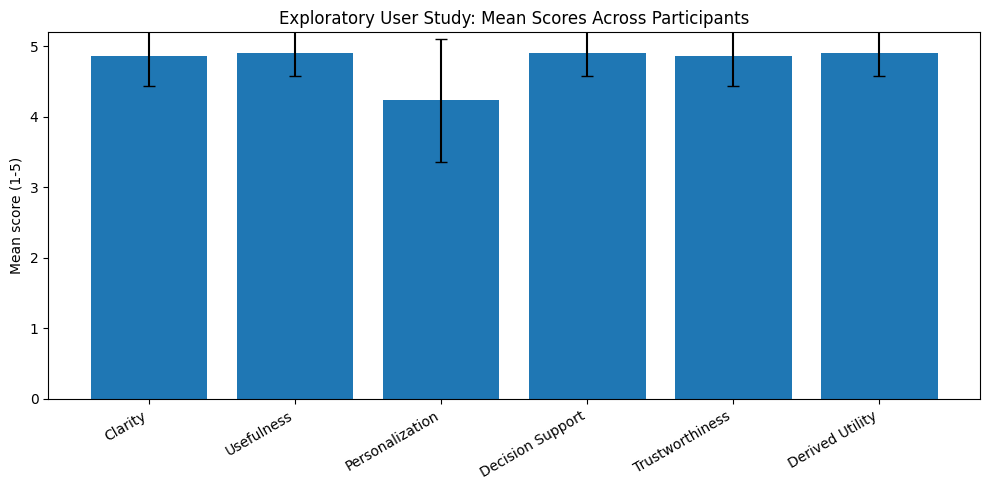

In [170]:
# ============================================================
# STEP 14C-8 - Visualization of overall user-study results
# ============================================================

import matplotlib.pyplot as plt

plot_df = (
    overall_user_study_summary
    .copy()
)

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    plot_df["Dimension"],
    plot_df["Mean"],
    yerr=plot_df["SD"],
    capsize=4
)

plt.ylim(
    0,
    5.2
)

plt.ylabel(
    "Mean score (1-5)"
)

plt.title(
    "Exploratory User Study: Mean Scores Across Participants"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()


In [171]:
# ============================================================
# STEP 14C-9 - Export user-study result tables
# ============================================================

overall_user_study_summary.to_csv(
    "user_study_overall_summary.csv",
    index=False
)

example_means.to_csv(
    "user_study_example_means.csv"
)

example_sds.to_csv(
    "user_study_example_sds.csv"
)

response_distribution_df.to_csv(
    "user_study_response_distribution.csv",
    index=False
)

user_study_df.to_csv(
    "user_study_recoded_long_format.csv",
    index=False
)

print(
    "User-study tables exported successfully."
)


User-study tables exported successfully.


In [173]:
# ============================================================
# STEP 14C-10 - Final consistency checks for thesis reporting
# ============================================================

n_participants = (
    user_study_df[
        "Participant"
    ].nunique()
)

n_examples = (
    user_study_df[
        "Example ID"
    ].nunique()
)

n_evaluations = len(
    user_study_df
)

n_item_ratings = len(
    rating_values
)

strongly_agree_count = int(
    (
        rating_values
        == 5
    ).sum()
)

print(
    "FINAL USER-STUDY CHECK"
)

print(
    "Participants:",
    n_participants
)

print(
    "Examples per participant:",
    n_examples
)

print(
    "Participant-example evaluations:",
    n_evaluations
)

print(
    "Individual Likert ratings:",
    n_item_ratings
)

print(
    "Strongly Agree ratings:",
    strongly_agree_count,
    f"({strongly_agree_count / n_item_ratings:.1%})"
)

assert n_examples == 3

assert (
    rating_values.between(
        1,
        5
    )
    .all()
)


FINAL USER-STUDY CHECK
Participants: 10
Examples per participant: 3
Participant-example evaluations: 30
Individual Likert ratings: 150
Strongly Agree ratings: 129 (86.0%)
